In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress
import glob

valid_combinations = [
    (1, 1), (1, 2), (1, 1000),  # r1i1p1f1, r1i2p1f1, r1i1000p1f1
    (2, 1),                     # r2i1p1f1
    (3, 1),                     # r3i1p1f1
    (4, 1),                     # r4i1p1f1
    (5, 1),                     # r5i1p1f1
    (6, 1),                     # r6i1p1f1
    (7, 1),                     # r7i1p1f1
    (8, 1),                     # r8i1p1f1
    (9, 1),                     # r9i1p1f1
    (10, 1)                     # r10i1p1f1
]

# Generate file paths only for valid combinations
files_historical = [
    f'/Volumes/jubjang/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_historical_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations
]
file_SSP119 = '/Volumes/jubjang/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp119_r4i1p1f1_g025.nc'
files_SSP126 = [f'/Volumes/jubjang/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp126_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
#missingi3
files_SSP245 = [f'/Volumes/jubjang/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp245_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
files_SSP370 = [f'/Volumes/jubjang/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp370_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
file_SSP434 = '/Volumes/jubjang/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp434_r1i1p1f1_g025.nc'
file_SSP460 = '/Volumes/jubjang/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp460_r1i1p1f1_g025.nc'
file_SSP534 = '/Volumes/jubjang/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp534-over_r1i1p1f1_g025.nc'
valid_combinations_ssp585 = [
    (1, 1), (1, 2),  # r1i1p1f1, r1i2p1f1
    (2, 1),          # r2i1p1f1
    (3, 1),          # r3i1p1f1
    (4, 1),          # r4i1p1f1
    (5, 1)           # r5i1p1f1
]

# Generate file paths only for the valid combinations
files_SSP585 = [
    f'/Volumes/jubjang/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp585_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations_ssp585
]

# Function to load datasets from a list of file paths
# def load_datasets(file_list):
#     datasets = []
#     for file in file_list:
#         try:
#             ds = xr.open_dataset(file)
#             datasets.append(ds)
#         except Exception as e:
#             print(f"Error loading {file}: {e}")
#     return datasets
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

# Load datasets
datasets_historical = load_datasets(files_historical)
dataset_SSP119 = xr.open_mfdataset(file_SSP119, combine='by_coords', engine='netcdf4')
datasets_SSP126 = load_datasets(files_SSP126)
datasets_SSP245 = load_datasets(files_SSP245)
datasets_SSP370 = load_datasets(files_SSP370)
dataset_SSP434 = xr.open_mfdataset(file_SSP434, combine='by_coords', engine='netcdf4')
dataset_SSP460 = xr.open_mfdataset(file_SSP460, combine='by_coords', engine='netcdf4')
dataset_SSP534 = xr.open_mfdataset(file_SSP534, combine='by_coords', engine='netcdf4')
datasets_SSP585 = load_datasets(files_SSP585)

print("Datasets successfully loaded!")

Datasets successfully loaded!


In [3]:
datasets_SSP126

[<xarray.Dataset> Size: 7MB
 Dimensions:  (time: 86, lat: 72, lon: 144)
 Coordinates:
   * time     (time) datetime64[ns] 688B 2015-07-01T06:00:00 ... 2100-07-01T06...
   * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
   * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
 Data variables:
     fwisa    (time, lat, lon) float64 7MB dask.array<chunksize=(86, 72, 144), meta=np.ndarray>
 Attributes: (12/18)
     CDI:                       Climate Data Interface version 1.9.9 (https://...
     Conventions:               CF-1.6
     experiment_id:             ssp126
     table_id:                  ann
     source_id:                 MRI-ESM2-0
     variant_label:             r1i1p1f1
     ...                        ...
     warning_method_init:       The FWI has been initialized by the common way...
     cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
     original_file_names:       /net/exo/landclim_nobackup/yqu

In [4]:
# Define CFDatetimeCoder for proper time decoding
time_coder = xr.coding.times.CFDatetimeCoder(use_cftime=True)

# Generate file paths only for valid combinations
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

files_pr_historical = [
    f'/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
file_pr_SSP119 = '/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_201501-210012.nc'
files_pr_SSP126_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_pr_SSP126_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_pr_SSP126_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_pr_SSP126_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_pr_SSP126_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_pr_SSP245_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_pr_SSP245_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_pr_SSP245_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_pr_SSP245_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_pr_SSP245_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))
files_pr_SSP370 = glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc")
file_pr_SSP434 = '/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp434_r1i1p1f1_gn_*.nc'
file_pr_SSP460 = '/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn_*.nc'
files_pr_SSP534_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc"))
files_pr_SSP585_r1i1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_pr_SSP585_r1i2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_pr_SSP585_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_pr_SSP585_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_pr_SSP585_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_pr_SSP585_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))
# Load datasets
datasets_pr_historical = load_datasets(files_pr_historical)
dataset_pr_SSP119 = xr.open_mfdataset(file_pr_SSP119, combine='by_coords', engine='netcdf4')


datasets_pr_SSP245_r1 = xr.open_mfdataset(files_pr_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245_r2 = xr.open_mfdataset(files_pr_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245_r3 = xr.open_mfdataset(files_pr_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245_r4 = xr.open_mfdataset(files_pr_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245_r5 = xr.open_mfdataset(files_pr_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245 = xr.concat([datasets_pr_SSP245_r1, datasets_pr_SSP245_r2, datasets_pr_SSP245_r3, datasets_pr_SSP245_r4, datasets_pr_SSP245_r5], dim="ensemble")

datasets_pr_SSP126_r1 = xr.open_mfdataset(files_pr_SSP126_r1, combine="nested", concat_dim="time", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP126_r2 = xr.open_mfdataset(files_pr_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP126_r3 = xr.open_mfdataset(files_pr_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP126_r4 = xr.open_mfdataset(files_pr_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP126_r5 = xr.open_mfdataset(files_pr_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_pr_SSP126 = xr.concat([datasets_pr_SSP126_r1, datasets_pr_SSP126_r2, datasets_pr_SSP126_r3, datasets_pr_SSP126_r4, datasets_pr_SSP126_r5], dim="ensemble")

# Load datasets individually and add "ensemble" as a coordinate
datasets_pr_SSP370 = [
    xr.open_dataset(file).assign_coords(ensemble=i)
    for i, file in enumerate(files_pr_SSP370)
]

# Merge all datasets along the "ensemble" dimension
datasets_pr_SSP370 = xr.concat(datasets_pr_SSP370, dim="ensemble")
dataset_pr_SSP434 = xr.open_mfdataset(file_pr_SSP434, combine='by_coords', engine='netcdf4')
dataset_pr_SSP460 = xr.open_mfdataset(file_pr_SSP460, combine='by_coords', engine='netcdf4')
datasets_pr_SSP534 = xr.open_mfdataset(files_pr_SSP534_r1, combine="nested", concat_dim="time", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r1i1 = xr.open_mfdataset(files_pr_SSP585_r1i1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r1i2 = xr.open_mfdataset(files_pr_SSP585_r1i2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r2 = xr.open_mfdataset(files_pr_SSP585_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r3 = xr.open_mfdataset(files_pr_SSP585_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r4 = xr.open_mfdataset(files_pr_SSP585_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r5 = xr.open_mfdataset(files_pr_SSP585_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585 = xr.concat([datasets_pr_SSP585_r1i1, datasets_pr_SSP585_r1i2, datasets_pr_SSP585_r2, datasets_pr_SSP585_r3, datasets_pr_SSP585_r4, datasets_pr_SSP585_r5], dim="ensemble")

/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/2574686166.py:40: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets_pr_SSP245_r2 = xr.open_mfdataset(files_pr_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/2574686166.py:41: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnin

In [5]:
datasets_pr_historical = xr.concat(datasets_pr_historical, dim="ensemble")

In [6]:
datasets_pr_all_scenarios = [
    datasets_pr_historical,
    dataset_pr_SSP119,
    datasets_pr_SSP126,
    datasets_pr_SSP245,
    datasets_pr_SSP370,
    dataset_pr_SSP434,
    dataset_pr_SSP460,
    datasets_pr_SSP534,
    datasets_pr_SSP585
]

In [7]:
# Generate file paths for tasmax
files_tasmax_historical = [
    f'/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
file_tasmax_SSP119 = "/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_201501-210012.nc"

files_tasmax_SSP126_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_tasmax_SSP245_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_tasmax_SSP245_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_tasmax_SSP245_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_tasmax_SSP245_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_tasmax_SSP245_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))

files_tasmax_SSP370 = glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc")
files_tasmax_SSP585_r1i1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_tasmax_SSP585_r1i2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_tasmax_SSP585_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_tasmax_SSP585_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_tasmax_SSP585_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_tasmax_SSP585_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

files_tasmax_SSP434 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp434_r1i1p1f1_gn*.nc"))
files_tasmax_SSP460 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn*.nc"))
files_tasmax_SSP534 = sorted(glob.glob("/Volumes/jubjang/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp534-over_r*i1p1f1_gn*.nc"))
# Load datasets
datasets_tasmax_historical = load_datasets(files_tasmax_historical)
dataset_tasmax_SSP119 = xr.open_mfdataset(file_tasmax_SSP119, combine="by_coords", engine="netcdf4")

datasets_tasmax_SSP245_r1 = xr.open_mfdataset(files_tasmax_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP245_r2 = xr.open_mfdataset(files_tasmax_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP245_r3 = xr.open_mfdataset(files_tasmax_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP245_r4 = xr.open_mfdataset(files_tasmax_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP245_r5 = xr.open_mfdataset(files_tasmax_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_tasmax_SSP245 = xr.concat([datasets_tasmax_SSP245_r1, datasets_tasmax_SSP245_r2, datasets_tasmax_SSP245_r3, datasets_tasmax_SSP245_r4, datasets_tasmax_SSP245_r5], dim="ensemble")

datasets_tasmax_SSP126_r1 = xr.open_mfdataset(files_tasmax_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP126_r2 = xr.open_mfdataset(files_tasmax_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP126_r3 = xr.open_mfdataset(files_tasmax_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP126_r4 = xr.open_mfdataset(files_tasmax_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP126_r5 = xr.open_mfdataset(files_tasmax_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_tasmax_SSP126 = xr.concat([datasets_tasmax_SSP126_r1, datasets_tasmax_SSP126_r2, datasets_tasmax_SSP126_r3, datasets_tasmax_SSP126_r4, datasets_tasmax_SSP126_r5], dim="ensemble")

# Load datasets individually and add "ensemble" as a coordinate
datasets_tasmax_SSP370 = [
    xr.open_dataset(file).assign_coords(ensemble=i)
    for i, file in enumerate(files_tasmax_SSP370)
]

# Merge all datasets along the "ensemble" dimension
datasets_tasmax_SSP370 = xr.concat(datasets_tasmax_SSP370, dim="ensemble")

datasets_tasmax_SSP585_r1i1 = xr.open_mfdataset(files_tasmax_SSP585_r1i1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r1i2 = xr.open_mfdataset(files_tasmax_SSP585_r1i2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r2 = xr.open_mfdataset(files_tasmax_SSP585_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r3 = xr.open_mfdataset(files_tasmax_SSP585_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r4 = xr.open_mfdataset(files_tasmax_SSP585_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r5 = xr.open_mfdataset(files_tasmax_SSP585_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_tasmax_SSP585 = xr.concat([datasets_tasmax_SSP585_r1i1, datasets_tasmax_SSP585_r1i2, datasets_tasmax_SSP585_r2, datasets_tasmax_SSP585_r3, datasets_tasmax_SSP585_r4, datasets_tasmax_SSP585_r5], dim="ensemble")

dataset_tasmax_SSP434 = xr.open_mfdataset(files_tasmax_SSP434, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_tasmax_SSP460 = xr.open_mfdataset(files_tasmax_SSP460, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_tasmax_SSP534 = xr.open_mfdataset(files_tasmax_SSP534, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/1729761796.py:36: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets_tasmax_SSP245_r2 = xr.open_mfdataset(files_tasmax_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/1729761796.py:37: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of thes

In [8]:
# Generate file paths only for valid combinations
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

files_sfcWind_historical = [
    f'/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
file_sfcWind_SSP119 = '/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_201501-210012.nc'
files_sfcWind_SSP126_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_sfcWind_SSP245_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_sfcWind_SSP245_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_sfcWind_SSP245_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_sfcWind_SSP245_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_sfcWind_SSP245_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))
files_sfcWind_SSP370 = glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc")
file_sfcWind_SSP434 = '/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp434_r1i1p1f1_gn_*.nc'
file_sfcWind_SSP460 = '/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn_*.nc'
files_sfcWind_SSP534_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r1i1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn_*.nc"))
files_sfcWind_SSP585_r1i2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn_201501-210012.nc"))
files_sfcWind_SSP585_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

# Load datasets
datasets_sfcWind_historical = load_datasets(files_sfcWind_historical)
dataset_sfcWind_SSP119 = xr.open_mfdataset(file_sfcWind_SSP119, combine='by_coords', engine='netcdf4')

datasets_sfcWind_SSP245_r1 = xr.open_mfdataset(files_sfcWind_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP245_r2 = xr.open_mfdataset(files_sfcWind_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP245_r3 = xr.open_mfdataset(files_sfcWind_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP245_r4 = xr.open_mfdataset(files_sfcWind_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP245_r5 = xr.open_mfdataset(files_sfcWind_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_sfcWind_SSP245 = xr.concat([datasets_sfcWind_SSP245_r1, datasets_sfcWind_SSP245_r2, datasets_sfcWind_SSP245_r3, datasets_sfcWind_SSP245_r4, datasets_sfcWind_SSP245_r5], dim="ensemble")


datasets_sfcWind_SSP126_r1 = xr.open_mfdataset(files_sfcWind_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP126_r2 = xr.open_mfdataset(files_sfcWind_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP126_r3 = xr.open_mfdataset(files_sfcWind_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP126_r4 = xr.open_mfdataset(files_sfcWind_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP126_r5 = xr.open_mfdataset(files_sfcWind_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_sfcWind_SSP126 = xr.concat([datasets_sfcWind_SSP126_r1, datasets_sfcWind_SSP126_r2, datasets_sfcWind_SSP126_r3, datasets_sfcWind_SSP126_r4, datasets_sfcWind_SSP126_r5], dim="ensemble")

# Load datasets individually and add "ensemble" as a coordinate
datasets_sfcWind_SSP370 = [
    xr.open_dataset(file).assign_coords(ensemble=i)
    for i, file in enumerate(files_sfcWind_SSP370)
]

# Merge all datasets along the "ensemble" dimension
datasets_sfcWind_SSP370 = xr.concat(datasets_sfcWind_SSP370, dim="ensemble")
dataset_sfcWind_SSP434 = xr.open_mfdataset(file_sfcWind_SSP434, combine='by_coords', engine='netcdf4')
dataset_sfcWind_SSP460 = xr.open_mfdataset(file_sfcWind_SSP460, combine='by_coords', engine='netcdf4')
datasets_sfcWind_SSP534 = xr.open_mfdataset(files_sfcWind_SSP534_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_sfcWind_SSP585_r1i1 = xr.open_mfdataset(files_sfcWind_SSP585_r1i1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r1i2 = xr.open_mfdataset(files_sfcWind_SSP585_r1i2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r2 = xr.open_mfdataset(files_sfcWind_SSP585_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r3 = xr.open_mfdataset(files_sfcWind_SSP585_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r4 = xr.open_mfdataset(files_sfcWind_SSP585_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r5 = xr.open_mfdataset(files_sfcWind_SSP585_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_sfcWind_SSP585 = xr.concat([datasets_sfcWind_SSP585_r1i1, datasets_sfcWind_SSP585_r1i2, datasets_sfcWind_SSP585_r2, datasets_sfcWind_SSP585_r3, datasets_sfcWind_SSP585_r4, datasets_sfcWind_SSP585_r5], dim="ensemble")


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/1542182004.py:37: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets_sfcWind_SSP245_r2 = xr.open_mfdataset(files_sfcWind_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/1542182004.py:38: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of th

In [9]:
datasets_sfcWind_historical = xr.concat(datasets_sfcWind_historical, dim="ensemble")

In [10]:
datasets_sfcWind_all_scenarios = [
    datasets_sfcWind_historical,
    dataset_sfcWind_SSP119,
    datasets_sfcWind_SSP126,
    datasets_sfcWind_SSP245,
    datasets_sfcWind_SSP370,
    dataset_sfcWind_SSP434,
    dataset_sfcWind_SSP460,
    datasets_sfcWind_SSP534,
    datasets_sfcWind_SSP585
]


In [11]:
# Define CFDatetimeCoder for proper time decoding
time_coder = xr.coding.times.CFDatetimeCoder(use_cftime=True)

# Generate file paths for hurs
files_hurs_historical = [
    f'/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
file_hurs_SSP119 = "/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_201501-210012.nc"

files_hurs_SSP126_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_hurs_SSP126_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_hurs_SSP126_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_hurs_SSP126_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_hurs_SSP126_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_hurs_SSP245_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_hurs_SSP245_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_hurs_SSP245_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_hurs_SSP245_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_hurs_SSP245_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))

files_hurs_SSP370 = glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc")
files_hurs_SSP585_r1i1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_hurs_SSP585_r1i2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_hurs_SSP585_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_hurs_SSP585_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_hurs_SSP585_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_hurs_SSP585_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

files_hurs_SSP434 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp434_r1i1p1f1_gn*.nc"))
files_hurs_SSP460 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn*.nc"))
files_hurs_SSP534 = sorted(glob.glob("/Volumes/jubjang/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp534-over_r*i1p1f1_gn*.nc"))

# Load datasets
datasets_hurs_historical = load_datasets(files_hurs_historical)
dataset_hurs_SSP119 = xr.open_mfdataset(file_hurs_SSP119, combine="by_coords", engine="netcdf4")

datasets_hurs_SSP245_r1 = xr.open_mfdataset(files_hurs_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP245_r2 = xr.open_mfdataset(files_hurs_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP245_r3 = xr.open_mfdataset(files_hurs_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP245_r4 = xr.open_mfdataset(files_hurs_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP245_r5 = xr.open_mfdataset(files_hurs_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_hurs_SSP245 = xr.concat([datasets_hurs_SSP245_r1, datasets_hurs_SSP245_r2, datasets_hurs_SSP245_r3, datasets_hurs_SSP245_r4, datasets_hurs_SSP245_r5], dim="ensemble")


datasets_hurs_SSP126_r1 = xr.open_mfdataset(files_hurs_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP126_r2 = xr.open_mfdataset(files_hurs_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP126_r3 = xr.open_mfdataset(files_hurs_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP126_r4 = xr.open_mfdataset(files_hurs_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP126_r5 = xr.open_mfdataset(files_hurs_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_hurs_SSP126 = xr.concat([datasets_hurs_SSP126_r1, datasets_hurs_SSP126_r2, datasets_hurs_SSP126_r3, datasets_hurs_SSP126_r4, datasets_hurs_SSP126_r5], dim="ensemble")

# Load datasets individually and add "ensemble" as a coordinate
datasets_hurs_SSP370 = [
    xr.open_dataset(file).assign_coords(ensemble=i)
    for i, file in enumerate(files_hurs_SSP370)
]

# Merge all datasets along the "ensemble" dimension
datasets_hurs_SSP370 = xr.concat(datasets_hurs_SSP370, dim="ensemble")

datasets_hurs_SSP585_r1i1 = xr.open_mfdataset(files_hurs_SSP585_r1i1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r1i2 = xr.open_mfdataset(files_hurs_SSP585_r1i2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r2 = xr.open_mfdataset(files_hurs_SSP585_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r3 = xr.open_mfdataset(files_hurs_SSP585_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r4 = xr.open_mfdataset(files_hurs_SSP585_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r5 = xr.open_mfdataset(files_hurs_SSP585_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_hurs_SSP585 = xr.concat([datasets_hurs_SSP585_r1i1, datasets_hurs_SSP585_r1i2, datasets_hurs_SSP585_r2, datasets_hurs_SSP585_r3, datasets_hurs_SSP585_r4, datasets_hurs_SSP585_r5], dim="ensemble")


dataset_hurs_SSP434 = xr.open_mfdataset(files_hurs_SSP434, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_hurs_SSP460 = xr.open_mfdataset(files_hurs_SSP460, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP534 = xr.open_mfdataset(files_hurs_SSP534, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/2510742967.py:40: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets_hurs_SSP245_r2 = xr.open_mfdataset(files_hurs_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/2510742967.py:41: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these wa

In [12]:
datasets_hurs_all_scenarios = [
    datasets_hurs_historical,
    dataset_hurs_SSP119,
    datasets_hurs_SSP126,
    datasets_hurs_SSP245,
    datasets_hurs_SSP370,
    dataset_hurs_SSP434,
    dataset_hurs_SSP460,
    datasets_hurs_SSP534,
    datasets_hurs_SSP585
]


In [13]:
datasets_hurs_historical = xr.concat(datasets_hurs_historical, dim="ensemble")

In [14]:
datasets_tasmax_historical = xr.concat(datasets_tasmax_historical, dim="ensemble")

In [15]:
# Define CFDatetimeCoder for proper time decoding
time_coder = xr.coding.times.CFDatetimeCoder(use_cftime=True)

# Generate file paths for h2o (AERmon/AERmonZ; gn/gnz)
files_h2o_historical = [
    f'/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn*.nc'
    for i, j in valid_combinations
]
files_h2o_SSP119 = sorted(glob.glob(
    "/Volumes/jubjang/Jubjang/h2o/h2o_AERmon*_MRI-ESM2-0_ssp119_r4i1p1f1_gnz_201501-210012.nc"
))

files_h2o_SSP126_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp126_r1i1p1f1_gn*.nc"))
files_h2o_SSP126_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp126_r2i1p1f1_gn*.nc"))
files_h2o_SSP126_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp126_r3i1p1f1_gn*.nc"))
files_h2o_SSP126_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp126_r4i1p1f1_gn*.nc"))
files_h2o_SSP126_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp126_r5i1p1f1_gn*.nc"))

files_h2o_SSP245_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_h2o_SSP245_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp245_r2i1p1f1_gn*.nc"))
files_h2o_SSP245_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp245_r3i1p1f1_gn*.nc"))
files_h2o_SSP245_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp245_r4i1p1f1_gn*.nc"))
files_h2o_SSP245_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp245_r5i1p1f1_gn*.nc"))

files_h2o_SSP370 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp370_r*i1p1f1_gn*.nc"))

files_h2o_SSP585_r1i1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_h2o_SSP585_r1i2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_h2o_SSP585_r2   = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_h2o_SSP585_r3   = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_h2o_SSP585_r4   = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_h2o_SSP585_r5   = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

files_h2o_SSP434 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp434_r1i1p1f1_gn*.nc"))
files_h2o_SSP460 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp460_r1i1p1f1_gn*.nc"))
files_h2o_SSP534 = sorted(glob.glob("/Volumes/jubjang/Jubjang/h2o/h2o_AERmonZ_MRI-ESM2-0_ssp534-over_r*i1p1f1_gn*.nc"))

# Load datasets
datasets_h2o_historical = load_datasets(files_h2o_historical)

# If SSP119 is a single file, this still works; if it’s split, glob above will collect them.
dataset_h2o_SSP119 = xr.open_mfdataset(files_h2o_SSP119, combine="by_coords", engine="netcdf4")

datasets_h2o_SSP245_r1 = xr.open_mfdataset(files_h2o_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP245_r2 = xr.open_mfdataset(files_h2o_SSP245_r2, combine="nested",   concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP245_r3 = xr.open_mfdataset(files_h2o_SSP245_r3, combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP245_r4 = xr.open_mfdataset(files_h2o_SSP245_r4, combine="nested",   concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP245_r5 = xr.open_mfdataset(files_h2o_SSP245_r5, combine="nested",   concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_h2o_SSP245 = xr.concat(
    [datasets_h2o_SSP245_r1, datasets_h2o_SSP245_r2, datasets_h2o_SSP245_r3, datasets_h2o_SSP245_r4, datasets_h2o_SSP245_r5],
    dim="ensemble"
)

datasets_h2o_SSP126_r1 = xr.open_mfdataset(files_h2o_SSP126_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP126_r2 = xr.open_mfdataset(files_h2o_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP126_r3 = xr.open_mfdataset(files_h2o_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP126_r4 = xr.open_mfdataset(files_h2o_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP126_r5 = xr.open_mfdataset(files_h2o_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_h2o_SSP126 = xr.concat(
    [datasets_h2o_SSP126_r1, datasets_h2o_SSP126_r2, datasets_h2o_SSP126_r3, datasets_h2o_SSP126_r4, datasets_h2o_SSP126_r5],
    dim="ensemble"
)

# Load datasets individually and add "ensemble" as a coordinate
datasets_h2o_SSP370 = [
    xr.open_dataset(file, engine="netcdf4").assign_coords(ensemble=i)
    for i, file in enumerate(files_h2o_SSP370)
]
# Merge all datasets along the "ensemble" dimension
datasets_h2o_SSP370 = xr.concat(datasets_h2o_SSP370, dim="ensemble")

datasets_h2o_SSP585_r1i1 = xr.open_mfdataset(files_h2o_SSP585_r1i1, combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP585_r1i2 = xr.open_mfdataset(files_h2o_SSP585_r1i2, combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP585_r2   = xr.open_mfdataset(files_h2o_SSP585_r2,   combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP585_r3   = xr.open_mfdataset(files_h2o_SSP585_r3,   combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP585_r4   = xr.open_mfdataset(files_h2o_SSP585_r4,   combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_h2o_SSP585_r5   = xr.open_mfdataset(files_h2o_SSP585_r5,   combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})

datasets_h2o_SSP585 = xr.concat(
    [datasets_h2o_SSP585_r1i1, datasets_h2o_SSP585_r1i2, datasets_h2o_SSP585_r2, datasets_h2o_SSP585_r3, datasets_h2o_SSP585_r4, datasets_h2o_SSP585_r5],
    dim="ensemble"
)

dataset_h2o_SSP434 = xr.open_mfdataset(files_h2o_SSP434, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_h2o_SSP460 = xr.open_mfdataset(files_h2o_SSP460, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_h2o_SSP534 = xr.open_mfdataset(files_h2o_SSP534, combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/1319655570.py:45: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets_h2o_SSP245_r2 = xr.open_mfdataset(files_h2o_SSP245_r2, combine="nested",   concat_dim="time", decode_times=time_coder, chunks={'time': 100})
/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/1319655570.py:47: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these wa

In [16]:
datasets_h2o_historical = xr.concat(datasets_h2o_historical, dim="ensemble")

In [17]:
print(datasets_h2o_SSP585)

<xarray.Dataset> Size: 155MB
Dimensions:    (ensemble: 6, time: 1032, bnds: 2, lat: 160, plev: 39)
Coordinates:
  * time       (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat        (lat) float64 1kB -89.14 -88.03 -86.91 ... 86.91 88.03 89.14
  * plev       (plev) float64 312B 1e+05 9.25e+04 8.5e+04 7e+04 ... 7.0 5.0 3.0
Dimensions without coordinates: ensemble, bnds
Data variables:
    time_bnds  (ensemble, time, bnds) object 99kB dask.array<chunksize=(1, 100, 2), meta=np.ndarray>
    lat_bnds   (ensemble, lat, bnds) float64 15kB dask.array<chunksize=(1, 160, 2), meta=np.ndarray>
    h2o        (ensemble, time, plev, lat) float32 155MB dask.array<chunksize=(1, 100, 39, 160), meta=np.ndarray>
Attributes: (12/43)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    creation_date:          2020-02-27T11:59:12Z
    ...       

In [18]:
# Define CFDatetimeCoder for proper time decoding
time_coder = xr.coding.times.CFDatetimeCoder(use_cftime=True)

# Generate file paths for ps (Amon; gn)
files_ps_historical = [
    f'/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn*.nc'
    for i, j in valid_combinations
]
files_ps_SSP119 = sorted(glob.glob(
    "/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_201501-210012.nc"
))

files_ps_SSP126_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn*.nc"))
files_ps_SSP126_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn*.nc"))
files_ps_SSP126_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn*.nc"))
files_ps_SSP126_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn*.nc"))
files_ps_SSP126_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn*.nc"))

files_ps_SSP245_r1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_ps_SSP245_r2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn*.nc"))
files_ps_SSP245_r3 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn*.nc"))
files_ps_SSP245_r4 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn*.nc"))
files_ps_SSP245_r5 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn*.nc"))

files_ps_SSP370 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn*.nc"))

files_ps_SSP585_r1i1 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_ps_SSP585_r1i2 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_ps_SSP585_r2   = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_ps_SSP585_r3   = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_ps_SSP585_r4   = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_ps_SSP585_r5   = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

files_ps_SSP434 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp434_r1i1p1f1_gn*.nc"))
files_ps_SSP460 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn*.nc"))
files_ps_SSP534 = sorted(glob.glob("/Volumes/jubjang/Jubjang/ps/ps_Amon_MRI-ESM2-0_ssp534-over_r*i1p1f1_gn*.nc"))

# Load datasets
datasets_ps_historical = load_datasets(files_ps_historical)

# If SSP119 is a single file, this still works; if it’s split, glob above will collect them.
dataset_ps_SSP119 = xr.open_mfdataset(files_ps_SSP119, combine="by_coords", engine="netcdf4")

datasets_ps_SSP245_r1 = xr.open_mfdataset(files_ps_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP245_r2 = xr.open_mfdataset(files_ps_SSP245_r2, combine="nested",   concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP245_r3 = xr.open_mfdataset(files_ps_SSP245_r3, combine="nested",   concat_dim="time",  decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP245_r4 = xr.open_mfdataset(files_ps_SSP245_r4, combine="nested",   concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP245_r5 = xr.open_mfdataset(files_ps_SSP245_r5, combine="nested",   concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_ps_SSP245 = xr.concat(
    [datasets_ps_SSP245_r1, datasets_ps_SSP245_r2, datasets_ps_SSP245_r3, datasets_ps_SSP245_r4, datasets_ps_SSP245_r5],
    dim="ensemble"
)

datasets_ps_SSP126_r1 = xr.open_mfdataset(files_ps_SSP126_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP126_r2 = xr.open_mfdataset(files_ps_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP126_r3 = xr.open_mfdataset(files_ps_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP126_r4 = xr.open_mfdataset(files_ps_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP126_r5 = xr.open_mfdataset(files_ps_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_ps_SSP126 = xr.concat(
    [datasets_ps_SSP126_r1, datasets_ps_SSP126_r2, datasets_ps_SSP126_r3, datasets_ps_SSP126_r4, datasets_ps_SSP126_r5],
    dim="ensemble"
)

# Load datasets individually and add "ensemble" as a coordinate
datasets_ps_SSP370 = [
    xr.open_dataset(file, engine="netcdf4").assign_coords(ensemble=i)
    for i, file in enumerate(files_ps_SSP370)
]
# Merge all datasets along the "ensemble" dimension
datasets_ps_SSP370 = xr.concat(datasets_ps_SSP370, dim="ensemble")

datasets_ps_SSP585_r1i1 = xr.open_mfdataset(files_ps_SSP585_r1i1, combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP585_r1i2 = xr.open_mfdataset(files_ps_SSP585_r1i2, combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP585_r2   = xr.open_mfdataset(files_ps_SSP585_r2,   combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP585_r3   = xr.open_mfdataset(files_ps_SSP585_r3,   combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP585_r4   = xr.open_mfdataset(files_ps_SSP585_r4,   combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_ps_SSP585_r5   = xr.open_mfdataset(files_ps_SSP585_r5,   combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})

datasets_ps_SSP585 = xr.concat(
    [datasets_ps_SSP585_r1i1, datasets_ps_SSP585_r1i2, datasets_ps_SSP585_r2, datasets_ps_SSP585_r3, datasets_ps_SSP585_r4, datasets_ps_SSP585_r5],
    dim="ensemble"
)

dataset_ps_SSP434 = xr.open_mfdataset(files_ps_SSP434, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_ps_SSP460 = xr.open_mfdataset(files_ps_SSP460, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_ps_SSP534 = xr.open_mfdataset(files_ps_SSP534, combine="by_coords", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/3668825864.py:45: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets_ps_SSP245_r2 = xr.open_mfdataset(files_ps_SSP245_r2, combine="nested",   concat_dim="time", decode_times=time_coder, chunks={'time': 100})
/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/3668825864.py:46: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warn

In [19]:
datasets_ps_historical = xr.concat(datasets_ps_historical, dim="ensemble")

In [20]:
datasets_ps_all_scenarios = [
    datasets_ps_historical,
    dataset_ps_SSP119,
    datasets_ps_SSP126,
    datasets_ps_SSP245,
    datasets_ps_SSP370,
    dataset_ps_SSP434,
    dataset_ps_SSP460,
    dataset_ps_SSP534,
    datasets_ps_SSP585
]


In [21]:
file_tas_areacella = "/Volumes/jubjang/Jubjang/pr/areacella_fx_MRI-ESM2-0_ssp370_r1i1p1f1_gn.nc"
areacella_tas = xr.open_mfdataset(file_tas_areacella, combine="by_coords", engine="netcdf4")
areacella_tas['areacella'].load()

<xarray.DataArray 'areacella' (lat: 160, lon: 320)> Size: 205kB
array([[2.2957566e+08, 2.2957566e+08, 2.2957566e+08, ..., 2.2957566e+08,
        2.2957566e+08, 2.2957566e+08],
       [5.3432307e+08, 5.3432307e+08, 5.3432307e+08, ..., 5.3432307e+08,
        5.3432307e+08, 5.3432307e+08],
       [8.3931718e+08, 8.3931718e+08, 8.3931718e+08, ..., 8.3931718e+08,
        8.3931718e+08, 8.3931718e+08],
       ...,
       [8.3931718e+08, 8.3931718e+08, 8.3931718e+08, ..., 8.3931718e+08,
        8.3931718e+08, 8.3931718e+08],
       [5.3432307e+08, 5.3432307e+08, 5.3432307e+08, ..., 5.3432307e+08,
        5.3432307e+08, 5.3432307e+08],
       [2.2957566e+08, 2.2957566e+08, 2.2957566e+08, ..., 2.2957566e+08,
        2.2957566e+08, 2.2957566e+08]], shape=(160, 320), dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -89.14 -88.03 -86.91 -85.79 ... 86.91 88.03 89.14
  * lon      (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 355.5 356.6 357.8 358.9
Attributes:
    standard_name:  cell_area
    long_name:      Grid-Cell Area for Atmospheric Grid Variables
    comment:        For atmospheres with more than 1 mesh (e.g., staggered gr...
    units:          m2
    original_name:  area
    cell_methods:   area: sum
    history:        2019-05-24T05:35:18Z altered by CMOR: replaced missing va...

In [22]:
datasets_tasmax_all_scenarios = [
    datasets_tasmax_historical,
    dataset_tasmax_SSP119,
    datasets_tasmax_SSP126,
    datasets_tasmax_SSP245,
    datasets_tasmax_SSP370,
    dataset_tasmax_SSP434,
    dataset_tasmax_SSP460,
    dataset_tasmax_SSP534,
    datasets_tasmax_SSP585
]


In [23]:
for i, dataset in enumerate(datasets_tasmax_all_scenarios):
    print(f"Index {i}: Type = {type(dataset)}")

Index 0: Type = <class 'xarray.core.dataset.Dataset'>
Index 1: Type = <class 'xarray.core.dataset.Dataset'>
Index 2: Type = <class 'xarray.core.dataset.Dataset'>
Index 3: Type = <class 'xarray.core.dataset.Dataset'>
Index 4: Type = <class 'xarray.core.dataset.Dataset'>
Index 5: Type = <class 'xarray.core.dataset.Dataset'>
Index 6: Type = <class 'xarray.core.dataset.Dataset'>
Index 7: Type = <class 'xarray.core.dataset.Dataset'>
Index 8: Type = <class 'xarray.core.dataset.Dataset'>


In [24]:
for i, dataset in enumerate(datasets_pr_all_scenarios):
    print(f"Index {i}: Type = {type(dataset)}")

Index 0: Type = <class 'xarray.core.dataset.Dataset'>
Index 1: Type = <class 'xarray.core.dataset.Dataset'>
Index 2: Type = <class 'xarray.core.dataset.Dataset'>
Index 3: Type = <class 'xarray.core.dataset.Dataset'>
Index 4: Type = <class 'xarray.core.dataset.Dataset'>
Index 5: Type = <class 'xarray.core.dataset.Dataset'>
Index 6: Type = <class 'xarray.core.dataset.Dataset'>
Index 7: Type = <class 'xarray.core.dataset.Dataset'>
Index 8: Type = <class 'xarray.core.dataset.Dataset'>


In [25]:
datasets_tasmax_historical

<xarray.Dataset> Size: 5GB
Dimensions:    (ensemble: 12, time: 1980, bnds: 2, lat: 160, lon: 320)
Coordinates:
  * time       (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T...
  * lat        (lat) float64 1kB -89.14 -88.03 -86.91 ... 86.91 88.03 89.14
  * lon        (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 356.6 357.8 358.9
    height     float64 8B 2.0
Dimensions without coordinates: ensemble, bnds
Data variables:
    time_bnds  (ensemble, time, bnds) datetime64[ns] 380kB dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    lat_bnds   (ensemble, lat, bnds) float64 31kB dask.array<chunksize=(1, 160, 2), meta=np.ndarray>
    lon_bnds   (ensemble, lon, bnds) float64 61kB dask.array<chunksize=(1, 320, 2), meta=np.ndarray>
    tasmax     (ensemble, time, lat, lon) float32 5GB dask.array<chunksize=(1, 1, 160, 320), meta=np.ndarray>
Attributes: (12/44)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-02-20T02:30:08Z
    ...                     ...
    title:                  MRI-ESM2-0 output prepared for CMIP6
    variable_id:            tasmax
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by MRI is licensed unde...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/eace8b52-a3be-4835-aa1d-b90b576c67d7

In [26]:
# Define Earth's radius in meters
R = 6378137

# Latitude and longitude arrays (in degrees)
lon = datasets_historical[0].coords['lon']
lat = datasets_historical[0].coords['lat']

# Convert to radians
lon_radians = np.radians(lon)
lat_radians = np.radians(lat)

# Calculate the differences in longitude and latitude
delta_lon = np.diff(lon_radians)[0]  # Assuming regular grid
delta_lat = np.diff(lat_radians).mean()  # Take the mean for approximate spacing

# Calculate area for each grid cell
area = np.zeros((len(lat), len(lon)))  # Initialize area array to match full grid

for i in range(len(lat)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    elif i == len(lat) - 1:  # Northernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    else:  # Interior latitudes
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2

    # Calculate area for this latitude band
    area[i, :] = (R**2 * delta_lon * (np.sin(phi2) - np.sin(phi1)))

# Convert to square kilometers
area_km2 = area / 1e6

# Print or save the area array
print("Area array (in km^2):", area_km2)
print("Shape of area array:", area_km2.shape)


Area array (in km^2): [[1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 ...
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]]
Shape of area array: (72, 144)


In [27]:
# Latitude and longitude arrays (in degrees)
lon_pr = datasets_pr_SSP370.coords['lon']
lat_pr = datasets_pr_SSP370.coords['lat']

# Convert to radians
lon_pr_radians = np.radians(lon_pr)
lat_pr_radians = np.radians(lat_pr)

# Calculate the differences in longitude and latitude
delta_lon_pr = np.diff(lon_pr_radians)[0]  # Assuming regular grid
delta_lat_pr = np.diff(lat_pr_radians).mean()  # Take the mean for approximate spacing

# Initialize area array to match full grid
area_pr = np.zeros((len(lat_pr), len(lon_pr)))

for i in range(len(lat_pr)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1_pr = lat_pr_radians[i] - delta_lat_pr / 2
        phi2_pr = lat_pr_radians[i] + delta_lat_pr / 2
    elif i == len(lat_pr) - 1:  # Northernmost edge
        phi1_pr = lat_pr_radians[i] - delta_lat_pr / 2
        phi2_pr = lat_pr_radians[i] + delta_lat_pr / 2
    else:  # Interior latitudes
        phi1_pr = lat_pr_radians[i] - delta_lat_pr / 2
        phi2_pr = lat_pr_radians[i] + delta_lat_pr / 2

    # Calculate area for this latitude band
    area_pr[i, :] = (R**2 * delta_lon_pr * (np.sin(phi2_pr) - np.sin(phi1_pr)))

# Convert to square kilometers
area_km2_pr = area_pr / 1e6  

# Print or save the area array
print("Area array (in km^2):", area_km2_pr)
print("Shape of area array:", area_km2_pr.shape)


Area array (in km^2): [[234.20287408 234.20287408 234.20287408 ... 234.20287408 234.20287408
  234.20287408]
 [537.50750505 537.50750505 537.50750505 ... 537.50750505 537.50750505
  537.50750505]
 [842.39948191 842.39948191 842.39948191 ... 842.39948191 842.39948191
  842.39948191]
 ...
 [842.39948191 842.39948191 842.39948191 ... 842.39948191 842.39948191
  842.39948191]
 [537.50750505 537.50750505 537.50750505 ... 537.50750505 537.50750505
  537.50750505]
 [234.20287408 234.20287408 234.20287408 ... 234.20287408 234.20287408
  234.20287408]]
Shape of area array: (160, 320)


In [28]:
area_km2_pr

array([[234.20287408, 234.20287408, 234.20287408, ..., 234.20287408,
        234.20287408, 234.20287408],
       [537.50750505, 537.50750505, 537.50750505, ..., 537.50750505,
        537.50750505, 537.50750505],
       [842.39948191, 842.39948191, 842.39948191, ..., 842.39948191,
        842.39948191, 842.39948191],
       ...,
       [842.39948191, 842.39948191, 842.39948191, ..., 842.39948191,
        842.39948191, 842.39948191],
       [537.50750505, 537.50750505, 537.50750505, ..., 537.50750505,
        537.50750505, 537.50750505],
       [234.20287408, 234.20287408, 234.20287408, ..., 234.20287408,
        234.20287408, 234.20287408]], shape=(160, 320))

In [29]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat = 72  # Number of latitude points
num_lon = 144  # Number of longitude points
lat = np.linspace(-88.75, 88.75, num_lat)  # Correct number of points
lon = np.linspace(1.25, 358.75, num_lon)  # Correct number of points

# Create the DataArray
areacella = xr.DataArray(
    area_km2,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella = xr.Dataset({"area": areacella})

# Inspect the Dataset
print(areacella)

<xarray.Dataset> Size: 85kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 83kB 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03


In [30]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat_pr = 160  # Number of latitude points
num_lon_pr = 320  # Number of longitude points
lat_pr = np.linspace(-89.14152, 89.14152, num_lat_pr)  # Correct number of points
lon_pr = np.linspace(0.0, 358.875, num_lon_pr)  # Correct number of points

# Create the DataArray
areacella_pr = xr.DataArray(
    area_km2_pr,
    dims=["lat", "lon"],
    coords={"lat": lat_pr, "lon": lon_pr},
    name="area_pr"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella_pr = xr.Dataset({"area": areacella_pr})

# Inspect the Dataset
print(areacella_pr)

<xarray.Dataset> Size: 413kB
Dimensions:  (lat: 160, lon: 320)
Coordinates:
  * lat      (lat) float64 1kB -89.14 -88.02 -86.9 -85.78 ... 86.9 88.02 89.14
  * lon      (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 355.5 356.6 357.8 358.9
Data variables:
    area     (lat, lon) float64 410kB 234.2 234.2 234.2 ... 234.2 234.2 234.2


In [31]:
# Latitude and longitude range for Thailand (adjust as needed based on data)
thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand (from 20.5°N to 5.5°N)
thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand (from 97.5°E to 105.5°E)
    
areacella_th=areacella.sel(lat=thailand_lat_range, lon=thailand_lon_range)
areacella_pr_th=areacella_pr.sel(lat=thailand_lat_range, lon=thailand_lon_range)

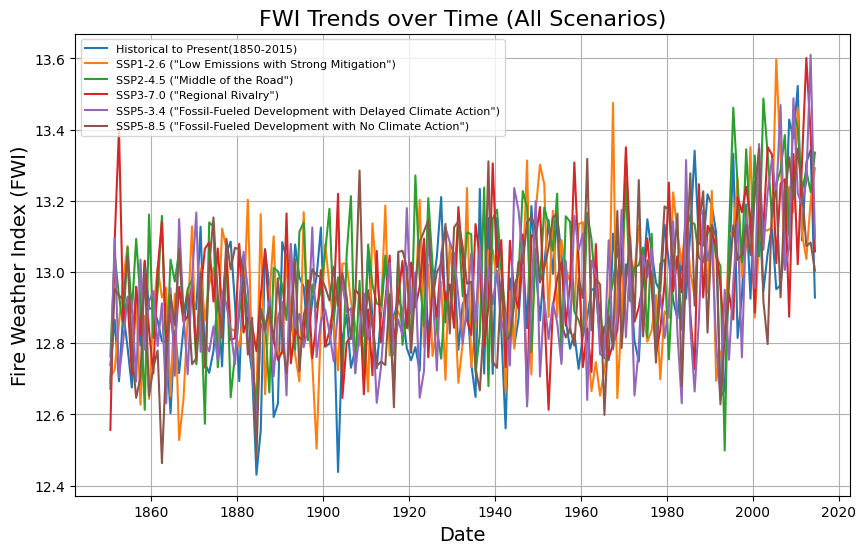

In [32]:
from datetime import datetime

def plot_fwi_trends(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(3.543, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            dataset['fwisa'].mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    # plt.title(title, fontsize=16)
    plt.legend(fontsize=11)
    plt.grid(True)
    plt.show()

# Group datasets and labels
datasets_all_scenarios = (
    datasets_historical +
    [dataset_SSP119] +
    datasets_SSP126 +
    datasets_SSP245 +
    datasets_SSP370 +
    [dataset_SSP434] +
    [dataset_SSP460]  +
    [dataset_SSP534] +
    datasets_SSP585
)

labels_all_scenarios = (
    ['Historical to Present(1850-2015)'] +
    ['SSP1-2.6 ("Low Emissions with Strong Mitigation")'] +
    ['SSP2-4.5 ("Middle of the Road")'] +
    ['SSP3-7.0 ("Regional Rivalry")'] +
    ['SSP5-3.4 ("Fossil-Fueled Development with Delayed Climate Action")'] +
    ['SSP5-8.5 ("Fossil-Fueled Development with No Climate Action")'] 
#     [f'Historical r{i}i1p1f1' for i in range(1, 11)] +
#     ['SSP119 r4i1p1f1'] +
#     [f'SSP126 r{i}i1p1f1' for i in range(1, 6)] +
#     [f'SSP245 r{i}i1p1f1' for i in range(1, 6)] +
#     [f'SSP370 r{i}i1p1f1' for i in range(1, 6)] +
#     ['SSP434 r1i1p1f1'] +
#     ['SSP460 r1i1p1f1'] +
#     ['SSP534 r1i1p1f1'] +
#     [f'SSP585 r{i}i{j}p1f1' for i, j in valid_combinations_ssp585]
)
# Plot FWI trends for all scenarios
plot_fwi_trends(datasets_all_scenarios, labels_all_scenarios, 'FWI Trends over Time (All Scenarios)')

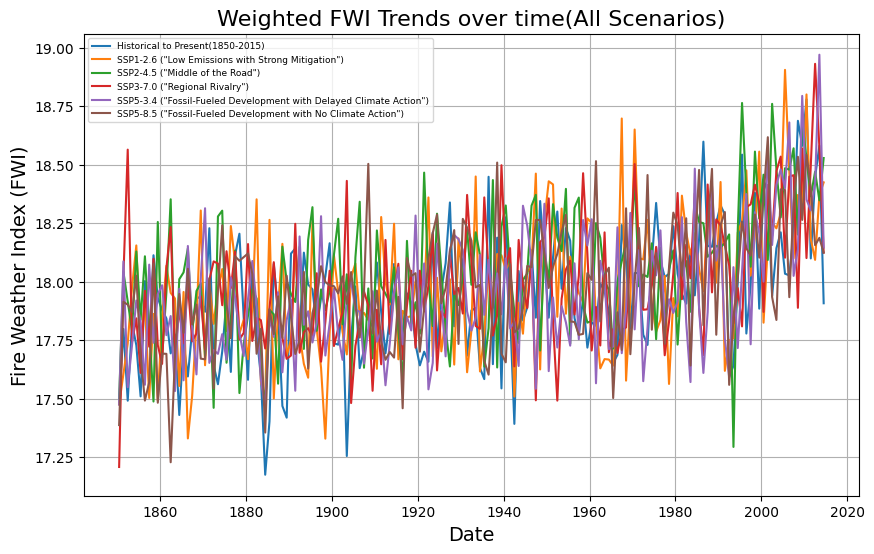

In [33]:
def plot_fwi_trends_weighted(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(3.543, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    # plt.title(title, fontsize=16)
    plt.legend(fontsize=11.5)
    plt.grid(True)
    plt.show()

plot_fwi_trends_weighted(datasets_all_scenarios, labels_all_scenarios, 'Weighted FWI Trends over time(All Scenarios)')

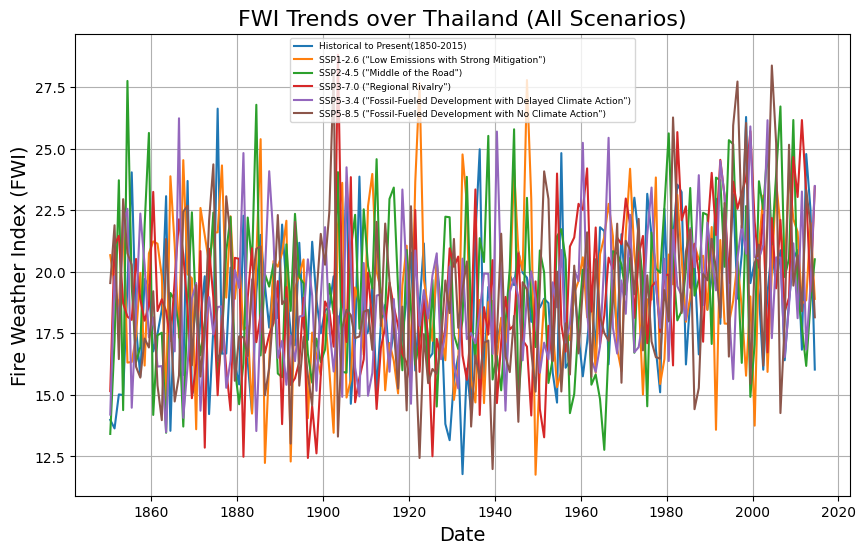

In [34]:
def plot_fwi_trends_th(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(3.543, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            (dataset['fwisa'].sel(lat=thailand_lat_range, lon=thailand_lon_range)).mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    # plt.title(title, fontsize=16)
    plt.legend(fontsize=11.5)
    plt.grid(True)
    plt.show()

plot_fwi_trends_th(datasets_all_scenarios, labels_all_scenarios, 'FWI Trends over Thailand (All Scenarios)')

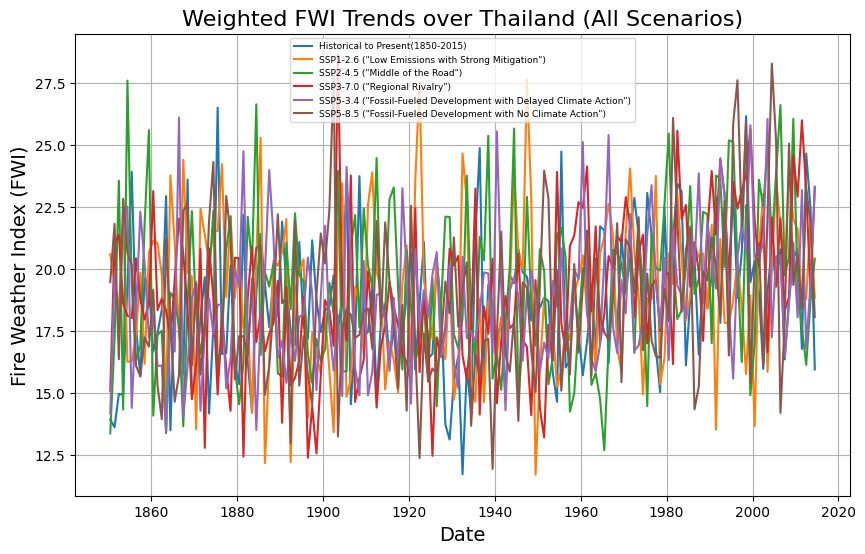

In [35]:
from datetime import datetime

def plot_fwi_trends_weighted_th(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(3.543, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            (dataset['fwisa'].sel(lat=thailand_lat_range, lon=thailand_lon_range)).weighted(areacella['area']).mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    # plt.title(title, fontsize=16)
    plt.legend(fontsize=11.5)
    plt.grid(True)
    plt.show()

plot_fwi_trends_weighted_th(datasets_all_scenarios, labels_all_scenarios, 'Weighted FWI Trends over Thailand (All Scenarios)')

In [36]:
def load_and_concatenate(file_list):
    datasets = [xr.open_dataset(file, engine='netcdf4') for file in file_list]
    concatenated = xr.concat(datasets, dim='ensemble')
    return concatenated

# Define a function to process and compute ensemble statistics
def process_ssp_data_th(file_list, lat_range, lon_range, area_weights):
    # Load and concatenate datasets
    ssp_data = load_and_concatenate(file_list)
    
    # Select the Thailand region based on latitude and longitude ranges
    ssp_data_th = ssp_data.sel(lat=lat_range, lon=lon_range)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std


In [37]:
# Group datasets and labels
datasets_all_scenarios = (
    datasets_historical +
    [dataset_SSP119] +
    datasets_SSP126 +
    datasets_SSP245 +
    datasets_SSP370 +
    [dataset_SSP434] +
    [dataset_SSP460]  +
    [dataset_SSP534] +
    datasets_SSP585
)
historical_mean_th, historical_std_th = process_ssp_data_th(files_historical, thailand_lat_range, thailand_lon_range, areacella_th)
ssp119_mean_th, ssp119_std_th = process_ssp_data_th([file_SSP119], thailand_lat_range, thailand_lon_range, areacella_th)
ssp126_mean_th, ssp126_std_th = process_ssp_data_th(files_SSP126, thailand_lat_range, thailand_lon_range, areacella_th)
ssp245_mean_th, ssp245_std_th = process_ssp_data_th(files_SSP245, thailand_lat_range, thailand_lon_range, areacella_th)
ssp370_mean_th, ssp370_std_th = process_ssp_data_th(files_SSP370, thailand_lat_range, thailand_lon_range, areacella_th)
ssp434_mean_th, ssp434_std_th = process_ssp_data_th([file_SSP434], thailand_lat_range, thailand_lon_range, areacella_th)
ssp460_mean_th, ssp460_std_th = process_ssp_data_th([file_SSP460], thailand_lat_range, thailand_lon_range, areacella_th)
ssp534_mean_th, ssp534_std_th = process_ssp_data_th([file_SSP534], thailand_lat_range, thailand_lon_range, areacella_th)
ssp585_mean_th, ssp585_std_th = process_ssp_data_th(files_SSP585, thailand_lat_range, thailand_lon_range, areacella_th)

In [38]:
datasets_thailand = [
    ds.sel(lat=thailand_lat_range, lon=thailand_lon_range) for ds in datasets_all_scenarios
]

In [39]:
def plot_fwi_trends_withstd(datasets, ensemble_means, ensemble_stds, title):
    """ 
    Plot FWI trends over time for given datasets with ensemble mean and boundaries.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        ensemble_stds (list): List of xarray DataArrays for ensemble standard deviations.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(3.543, 8))  # Increase plot size

    # Plot individual datasets in a lighter color
    for dataset in datasets[:200]:  # Limit to first 10 datasets for clarity
        # Ensure the 'time' coordinate exists in the dataset
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            # Spatially average to reduce to 1D (time dimension only)
            spatial_mean = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
            #spatial_mean = dataset['fwisa'].mean(dim=['lat', 'lon'], skipna=True)
            plt.plot(
                time, 
                spatial_mean, 
                color='lightblue', alpha=0.2  # Increase transparency
            )

    # Define distinct colors for each ensemble mean
    colors = [
        'black',  
        'navy',       
        'darkblue',  
        'green',      
        'forestgreen', 
        'red',        
        'purple',    
        'orange',    
        'gold',        
    ]

    # Define custom boundary colors for better visualization
    boundary_colors = [
        'black',     
        'deepskyblue', 
        'powderblue', 
        'lightgreen',  
        'darkseagreen',
        'salmon',     
        'plum',      
        'goldenrod', 
        'khaki',          
    ]

    # Define scenario labels for the legend
    scenario_labels = [
        'Historical', 
        'SSP119', 
        'SSP126', 
        'SSP245', 
        'SSP370',
        'SSP434', 
        'SSP460',
        'SSP534',
        'SSP585'
    ]

    
    # Plot each ensemble mean in a distinct color with a dynamic label
    for ensemble_mean, ensemble_std, label, color, boundary_color in zip(ensemble_means, ensemble_stds, scenario_labels, colors, boundary_colors):
        # Extract DataArrays (assuming fwisa is the variable of interest)
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']
        if isinstance(ensemble_std, xr.Dataset):
            ensemble_std = ensemble_std['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            # Ensemble mean should already be spatially averaged
            plt.plot(
                time, 
                ensemble_mean, 
                color=color, linewidth=2.5, label=f'Ensemble Mean ({label})'
            )
            
            # Skip uncertainty for SSP119
            if label == 'SSP119':
                continue
            
            # Skip uncertainty for SSP119
            if label == 'SSP434':
                continue
                
            # Skip uncertainty for SSP119
            if label == 'SSP460':
                continue
                
            # Skip uncertainty for SSP119
            if label == 'SSP534':
                continue
            
            # Calculate the uncertainty bounds (lower and upper)
            lower_bound = ensemble_mean - ensemble_std
            upper_bound = ensemble_mean + ensemble_std
            
            # Plot the shaded region representing uncertainty
            plt.fill_between(
                time, 
                lower_bound, 
                upper_bound, 
                color=boundary_color, alpha=0.40, label=f'Uncertainty ({label})'
            )
    
    # Plot customization
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=16)
    # plt.title(title, fontsize=18)
    plt.legend(fontsize=11, loc='upper left')  # Increase legend font size
    plt.grid(True, linestyle='--', alpha=0.6)  # Add grid with more transparency
    plt.tight_layout()
    plt.show()


In [40]:
# Example input (replace with your actual data)
ensemble_means_th_all_scenarios = [
    historical_mean_th, ssp119_mean_th, ssp126_mean_th, ssp245_mean_th,
     ssp370_mean_th, ssp434_mean_th, ssp460_mean_th, ssp534_mean_th, ssp585_mean_th
]
ensemble_stds_th_all_scenarios = [
    historical_std_th, ssp119_std_th, ssp126_std_th, ssp245_std_th,
    ssp370_std_th, ssp434_std_th, ssp460_std_th, ssp534_std_th, ssp585_std_th
]

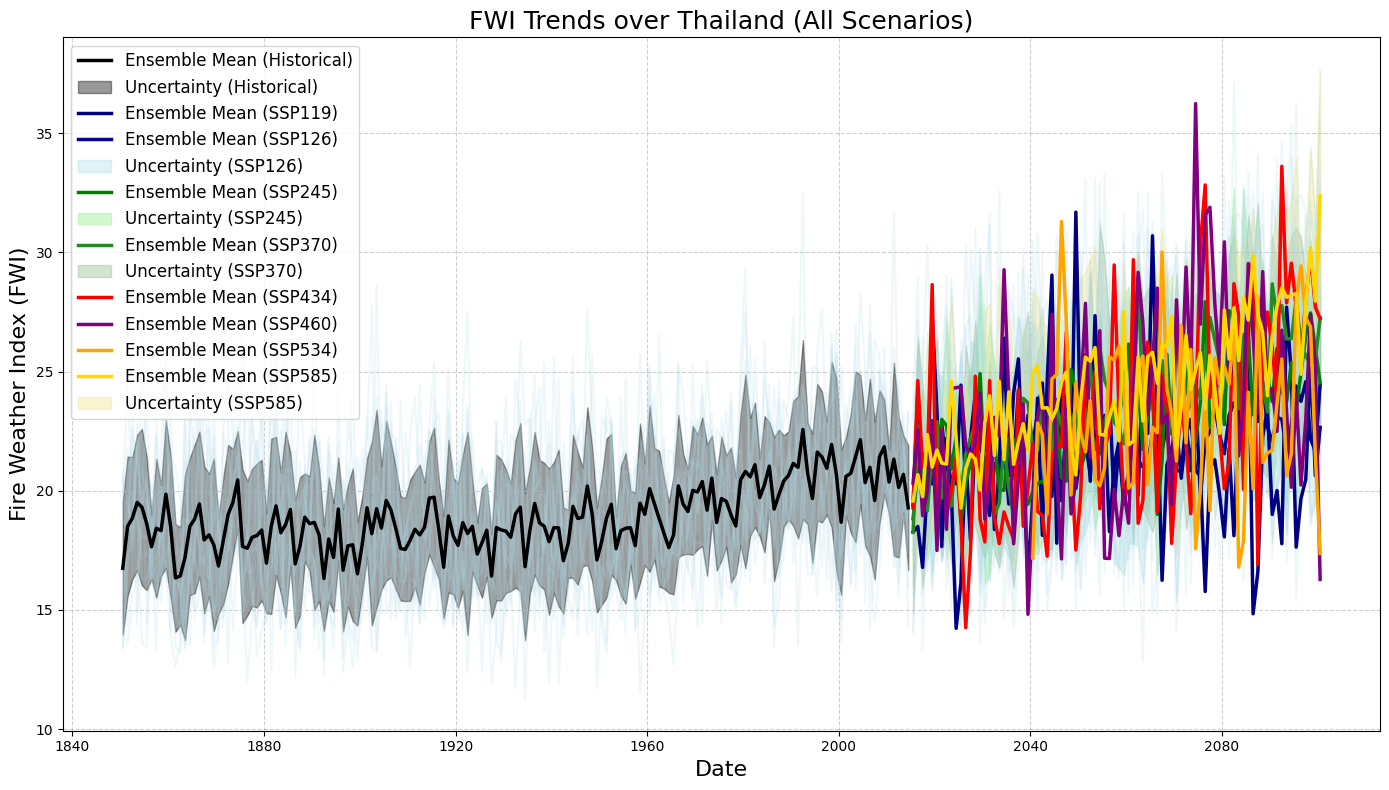

In [41]:
# Example input (replace with your actual data)
ensemble_means_th_all_scenarios = [
    historical_mean_th, ssp119_mean_th, ssp126_mean_th, ssp245_mean_th,
     ssp370_mean_th, ssp434_mean_th, ssp460_mean_th, ssp534_mean_th, ssp585_mean_th
]
ensemble_stds_th_all_scenarios = [
    historical_std_th, ssp119_std_th, ssp126_std_th, ssp245_std_th,
    ssp370_std_th, ssp434_std_th, ssp460_std_th, ssp534_std_th, ssp585_std_th
]

# Plot the FWI trends over time for all scenarios with ensemble means and boundaries
plot_fwi_trends_withstd(
    datasets_thailand, 
    ensemble_means_th_all_scenarios, 
    ensemble_stds_th_all_scenarios, 
    'FWI Trends over Thailand (All Scenarios)'
)

In [42]:
datasets_tasmax_all_scenarios

[<xarray.Dataset> Size: 5GB
 Dimensions:    (ensemble: 12, time: 1980, bnds: 2, lat: 160, lon: 320)
 Coordinates:
   * time       (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T...
   * lat        (lat) float64 1kB -89.14 -88.03 -86.91 ... 86.91 88.03 89.14
   * lon        (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 356.6 357.8 358.9
     height     float64 8B 2.0
 Dimensions without coordinates: ensemble, bnds
 Data variables:
     time_bnds  (ensemble, time, bnds) datetime64[ns] 380kB dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
     lat_bnds   (ensemble, lat, bnds) float64 31kB dask.array<chunksize=(1, 160, 2), meta=np.ndarray>
     lon_bnds   (ensemble, lon, bnds) float64 61kB dask.array<chunksize=(1, 320, 2), meta=np.ndarray>
     tasmax     (ensemble, time, lat, lon) float32 5GB dask.array<chunksize=(1, 1, 160, 320), meta=np.ndarray>
 Attributes: (12/44)
     Conventions:            CF-1.7 CMIP-6.2
     activity_id:            CMIP
     branch_method:          s

In [43]:
# Define scenario labels for the legend with detailed descriptions
labels_tasmax_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]


In [44]:
def compute_tasmax_means_YE(tasmax_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for tasmax, handling non-Gregorian calendars.

    Args:
        tasmax_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for tasmax across all scenarios (in the same order as scenario_labels).
    """
    tasmax_means = []  # ✅ Use a list

    for tasmax_dataset, label in zip(tasmax_datasets, scenario_labels):
        if isinstance(tasmax_dataset, list):
            tasmax_dataset = xr.concat(tasmax_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {tasmax_dataset['time'].min().values} to {tasmax_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            tasmax_dataset = tasmax_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # Convert Kelvin to Celsius
        tasmax_celsius = tasmax_dataset['tasmax']
        tasmax_weighted = tasmax_celsius.weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in tasmax_weighted.dims:
            tasmax_ensemble_mean = tasmax_weighted.mean(dim="ensemble")
        else:
            tasmax_ensemble_mean = tasmax_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(tasmax_ensemble_mean['time'].dtype, np.datetime64):
            tasmax_ensemble_mean = tasmax_ensemble_mean.assign_coords(
                time=tasmax_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        tasmax_ensemble_mean = tasmax_ensemble_mean.resample(time="YE").mean()

        # ✅ Append instead of using dictionary keys
        tasmax_means.append(tasmax_ensemble_mean)

    return tasmax_means  # ✅ Return a list instead of a dictionary


# ✅ Compute tasmax ensemble means
tasmax_means_all_scenarios = compute_tasmax_means_YE(
    [
        datasets_tasmax_historical,
        dataset_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        dataset_tasmax_SSP434,
        dataset_tasmax_SSP460,
        dataset_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [45]:
import numpy as np
import xarray as xr

def compute_pr_means(pr_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for precipitation (pr), handling non-Gregorian calendars.

    Args:
        pr_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for precipitation across all scenarios.
    """
    pr_means = []  

    for pr_dataset, label in zip(pr_datasets, scenario_labels):
        if isinstance(pr_dataset, list):
            pr_dataset = xr.concat(pr_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {pr_dataset['time'].min().values} to {pr_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            pr_dataset = pr_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # Extract precipitation data
        pr_values = pr_dataset['pr']

        # ✅ Convert from kg/m²/s to mm/day only if necessary
        if pr_values.max().compute() < 0.1:
            pr_values = pr_values * 86400  # Convert from kg/m²/s to mm/day

        # ✅ Compute area-weighted mean lazily
        pr_weighted = pr_values.weighted(areacella['areacella']).mean(dim=['lat', 'lon']).compute()

        # ✅ Compute ensemble mean only if "ensemble" exists
        if "ensemble" in pr_weighted.dims:
            pr_ensemble_mean = pr_weighted.mean(dim="ensemble").compute()
        else:
            pr_ensemble_mean = pr_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(pr_ensemble_mean['time'].dtype, np.datetime64):
            pr_ensemble_mean = pr_ensemble_mean.assign_coords(
                time=pr_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        pr_ensemble_mean = pr_ensemble_mean.resample(time="YE").mean()

        # ✅ Append to list instead of using dictionary keys
        pr_means.append(pr_ensemble_mean)

    return pr_means  


# ✅ Compute pr ensemble means with optimized memory usage
pr_means_all_scenarios = compute_pr_means(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [46]:
def compute_sfcWind_means(sfcWind_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for sfcWind, handling non-Gregorian calendars.

    Args:
        sfcWind_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for sfcWind across all scenarios (in the same order as scenario_labels).
    """
    sfcWind_means = []  # ✅ Use a list

    for sfcWind_dataset, label in zip(sfcWind_datasets, scenario_labels):
        if isinstance(sfcWind_dataset, list):
            sfcWind_dataset = xr.concat(sfcWind_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {sfcWind_dataset['time'].min().values} to {sfcWind_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            sfcWind_dataset = sfcWind_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # Extract sfcWind values
        sfcWind_values = sfcWind_dataset['sfcWind']
        sfcWind_weighted = sfcWind_values.weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in sfcWind_weighted.dims:
            sfcWind_ensemble_mean = sfcWind_weighted.mean(dim="ensemble")
        else:
            sfcWind_ensemble_mean = sfcWind_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(sfcWind_ensemble_mean['time'].dtype, np.datetime64):
            sfcWind_ensemble_mean = sfcWind_ensemble_mean.assign_coords(
                time=sfcWind_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        sfcWind_ensemble_mean = sfcWind_ensemble_mean.resample(time="YE").mean()

        # ✅ Append instead of using dictionary keys
        sfcWind_means.append(sfcWind_ensemble_mean)

    return sfcWind_means  # ✅ Return a list instead of a dictionary


# ✅ Compute sfcWind ensemble means
sfcWind_means_all_scenarios = compute_sfcWind_means(
    [
        datasets_sfcWind_historical,
        dataset_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        dataset_sfcWind_SSP434,
        dataset_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [47]:
def compute_hurs_means(hurs_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for hurs, handling non-Gregorian calendars.

    Args:
        hurs_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for hurs across all scenarios (in the same order as scenario_labels).
    """
    hurs_means = []  # ✅ Use a list

    for hurs_dataset, label in zip(hurs_datasets, scenario_labels):
        if isinstance(hurs_dataset, list):
            hurs_dataset = xr.concat(hurs_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {hurs_dataset['time'].min().values} to {hurs_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            hurs_dataset = hurs_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # Extract hurs values
        hurs_values = hurs_dataset['hurs']
        hurs_weighted = hurs_values.weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in hurs_weighted.dims:
            hurs_ensemble_mean = hurs_weighted.mean(dim="ensemble")
        else:
            hurs_ensemble_mean = hurs_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(hurs_ensemble_mean['time'].dtype, np.datetime64):
            hurs_ensemble_mean = hurs_ensemble_mean.assign_coords(
                time=hurs_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        hurs_ensemble_mean = hurs_ensemble_mean.resample(time="YE").mean()

        # ✅ Append instead of using dictionary keys
        hurs_means.append(hurs_ensemble_mean)

    return hurs_means  # ✅ Return a list instead of a dictionary


# ✅ Compute hurs ensemble means
hurs_means_all_scenarios = compute_hurs_means(
    [
        datasets_hurs_historical,
        dataset_hurs_SSP119,
        datasets_hurs_SSP126,  
        datasets_hurs_SSP245,
        datasets_hurs_SSP370,
        dataset_hurs_SSP434,
        dataset_hurs_SSP460,
        datasets_hurs_SSP534,
        datasets_hurs_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [48]:
# Define a function to process and compute ensemble statistics
def process_ssp_data(file_list, area_weights):
    # Load and concatenate datasets
    ssp_data = load_and_concatenate(file_list)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std

historical_mean, historical_std = process_ssp_data(files_historical, areacella_th)
ssp119_mean, ssp119_std = process_ssp_data([file_SSP119], areacella_th)
ssp126_mean, ssp126_std = process_ssp_data(files_SSP126, areacella_th)
ssp245_mean, ssp245_std = process_ssp_data(files_SSP245, areacella_th)
ssp370_mean, ssp370_std = process_ssp_data(files_SSP370, areacella_th)
ssp434_mean, ssp434_std = process_ssp_data([file_SSP434], areacella_th)
ssp460_mean, ssp460_std = process_ssp_data([file_SSP460], areacella_th)
ssp534_mean, ssp534_std = process_ssp_data([file_SSP534], areacella_th)
ssp585_mean, ssp585_std = process_ssp_data(files_SSP585, areacella_th)

In [49]:
ensemble_means_all_scenarios = [
    historical_mean, ssp119_mean, ssp126_mean, ssp245_mean,
     ssp370_mean, ssp434_mean, ssp460_mean, ssp534_mean, ssp585_mean
]
ensemble_stds_all_scenarios = [
    historical_std, ssp119_std, ssp126_std, ssp245_std,
    ssp370_std, ssp434_std, ssp460_std, ssp534_std, ssp585_std
]

In [50]:
labels_tasmax_all_scenarios = [
    'Historical',
    'SSP1-1.9',
    'SSP1-2.6',
    'SSP2-4.5',
    'SSP3-7.0',
    'SSP4-3.4',
    'SSP4-6.0',
    'SSP5-3.4',
    'SSP5-8.5'
]
# Thailand
thailand_lat_range = (5.5, 20.5)
thailand_lon_range = (97.5, 105.5)

# England (converted to 0-360 longitude)
england_lat_range = (49.5, 55.5)
england_lon_range = (353.5, 1.5)  # If using (-180, 180), keep (-6.5, 1.5)

# Amazon (converted to 0-360 longitude)
amazon_lat_range = (-10.0, 5.0)
amazon_lon_range = (285.0, 310.0)  # If using (-180, 180), keep (-75.0, -50.0)

# Philippines
philippines_lat_range = (5.0, 20.0)
philippines_lon_range = (115.0, 130.0)


In [51]:
def compute_tasmax_means_region_YE(tasmax_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for tasmax in a specified region, handling longitude wrapping if needed.

    Args:
        tasmax_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for tasmax across all scenarios.
    """
    tasmax_means = []

    for tasmax_dataset, label in zip(tasmax_datasets, scenario_labels):
        if isinstance(tasmax_dataset, list):
            tasmax_dataset = xr.concat(tasmax_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {tasmax_dataset['time'].min().values} to {tasmax_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            tasmax_dataset = tasmax_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # ✅ Select the dataset for the given latitude range
        tasmax_subset = tasmax_dataset['tasmax'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # ✅ Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # ✅ If longitude is in (-180, 180), convert to (0, 360) for consistency
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # ✅ If lon_min < lon_max (normal case), select directly
        if lon_min < lon_max:
            tasmax_subset = tasmax_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # ✅ If the region crosses 0° longitude (e.g., England, Alaska), select two parts
            tasmax_subset = xr.concat([
                tasmax_subset.sel(lon=slice(lon_min, 360)),
                tasmax_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # ✅ Compute area-weighted mean
        tasmax_weighted = tasmax_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in tasmax_weighted.dims:
            tasmax_ensemble_mean = tasmax_weighted.mean(dim="ensemble")
        else:
            tasmax_ensemble_mean = tasmax_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(tasmax_ensemble_mean['time'].dtype, np.datetime64):
            tasmax_ensemble_mean = tasmax_ensemble_mean.assign_coords(
                time=tasmax_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        tasmax_ensemble_mean = tasmax_ensemble_mean.resample(time="YE").mean()

        # ✅ Append to the list instead of using dictionary keys
        tasmax_means.append(tasmax_ensemble_mean)

    return tasmax_means


# ✅ Compute tasmax ensemble means for Thailand region
tasmax_means_all_scenarios_th_YE = compute_tasmax_means_region_YE(
    [
        datasets_tasmax_historical,
        dataset_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        dataset_tasmax_SSP434,
        dataset_tasmax_SSP460,
        dataset_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,  
    lon_range=thailand_lon_range  
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [52]:
def compute_tasmax_means_region_YS(tasmax_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for tasmax in a specified region, handling longitude wrapping if needed.

    Args:
        tasmax_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for tasmax across all scenarios.
    """
    tasmax_means = []

    for tasmax_dataset, label in zip(tasmax_datasets, scenario_labels):
        if isinstance(tasmax_dataset, list):
            tasmax_dataset = xr.concat(tasmax_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {tasmax_dataset['time'].min().values} to {tasmax_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            tasmax_dataset = tasmax_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # ✅ Select the dataset for the given latitude range
        tasmax_subset = tasmax_dataset['tasmax'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # ✅ Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # ✅ If longitude is in (-180, 180), convert to (0, 360) for consistency
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # ✅ If lon_min < lon_max (normal case), select directly
        if lon_min < lon_max:
            tasmax_subset = tasmax_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # ✅ If the region crosses 0° longitude (e.g., England, Alaska), select two parts
            tasmax_subset = xr.concat([
                tasmax_subset.sel(lon=slice(lon_min, 360)),
                tasmax_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # ✅ Compute area-weighted mean
        tasmax_weighted = tasmax_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in tasmax_weighted.dims:
            tasmax_ensemble_mean = tasmax_weighted.mean(dim="ensemble")
        else:
            tasmax_ensemble_mean = tasmax_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(tasmax_ensemble_mean['time'].dtype, np.datetime64):
            tasmax_ensemble_mean = tasmax_ensemble_mean.assign_coords(
                time=tasmax_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        tasmax_ensemble_mean = tasmax_ensemble_mean.resample(time="YS").mean()

        # ✅ Append to the list instead of using dictionary keys
        tasmax_means.append(tasmax_ensemble_mean)

    return tasmax_means


# ✅ Compute tasmax ensemble means for Thailand region
tasmax_means_all_scenarios_th_YS = compute_tasmax_means_region_YS(
    [
        datasets_tasmax_historical,
        dataset_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        dataset_tasmax_SSP434,
        dataset_tasmax_SSP460,
        dataset_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,  
    lon_range=thailand_lon_range  
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [53]:
color_blind_palette = {
        "Historical": "#000000",  # black
        "SSP119": "#E69F00",      # orange
        "SSP126": "#56B4E9",      # sky blue
        "SSP245": "#009E73",      # green
        "SSP370": "#882255",      # deep wine red
        "SSP434": "#E6D600",      # yellow
        "SSP460": "#D55E00",      # vermilion
        "SSP534": "#0072B2",      # navy blue
        "SSP585": "#CC79A7"       # reddish purple
    }
def plot_temp_vs_fwi_with_regression(datasets_fwi, datasets_temp_list, labels, title, filename):
    """
    Plot Maximum Temperature (tasmax in °C) vs Fire Weather Index (FWI) with regression analysis,
    using color-blind-friendly colors and solid regression lines.
    """
    plt.figure(figsize=(3.543, 4.1))
    # custom_lines = []

    for dataset_fwi, tasmax_mean, label in zip(datasets_fwi, datasets_temp_list, labels):
        # Detect key for color palette
        if "Historical" in label:
            key = "Historical"
        elif "SSP1-1.9" in label:
            key = "SSP119"
        elif "SSP1-2.6" in label:
            key = "SSP126"
        elif "SSP2-4.5" in label:
            key = "SSP245"
        elif "SSP3-7.0" in label:
            key = "SSP370"
        elif "SSP4-3.4" in label:
            key = "SSP434"
        elif "SSP4-6.0" in label:
            key = "SSP460"
        elif "SSP5-3.4" in label:
            key = "SSP534"
        elif "SSP5-8.5" in label:
            key = "SSP585"
        else:
            key = None

        color = color_blind_palette.get(key, "#000000")

        # Align tasmax with FWI time
        tasmax_aligned = tasmax_mean.sel(time=dataset_fwi['time'], method="nearest")
        tas_mean = (tasmax_aligned - 273.15).values  # Convert to °C
        fwi_mean = dataset_fwi['fwisa'].values

        # Remove NaNs
        valid_mask = ~np.isnan(tas_mean) & ~np.isnan(fwi_mean)
        tas_mean, fwi_mean = tas_mean[valid_mask], fwi_mean[valid_mask]

        if len(tas_mean) == 0 or len(fwi_mean) == 0:
            print(f"⚠ Skipping {label}: One or both datasets are empty after cleaning.")
            continue

        # Scatter plot
        plt.scatter(tas_mean, fwi_mean, color=color, alpha=0.6, label=label)

        # Linear regression
        slope, intercept, r_value, p_value, std_err = linregress(tas_mean, fwi_mean)
        regression_line = slope * tas_mean + intercept
        plt.plot(tas_mean, regression_line, color=color, linestyle='-', linewidth=1.0)

        # Save line for legend
        # custom_lines.append(Line2D([0], [0], color=color, lw=2, linestyle='-', label=label))

        print(f"{label}: FWI = {slope:.2f} * Temp + {intercept:.2f}  |  r = {r_value:.3f}")

    # Customize plot
    plt.xlabel('Yearly Mean Maximum Temperature (°C)', fontsize=9)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=9)
    # plt.title(title, fontsize=11, y=1.01)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Legend below
    plt.legend(
        # handles=custom_lines,
        fontsize=9,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=4,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=1000)
    plt.show()



# ✅ Labels for each scenario
labels_tasmax_all_scenarios = [
    'Historical',
    'SSP1-1.9',
    'SSP1-2.6',
    'SSP2-4.5',
    'SSP3-7.0',
    'SSP4-3.4',
    'SSP4-6.0',
    'SSP5-3.4',
    'SSP5-8.5'
]



Historical: FWI = 3.37 * Temp + -77.66  |  r = 0.521
SSP1-1.9: FWI = 0.63 * Temp + 2.71  |  r = 0.088
SSP1-2.6: FWI = 0.83 * Temp + -2.93  |  r = 0.201
SSP2-4.5: FWI = 2.57 * Temp + -55.23  |  r = 0.715
SSP3-7.0: FWI = 2.50 * Temp + -52.59  |  r = 0.806
SSP4-3.4: FWI = 2.43 * Temp + -50.54  |  r = 0.447
SSP4-6.0: FWI = 1.83 * Temp + -32.36  |  r = 0.408
SSP5-3.4: FWI = 2.09 * Temp + -40.95  |  r = 0.273
SSP5-8.5: FWI = 1.89 * Temp + -34.21  |  r = 0.784


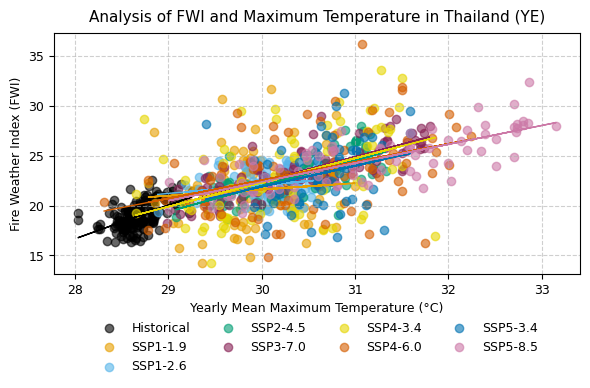

In [54]:
# ✅ Call the function using precomputed means
plot_temp_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    tasmax_means_all_scenarios_th_YE,  # Precomputed Tasmax means
    labels_tasmax_all_scenarios, 
    'Analysis of FWI and Maximum Temperature in Thailand (YE)',
    'FWI_vs_tasmax_Thailand_YE.png'
)


Historical: FWI = 5.02 * Temp + -125.05  |  r = 0.747
SSP1-1.9: FWI = 4.82 * Temp + -122.76  |  r = 0.657
SSP1-2.6: FWI = 2.53 * Temp + -53.84  |  r = 0.596
SSP2-4.5: FWI = 2.96 * Temp + -66.94  |  r = 0.825
SSP3-7.0: FWI = 2.72 * Temp + -59.59  |  r = 0.902
SSP4-3.4: FWI = 4.13 * Temp + -101.93  |  r = 0.762
SSP4-6.0: FWI = 3.42 * Temp + -80.91  |  r = 0.719
SSP5-3.4: FWI = 5.28 * Temp + -138.65  |  r = 0.717
SSP5-8.5: FWI = 2.05 * Temp + -39.46  |  r = 0.867


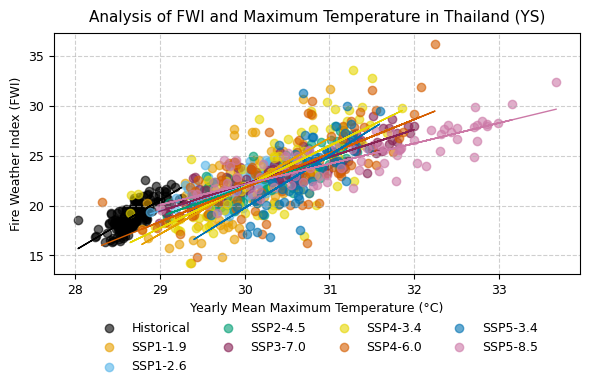

In [135]:
# ✅ Call the function using precomputed means
plot_temp_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    tasmax_means_all_scenarios_th_YS,  # Precomputed Tasmax means
    labels_tasmax_all_scenarios, 
    'Analysis of FWI and Maximum Temperature in Thailand (YS)',
    'FWI_vs_tasmax_Thailand_YS.png'
)


All scenarios: FWI = 2.2221 * Temp + -44.5897  |  Correlation (r) = 0.6653


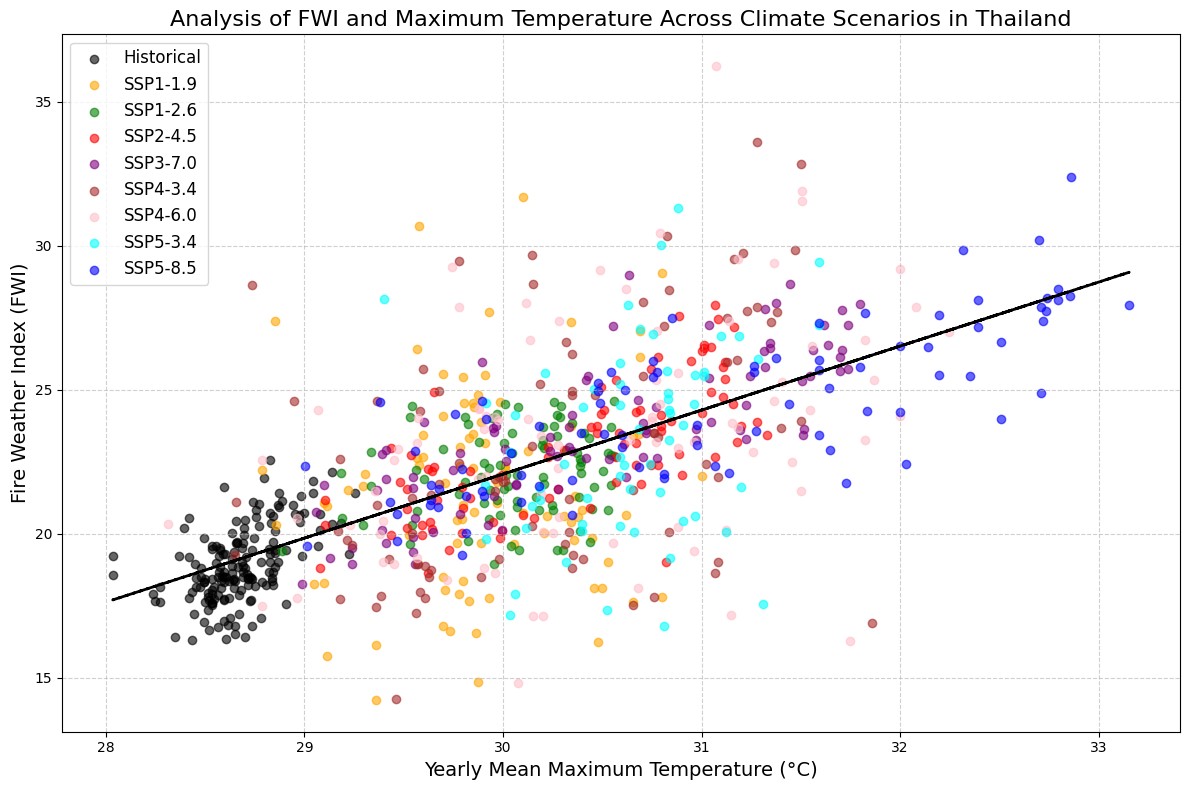

In [137]:
def plot_temp_vs_fwi_with_oneregression(datasets_fwi, datasets_temp_list, labels, title, filename):
    """
    Plot Maximum Temperature (tasmax in °C) vs Fire Weather Index (FWI) with regression analysis.
    
    Args:
        datasets_fwi (list): List of xarray datasets containing 'fwisa' (yearly).
        datasets_temp_list (list): List of precomputed tasmax means per scenario.
        labels (list): Corresponding labels for scenarios.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(3.543, 8))
    
    colors = ['black', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'cyan', 'blue']

    # Initialize empty lists for combined temperature and FWI data
    combined_tas = []
    combined_fwi = []

    for dataset_fwi, tasmax_mean, label, color in zip(datasets_fwi, datasets_temp_list, labels, colors):
    
        # Align tasmax with FWI time
        tasmax_aligned = tasmax_mean.sel(time=dataset_fwi['time'], method="nearest")

        # Compute mean FWI and temperature (convert from Kelvin to Celsius)
        fwi_mean = dataset_fwi['fwisa'].values
        tas_mean = (tasmax_aligned - 273.15).values  # Convert Kelvin to Celsius

        # ✅ Remove NaN values before regression
        valid_mask = ~np.isnan(tas_mean) & ~np.isnan(fwi_mean)
        tas_mean, fwi_mean = tas_mean[valid_mask], fwi_mean[valid_mask]

        # ✅ Ensure both arrays have valid data before regression
        if len(tas_mean) == 0 or len(fwi_mean) == 0:
            print(f"⚠ Skipping {label}: One or both datasets are empty after cleaning.")
            continue  # Skip empty datasets

        # Append data to combined lists
        combined_tas.extend(tas_mean)
        combined_fwi.extend(fwi_mean)

        # Scatter plot for each scenario
        plt.scatter(tas_mean, fwi_mean, label=label, color=color, alpha=0.6)

    # Compute linear regression (y = mx + c) for combined data
    if len(combined_tas) > 0 and len(combined_fwi) > 0:
        slope, intercept, r_value, p_value, std_err = linregress(combined_tas, combined_fwi)
        regression_line = slope * np.array(combined_tas) + intercept

        # Plot a single regression line for all data points
        plt.plot(combined_tas, regression_line, color='black', linestyle='--', linewidth=2)

        # Print the regression equation and correlation for all scenarios
        print(f"All scenarios: FWI = {slope:.4f} * Temp + {intercept:.4f}  |  Correlation (r) = {r_value:.4f}")
    else:
        print("No valid data to compute regression.")

    # Customize the plot
    plt.xlabel('Yearly Mean Maximum Temperature (°C)', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    # plt.title(title, fontsize=16)
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(filename, dpi=1000)
    plt.show()

plot_temp_vs_fwi_with_oneregression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    tasmax_means_all_scenarios_th_YE,  # Precomputed Tasmax means
    labels_tasmax_all_scenarios, 
    'Analysis of FWI and Maximum Temperature Across Climate Scenarios in Thailand',
    '1Avg hum Analysis of FWI and Maximum Temperature Across Climate Scenarios in Thailand.png'
)

All scenarios: FWI = 2.6642 * Temp + -57.9083  |  Correlation (r) = 0.8013


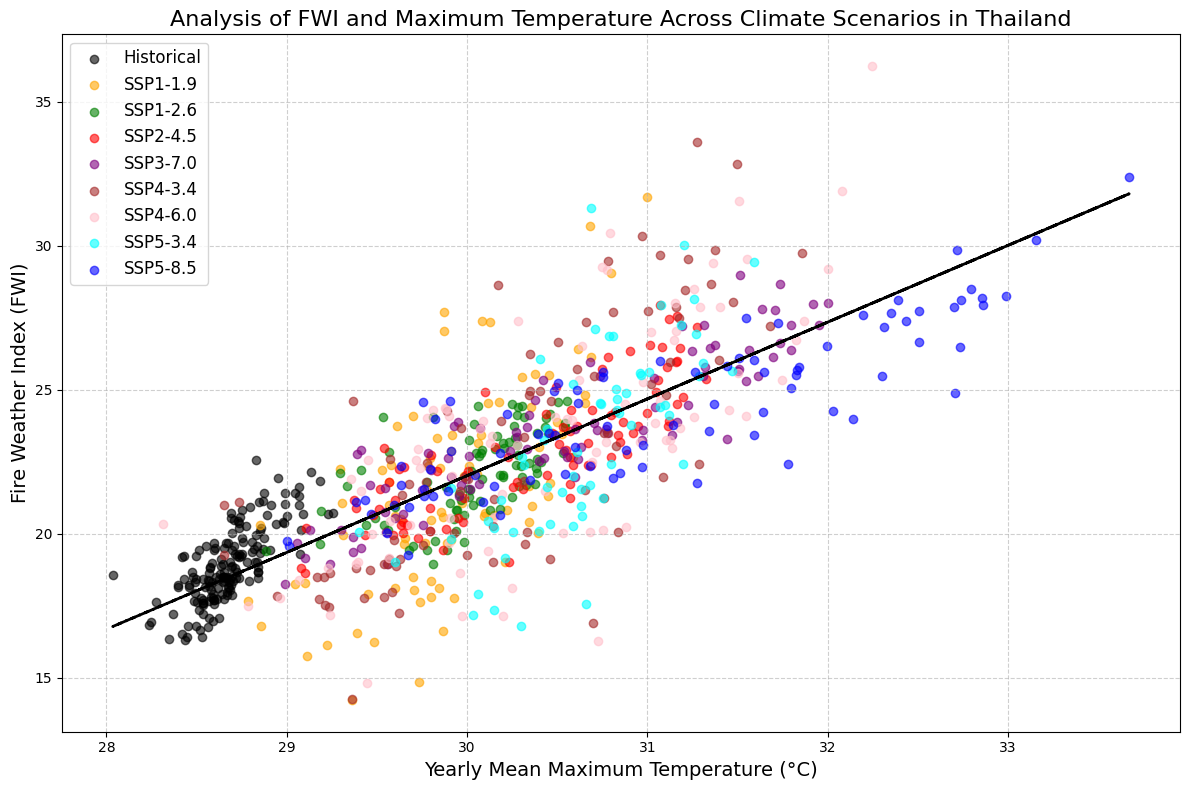

In [138]:
plot_temp_vs_fwi_with_oneregression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    tasmax_means_all_scenarios_th_YS,  # Precomputed Tasmax means
    labels_tasmax_all_scenarios, 
    'Analysis of FWI and Maximum Temperature Across Climate Scenarios in Thailand',
    '1Avg hum Analysis of FWI and Maximum Temperature Across Climate Scenarios in Thailand.png'
)

In [139]:
# # ── Thailand — tasmax YS ──────────────────────────────────────────────────────
# plot_temp_vs_fwi_with_regression(
#     ensemble_means_th_all_scenarios,
#     tasmax_means_all_scenarios_th_YS,
#     labels_tasmax_all_scenarios,
#     'Analysis of FWI and Maximum Temperature in Thailand (YS)',
#     'FWI_vs_tasmax_Thailand_YS.png'
# )

In [140]:
def compute_pr_means_region_YE(pr_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for pr in a specified region (resample=YE).
    """
    pr_means = []

    for pr_dataset, label in zip(pr_datasets, scenario_labels):
        if isinstance(pr_dataset, list):
            pr_dataset = xr.concat(pr_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {pr_dataset['time'].min().values} to {pr_dataset['time'].max().values}")

        if any(sub in label for sub in ["126", "534", "585"]):
            print(f"✂ Cutting {label} at 2100")
            pr_dataset = pr_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        pr_subset = pr_dataset['pr'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        lon_min, lon_max = lon_range
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        if lon_min < lon_max:
            pr_subset = pr_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            pr_subset = xr.concat([
                pr_subset.sel(lon=slice(lon_min, 360)),
                pr_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        pr_weighted = pr_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in pr_weighted.dims:
            pr_ensemble_mean = pr_weighted.mean(dim="ensemble")
        else:
            pr_ensemble_mean = pr_weighted

        if not np.issubdtype(pr_ensemble_mean['time'].dtype, np.datetime64):
            pr_ensemble_mean = pr_ensemble_mean.assign_coords(
                time=pr_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        pr_ensemble_mean = pr_ensemble_mean.dropna(dim="time", how="all")
        pr_ensemble_mean = pr_ensemble_mean.resample(time="YE").mean()
        pr_means.append(pr_ensemble_mean)

    return pr_means


def compute_pr_means_region_YS(pr_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for pr in a specified region (resample=YS).
    """
    pr_means = []

    for pr_dataset, label in zip(pr_datasets, scenario_labels):
        if isinstance(pr_dataset, list):
            pr_dataset = xr.concat(pr_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {pr_dataset['time'].min().values} to {pr_dataset['time'].max().values}")

        if any(sub in label for sub in ["126", "534", "585"]):
            print(f"✂ Cutting {label} at 2100")
            pr_dataset = pr_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        pr_subset = pr_dataset['pr'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        lon_min, lon_max = lon_range
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        if lon_min < lon_max:
            pr_subset = pr_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            pr_subset = xr.concat([
                pr_subset.sel(lon=slice(lon_min, 360)),
                pr_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        pr_weighted = pr_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in pr_weighted.dims:
            pr_ensemble_mean = pr_weighted.mean(dim="ensemble")
        else:
            pr_ensemble_mean = pr_weighted

        if not np.issubdtype(pr_ensemble_mean['time'].dtype, np.datetime64):
            pr_ensemble_mean = pr_ensemble_mean.assign_coords(
                time=pr_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        pr_ensemble_mean = pr_ensemble_mean.dropna(dim="time", how="all")
        pr_ensemble_mean = pr_ensemble_mean.resample(time="YS").mean()
        pr_means.append(pr_ensemble_mean)

    return pr_means


# ── Thailand — YE ──────────────────────────────────────────────────────────────
pr_means_all_scenarios_th_YE = compute_pr_means_region_YE(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)

# ── Thailand — YS ──────────────────────────────────────────────────────────────
pr_means_all_scenarios_th_YS = compute_pr_means_region_YS(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)

Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100
Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:0

In [148]:
datasets_pr_all_scenarios = [
    datasets_pr_historical,
    dataset_pr_SSP119,
    datasets_pr_SSP126,
    datasets_pr_SSP245,
    datasets_pr_SSP370,
    dataset_pr_SSP434,
    dataset_pr_SSP460,
    datasets_pr_SSP534,
    datasets_pr_SSP585
]

In [150]:
labels_pr_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

In [152]:
# (removed — non-Thailand region)

Historical: FWI = -4.43 * Precipitation + 43.29  |  r = -0.767
SSP1-1.9: FWI = -2.75 * Precipitation + 36.61  |  r = -0.317
SSP1-2.6: FWI = -0.20 * Precipitation + 23.17  |  r = -0.028
SSP2-4.5: FWI = -1.63 * Precipitation + 31.65  |  r = -0.121
SSP3-7.0: FWI = -7.74 * Precipitation + 62.88  |  r = -0.543
SSP4-3.4: FWI = -5.65 * Precipitation + 52.22  |  r = -0.495
SSP4-6.0: FWI = -3.40 * Precipitation + 40.84  |  r = -0.356
SSP5-3.4: FWI = -3.23 * Precipitation + 40.95  |  r = -0.420
SSP5-8.5: FWI = 0.82 * Precipitation + 19.95  |  r = 0.066


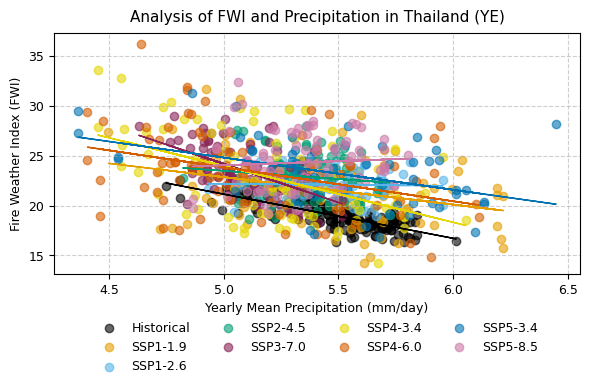

In [154]:
#  Call the function using precomputed means
plot_pr_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    pr_means_all_scenarios_th_YE,  # Precomputed Precipitation means
    labels_tasmax_all_scenarios, 
    'Analysis of FWI and Precipitation in Thailand (YE)',
    'FWI_vs_pr_Thailand_YE.png'
)


Historical: FWI = -4.16 * Precipitation + 41.79  |  r = -0.755
SSP1-1.9: FWI = -3.08 * Precipitation + 38.40  |  r = -0.356
SSP1-2.6: FWI = -0.44 * Precipitation + 24.50  |  r = -0.060
SSP2-4.5: FWI = -0.86 * Precipitation + 27.52  |  r = -0.070
SSP3-7.0: FWI = -6.56 * Precipitation + 56.67  |  r = -0.459
SSP4-3.4: FWI = -6.68 * Precipitation + 57.51  |  r = -0.616
SSP4-6.0: FWI = -2.60 * Precipitation + 36.94  |  r = -0.280
SSP5-3.4: FWI = -4.58 * Precipitation + 48.53  |  r = -0.550
SSP5-8.5: FWI = 0.72 * Precipitation + 20.50  |  r = 0.055


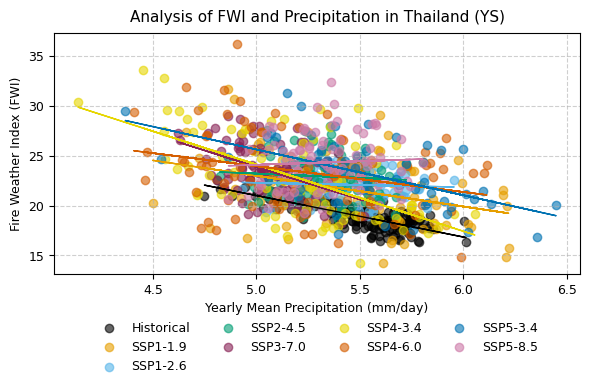

In [155]:
#  Call the function using precomputed means
plot_pr_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    pr_means_all_scenarios_th_YS,  # Precomputed Precipitation means
    labels_tasmax_all_scenarios, 
    'Analysis of FWI and Precipitation in Thailand (YS)',
    'FWI_vs_pr_Thailand_YS.png'
)


In [160]:
def compute_pr_means_region_YE(pr_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for precipitation (pr) in a specified region, handling longitude wrapping if needed.

    Args:
        pr_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for pr across all scenarios.
    """
    pr_means = []

    for pr_dataset, label in zip(pr_datasets, scenario_labels):
        if isinstance(pr_dataset, list):
            pr_dataset = xr.concat(pr_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {pr_dataset['time'].min().values} to {pr_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            pr_dataset = pr_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # ✅ Select the dataset for the given latitude range
        pr_subset = pr_dataset['pr'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # ✅ Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # ✅ Convert longitude to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # ✅ If lon_min < lon_max (normal case), select directly
        if lon_min < lon_max:
            pr_subset = pr_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # ✅ If the region crosses 0° longitude (e.g., England, Alaska), select two parts
            pr_subset = xr.concat([
                pr_subset.sel(lon=slice(lon_min, 360)),
                pr_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # ✅ Compute area-weighted mean
        pr_weighted = pr_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in pr_weighted.dims:
            pr_ensemble_mean = pr_weighted.mean(dim="ensemble")
        else:
            pr_ensemble_mean = pr_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(pr_ensemble_mean['time'].dtype, np.datetime64):
            pr_ensemble_mean = pr_ensemble_mean.assign_coords(
                time=pr_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        pr_ensemble_mean = pr_ensemble_mean.resample(time="YE").mean()

        # ✅ Append to the list instead of using dictionary keys
        pr_means.append(pr_ensemble_mean)

    return pr_means


# ✅ Compute pr ensemble means for Thailand region
pr_means_all_scenarios_th_YE = compute_pr_means_region_YE(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,  # ✅ Correct: Thailand Latitude Range
    lon_range=thailand_lon_range  # ✅ Fixed: Correct Longitude Range
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [162]:
def compute_pr_means_region_YS(pr_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for precipitation (pr) in a specified region, handling longitude wrapping if needed.

    Args:
        pr_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for pr across all scenarios.
    """
    pr_means = []

    for pr_dataset, label in zip(pr_datasets, scenario_labels):
        if isinstance(pr_dataset, list):
            pr_dataset = xr.concat(pr_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {pr_dataset['time'].min().values} to {pr_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            pr_dataset = pr_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # ✅ Select the dataset for the given latitude range
        pr_subset = pr_dataset['pr'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # ✅ Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # ✅ Convert longitude to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # ✅ If lon_min < lon_max (normal case), select directly
        if lon_min < lon_max:
            pr_subset = pr_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # ✅ If the region crosses 0° longitude (e.g., England, Alaska), select two parts
            pr_subset = xr.concat([
                pr_subset.sel(lon=slice(lon_min, 360)),
                pr_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # ✅ Compute area-weighted mean
        pr_weighted = pr_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in pr_weighted.dims:
            pr_ensemble_mean = pr_weighted.mean(dim="ensemble")
        else:
            pr_ensemble_mean = pr_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(pr_ensemble_mean['time'].dtype, np.datetime64):
            pr_ensemble_mean = pr_ensemble_mean.assign_coords(
                time=pr_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        pr_ensemble_mean = pr_ensemble_mean.resample(time="YS").mean()

        # ✅ Append to the list instead of using dictionary keys
        pr_means.append(pr_ensemble_mean)

    return pr_means


# ✅ Compute pr ensemble means for Thailand region
pr_means_all_scenarios_th_YS = compute_pr_means_region_YS(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,  # ✅ Correct: Thailand Latitude Range
    lon_range=thailand_lon_range  # ✅ Fixed: Correct Longitude Range
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


All scenarios: FWI = -4.2864 * Precipitation + 45.0778  |  Correlation (r) = -0.4263


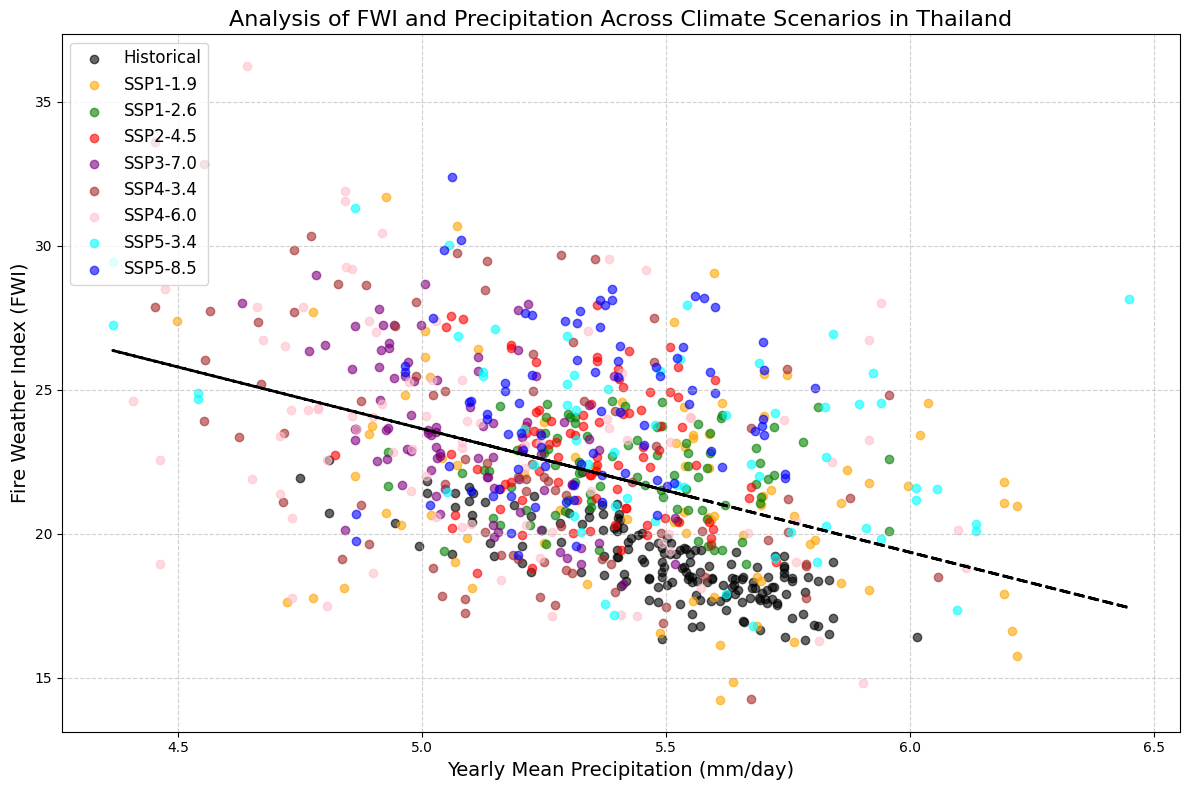

In [164]:
def plot_pr_vs_fwi_with_oneregression(datasets_fwi, datasets_pr_list, labels, title, filename):
    """
    Plot Precipitation (pr in mm/day) vs Fire Weather Index (FWI) with regression analysis.
    
    Args:
        datasets_fwi (list): List of xarray datasets containing 'fwisa' (yearly).
        datasets_pr_list (list): List of precomputed precipitation means per scenario.
        labels (list): Corresponding labels for scenarios.
        title (str): Title for the plot.
        filename (str): Filename to save the plot.
    """
    plt.figure(figsize=(3.543, 8))
    
    colors = ['black', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'cyan', 'blue']

    # Initialize empty lists for combined precipitation and FWI data
    combined_pr = []
    combined_fwi = []

    for dataset_fwi, pr_mean, label, color in zip(datasets_fwi, datasets_pr_list, labels, colors):
    
        # Align precipitation with FWI time
        pr_aligned = pr_mean.sel(time=dataset_fwi['time'], method="nearest")

        # Compute mean FWI
        fwi_mean = dataset_fwi['fwisa'].values
        pr_values = pr_aligned.values  # Precipitation values in kg/m²/s

        # Convert Precipitation to mm/day if needed
        if np.max(pr_values) < 0.1:  # Assumption: dataset might be in kg/m²/s
            pr_values *= 86400  # Convert from kg/m²/s to mm/day

        # Remove NaN values before regression
        valid_mask = ~np.isnan(pr_values) & ~np.isnan(fwi_mean)
        pr_values, fwi_mean = pr_values[valid_mask], fwi_mean[valid_mask]

        # Ensure both arrays have valid data before regression
        if len(pr_values) == 0 or len(fwi_mean) == 0:
            print(f"⚠ Skipping {label}: One or both datasets are empty after cleaning.")
            continue  # Skip empty datasets

        # Append data to combined lists
        combined_pr.extend(pr_values)
        combined_fwi.extend(fwi_mean)

        # Scatter plot for each scenario
        plt.scatter(pr_values, fwi_mean, label=label, color=color, alpha=0.6)

    # Compute linear regression (y = mx + c) for the combined data
    if len(combined_pr) > 0 and len(combined_fwi) > 0:
        slope, intercept, r_value, p_value, std_err = linregress(combined_pr, combined_fwi)
        regression_line = slope * np.array(combined_pr) + intercept

        # Plot a single regression line for all data points
        plt.plot(combined_pr, regression_line, color='black', linestyle='--', linewidth=2)

        # Print the regression equation and correlation for all scenarios
        print(f"All scenarios: FWI = {slope:.4f} * Precipitation + {intercept:.4f}  |  Correlation (r) = {r_value:.4f}")
    else:
        print("No valid data to compute regression.")

    # Customize the plot
    plt.xlabel('Yearly Mean Precipitation (mm/day)', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    # plt.title(title, fontsize=16)
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(filename, dpi=1000)
    plt.savefig('FWI_vs_Precip_Regression.png', dpi=1000)
    plt.show()

# Call the function using precomputed means
plot_pr_vs_fwi_with_oneregression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    pr_means_all_scenarios_th_YE,  # Precomputed Precipitation means
    labels_tasmax_all_scenarios, 
    'Analysis of FWI and Precipitation Across Climate Scenarios in Thailand',
    '1Avg hum Analysis of FWI and Precipitation Across Climate Scenarios in Thailand.png'
)


In [167]:
def compute_sfcWind_means_region_YE(sfcWind_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for sfcWind in a specified region (resample=YE).
    """
    sfcWind_means = []

    for sfcWind_dataset, label in zip(sfcWind_datasets, scenario_labels):
        if isinstance(sfcWind_dataset, list):
            sfcWind_dataset = xr.concat(sfcWind_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {sfcWind_dataset['time'].min().values} to {sfcWind_dataset['time'].max().values}")

        if any(sub in label for sub in ["126", "534", "585"]):
            print(f"✂ Cutting {label} at 2100")
            sfcWind_dataset = sfcWind_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        sfcWind_subset = sfcWind_dataset['sfcWind'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        lon_min, lon_max = lon_range
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        if lon_min < lon_max:
            sfcWind_subset = sfcWind_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            sfcWind_subset = xr.concat([
                sfcWind_subset.sel(lon=slice(lon_min, 360)),
                sfcWind_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        sfcWind_weighted = sfcWind_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in sfcWind_weighted.dims:
            sfcWind_ensemble_mean = sfcWind_weighted.mean(dim="ensemble")
        else:
            sfcWind_ensemble_mean = sfcWind_weighted

        if not np.issubdtype(sfcWind_ensemble_mean['time'].dtype, np.datetime64):
            sfcWind_ensemble_mean = sfcWind_ensemble_mean.assign_coords(
                time=sfcWind_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        sfcWind_ensemble_mean = sfcWind_ensemble_mean.dropna(dim="time", how="all")
        sfcWind_ensemble_mean = sfcWind_ensemble_mean.resample(time="YE").mean()
        sfcWind_means.append(sfcWind_ensemble_mean)

    return sfcWind_means


def compute_sfcWind_means_region_YS(sfcWind_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for sfcWind in a specified region (resample=YS).
    """
    sfcWind_means = []

    for sfcWind_dataset, label in zip(sfcWind_datasets, scenario_labels):
        if isinstance(sfcWind_dataset, list):
            sfcWind_dataset = xr.concat(sfcWind_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {sfcWind_dataset['time'].min().values} to {sfcWind_dataset['time'].max().values}")

        if any(sub in label for sub in ["126", "534", "585"]):
            print(f"✂ Cutting {label} at 2100")
            sfcWind_dataset = sfcWind_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        sfcWind_subset = sfcWind_dataset['sfcWind'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        lon_min, lon_max = lon_range
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        if lon_min < lon_max:
            sfcWind_subset = sfcWind_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            sfcWind_subset = xr.concat([
                sfcWind_subset.sel(lon=slice(lon_min, 360)),
                sfcWind_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        sfcWind_weighted = sfcWind_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in sfcWind_weighted.dims:
            sfcWind_ensemble_mean = sfcWind_weighted.mean(dim="ensemble")
        else:
            sfcWind_ensemble_mean = sfcWind_weighted

        if not np.issubdtype(sfcWind_ensemble_mean['time'].dtype, np.datetime64):
            sfcWind_ensemble_mean = sfcWind_ensemble_mean.assign_coords(
                time=sfcWind_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        sfcWind_ensemble_mean = sfcWind_ensemble_mean.dropna(dim="time", how="all")
        sfcWind_ensemble_mean = sfcWind_ensemble_mean.resample(time="YS").mean()
        sfcWind_means.append(sfcWind_ensemble_mean)

    return sfcWind_means


# ── Thailand — YE ──────────────────────────────────────────────────────────────
sfcWind_means_all_scenarios_th_YE = compute_sfcWind_means_region_YE(
    [
        datasets_sfcWind_historical,
        dataset_sfcWind_SSP119,
        datasets_sfcWind_SSP126,
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        dataset_sfcWind_SSP434,
        dataset_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)

# ── Thailand — YS ──────────────────────────────────────────────────────────────
sfcWind_means_all_scenarios_th_YS = compute_sfcWind_means_region_YS(
    [
        datasets_sfcWind_historical,
        dataset_sfcWind_SSP119,
        datasets_sfcWind_SSP126,
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        dataset_sfcWind_SSP434,
        dataset_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)

Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100
Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:0

In [168]:
def compute_hurs_means_region_YE(hurs_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for hurs in a specified region (resample=YE).
    """
    hurs_means = []

    for hurs_dataset, label in zip(hurs_datasets, scenario_labels):
        if isinstance(hurs_dataset, list):
            hurs_dataset = xr.concat(hurs_dataset, dim="ensemble", combine_attrs="drop_conflicts")

        print(f"Processing {label}: Time Range = {hurs_dataset['time'].min().values} to {hurs_dataset['time'].max().values}")

        if any(sub in label for sub in ["126", "534", "585"]):
            print(f"✂ Cutting {label} at 2100")
            hurs_dataset = hurs_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        hurs_subset = hurs_dataset['hurs'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        lon_min, lon_max = lon_range
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        if lon_min < lon_max:
            hurs_subset = hurs_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            hurs_subset = xr.concat([
                hurs_subset.sel(lon=slice(lon_min, 360)),
                hurs_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        hurs_weighted = hurs_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in hurs_weighted.dims:
            hurs_ensemble_mean = hurs_weighted.mean(dim="ensemble")
        else:
            hurs_ensemble_mean = hurs_weighted

        if not np.issubdtype(hurs_ensemble_mean['time'].dtype, np.datetime64):
            hurs_ensemble_mean = hurs_ensemble_mean.assign_coords(
                time=hurs_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        hurs_ensemble_mean = hurs_ensemble_mean.dropna(dim="time", how="all")
        hurs_ensemble_mean = hurs_ensemble_mean.resample(time="YE").mean()
        hurs_means.append(hurs_ensemble_mean)

    return hurs_means


def compute_hurs_means_region_YS(hurs_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for hurs in a specified region (resample=YS).
    """
    hurs_means = []

    for hurs_dataset, label in zip(hurs_datasets, scenario_labels):
        if isinstance(hurs_dataset, list):
            hurs_dataset = xr.concat(hurs_dataset, dim="ensemble", combine_attrs="drop_conflicts")

        print(f"Processing {label}: Time Range = {hurs_dataset['time'].min().values} to {hurs_dataset['time'].max().values}")

        if any(sub in label for sub in ["126", "534", "585"]):
            print(f"✂ Cutting {label} at 2100")
            hurs_dataset = hurs_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        hurs_subset = hurs_dataset['hurs'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        lon_min, lon_max = lon_range
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        if lon_min < lon_max:
            hurs_subset = hurs_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            hurs_subset = xr.concat([
                hurs_subset.sel(lon=slice(lon_min, 360)),
                hurs_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        hurs_weighted = hurs_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in hurs_weighted.dims:
            hurs_ensemble_mean = hurs_weighted.mean(dim="ensemble")
        else:
            hurs_ensemble_mean = hurs_weighted

        if not np.issubdtype(hurs_ensemble_mean['time'].dtype, np.datetime64):
            hurs_ensemble_mean = hurs_ensemble_mean.assign_coords(
                time=hurs_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        hurs_ensemble_mean = hurs_ensemble_mean.dropna(dim="time", how="all")
        hurs_ensemble_mean = hurs_ensemble_mean.resample(time="YS").mean()
        hurs_means.append(hurs_ensemble_mean)

    return hurs_means


# ── Thailand — YE ──────────────────────────────────────────────────────────────
hurs_means_all_scenarios_th_YE = compute_hurs_means_region_YE(
    [
        datasets_hurs_historical,
        dataset_hurs_SSP119,
        datasets_hurs_SSP126,
        datasets_hurs_SSP245,
        datasets_hurs_SSP370,
        dataset_hurs_SSP434,
        dataset_hurs_SSP460,
        datasets_hurs_SSP534,
        datasets_hurs_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)

# ── Thailand — YS ──────────────────────────────────────────────────────────────
hurs_means_all_scenarios_th_YS = compute_hurs_means_region_YS(
    [
        datasets_hurs_historical,
        dataset_hurs_SSP119,
        datasets_hurs_SSP126,
        datasets_hurs_SSP245,
        datasets_hurs_SSP370,
        dataset_hurs_SSP434,
        dataset_hurs_SSP460,
        datasets_hurs_SSP534,
        datasets_hurs_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)

Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100
Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.00

In [182]:
def plot_sfcWind_vs_fwi_with_regression(datasets_fwi, datasets_sfcWind_list, labels, title, filename):
    """
    Plot Surface Wind Speed (sfcWind in m/s) vs Fire Weather Index (FWI) with regression analysis.
    
    Args:
        datasets_fwi (list): List of xarray datasets containing 'fwisa' (yearly).
        datasets_sfcWind_list (list): List of precomputed surface wind speed means per scenario.
        labels (list): Corresponding labels for scenarios.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(3.543, 8))
    
    colors = ['black', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'cyan', 'blue']

    for dataset_fwi, sfcWind_mean, label, color in zip(datasets_fwi, datasets_sfcWind_list, labels, colors):
    
        # Align surface wind speed with FWI time
        sfcWind_aligned = sfcWind_mean.sel(time=dataset_fwi['time'], method="nearest")

        # Compute mean FWI
        fwi_mean = dataset_fwi['fwisa'].values
        sfcWind_values = sfcWind_aligned.values  # Assuming wind speed is in m/s

        # Remove NaN values before regression
        valid_mask = ~np.isnan(sfcWind_values) & ~np.isnan(fwi_mean)
        sfcWind_values, fwi_mean = sfcWind_values[valid_mask], fwi_mean[valid_mask]

        # Ensure both arrays have valid data before regression
        if len(sfcWind_values) == 0 or len(fwi_mean) == 0:
            print(f"⚠ Skipping {label}: One or both datasets are empty after cleaning.")
            continue  # Skip empty datasets

        # Scatter plot
        plt.scatter(sfcWind_values, fwi_mean, label=label, color=color, alpha=0.6)

        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(sfcWind_values, fwi_mean)
        regression_line = slope * sfcWind_values + intercept

        # Plot regression line
        plt.plot(sfcWind_values, regression_line, color=color, linestyle='--', linewidth=2)

        # Print regression equation and correlation
        print(f"{label}: FWI = {slope:.2f} * Wind Speed + {intercept:.2f}  |  Correlation (r) = {r_value:.3f}")

    # Customize the plot
    plt.xlabel('Yearly Mean Surface Wind Speed (m/s)', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    # plt.title(title, fontsize=16)
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(filename, dpi=1000)
    plt.show()


# Labels for each scenario
labels_sfcWind_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]


Historical to Present (1850-2015): FWI = 13.66 * Wind Speed + -23.44  |  Correlation (r) = 0.277
SSP1-1.9 ("Sustainability - Very Low Emissions"): FWI = 10.70 * Wind Speed + -12.28  |  Correlation (r) = 0.299
SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation"): FWI = 10.25 * Wind Speed + -10.31  |  Correlation (r) = 0.278
SSP2-4.5 ("Middle of the Road - Moderate Emissions"): FWI = 25.95 * Wind Speed + -59.20  |  Correlation (r) = 0.621
SSP3-7.0 ("Regional Rivalry - High Emissions"): FWI = 32.20 * Wind Speed + -78.26  |  Correlation (r) = 0.722
SSP4-3.4 ("Inequality - Intermediate Emissions"): FWI = 16.04 * Wind Speed + -28.14  |  Correlation (r) = 0.468
SSP4-6.0 ("Inequality - High Emissions"): FWI = 15.03 * Wind Speed + -23.93  |  Correlation (r) = 0.385
SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions"): FWI = 14.33 * Wind Speed + -22.20  |  Correlation (r) = 0.423
SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy"): FWI = 32.19 * Wind S

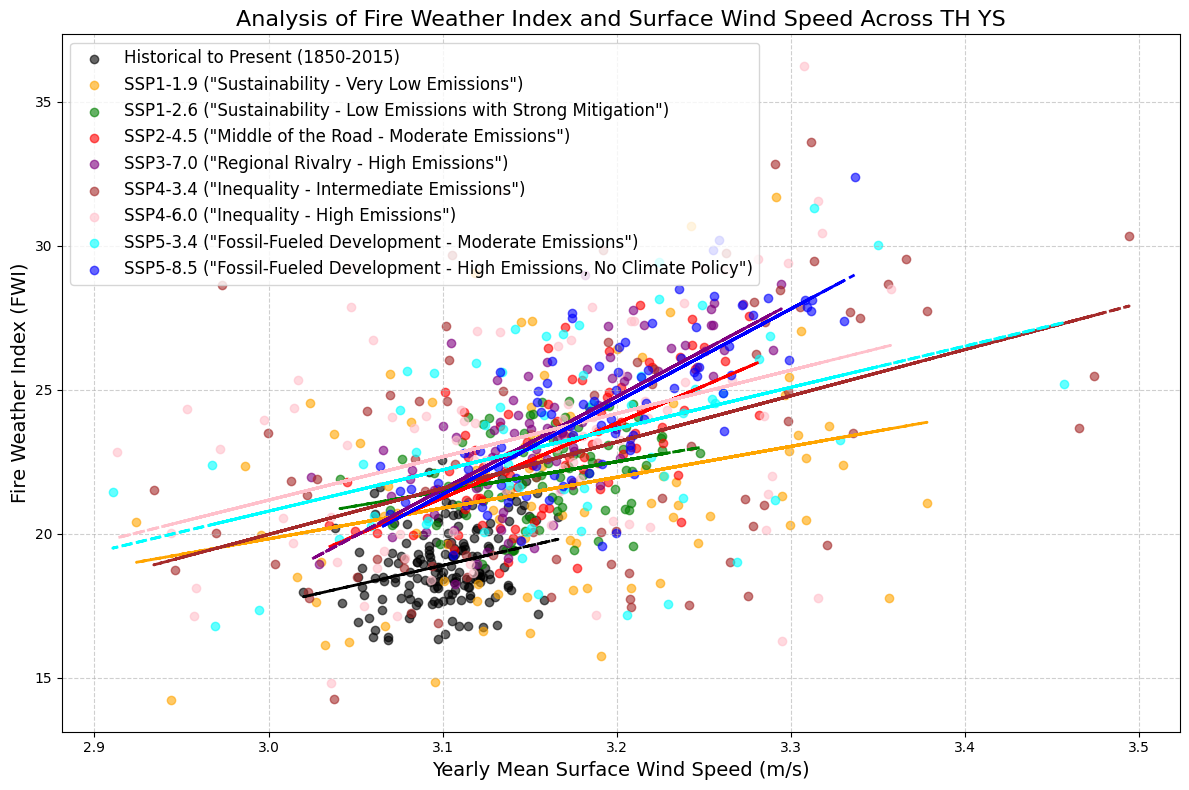

In [186]:
plot_sfcWind_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    sfcWind_means_all_scenarios_th_YS,  # Precomputed Surface Wind Speed means
    labels_sfcWind_all_scenarios, 
    'Analysis of Fire Weather Index and Surface Wind Speed Across TH YS',
    'Avg hum Analysis of Fire Weather Index and Surface Wind Speed Across TH YS.png'
)

Historical to Present (1850-2015): FWI = 14.73 * Wind Speed + -26.75  |  Correlation (r) = 0.291
SSP1-1.9 ("Sustainability - Very Low Emissions"): FWI = 7.28 * Wind Speed + -1.49  |  Correlation (r) = 0.216
SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation"): FWI = 11.87 * Wind Speed + -15.40  |  Correlation (r) = 0.311
SSP2-4.5 ("Middle of the Road - Moderate Emissions"): FWI = 25.58 * Wind Speed + -58.16  |  Correlation (r) = 0.627
SSP3-7.0 ("Regional Rivalry - High Emissions"): FWI = 34.01 * Wind Speed + -83.90  |  Correlation (r) = 0.757
SSP4-3.4 ("Inequality - Intermediate Emissions"): FWI = 20.56 * Wind Speed + -42.35  |  Correlation (r) = 0.573
SSP4-6.0 ("Inequality - High Emissions"): FWI = 14.62 * Wind Speed + -22.88  |  Correlation (r) = 0.374
SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions"): FWI = 9.35 * Wind Speed + -6.49  |  Correlation (r) = 0.281
SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy"): FWI = 30.95 * Wind Speed

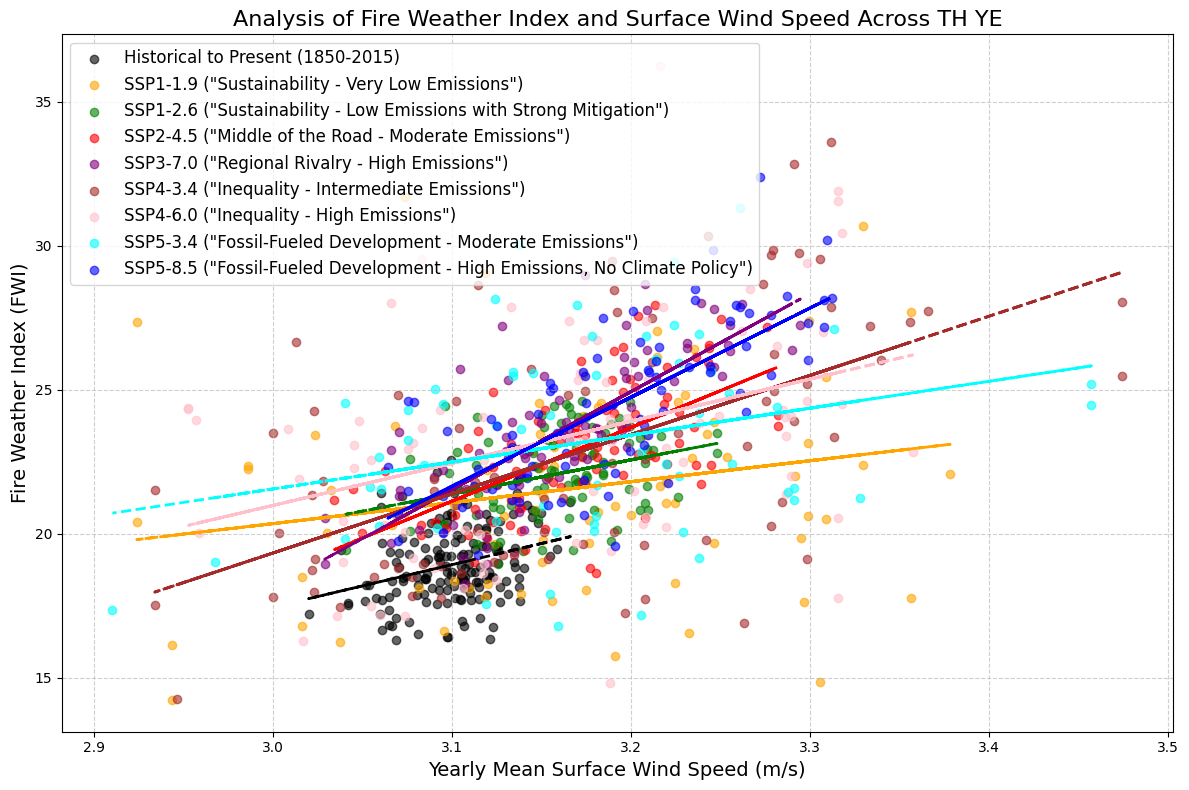

In [188]:
plot_sfcWind_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    sfcWind_means_all_scenarios_th_YE,  # Precomputed Surface Wind Speed means
    labels_sfcWind_all_scenarios, 
    'Analysis of Fire Weather Index and Surface Wind Speed Across TH YE',
    'Avg hum Analysis of Fire Weather Index and Surface Wind Speed Across TH YE.png'
)

In [187]:
labels_sfcWind_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

Historical: FWI = 14.73 * Wind Speed + -26.75  |  r = 0.291
SSP1-1.9: FWI = 7.28 * Wind Speed + -1.49  |  r = 0.216
SSP1-2.6: FWI = 11.87 * Wind Speed + -15.40  |  r = 0.311
SSP2-4.5: FWI = 25.58 * Wind Speed + -58.16  |  r = 0.627
SSP3-7.0: FWI = 34.01 * Wind Speed + -83.90  |  r = 0.757
SSP4-3.4: FWI = 20.56 * Wind Speed + -42.35  |  r = 0.573
SSP4-6.0: FWI = 14.62 * Wind Speed + -22.88  |  r = 0.374
SSP5-3.4: FWI = 9.35 * Wind Speed + -6.49  |  r = 0.281
SSP5-8.5: FWI = 30.95 * Wind Speed + -74.29  |  r = 0.739


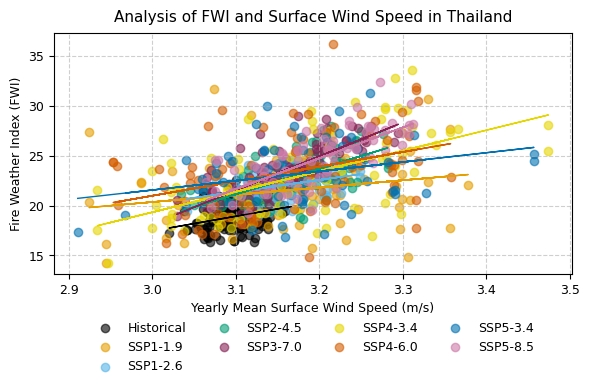

In [189]:
def plot_sfcWind_vs_fwi_with_regression(datasets_fwi, datasets_sfcWind_list, labels, title, filename):
    """
    Plot Surface Wind Speed (sfcWind in m/s) vs Fire Weather Index (FWI) with regression analysis.
    """
    plt.figure(figsize=(3.543, 4.1))

    for dataset_fwi, sfcWind_mean, label in zip(datasets_fwi, datasets_sfcWind_list, labels):
        # Detect key for color-blind-safe color
        if "Historical" in label:
            key = "Historical"
        elif "SSP1-1.9" in label:
            key = "SSP119"
        elif "SSP1-2.6" in label:
            key = "SSP126"
        elif "SSP2-4.5" in label:
            key = "SSP245"
        elif "SSP3-7.0" in label:
            key = "SSP370"
        elif "SSP4-3.4" in label:
            key = "SSP434"
        elif "SSP4-6.0" in label:
            key = "SSP460"
        elif "SSP5-3.4" in label:
            key = "SSP534"
        elif "SSP5-8.5" in label:
            key = "SSP585"
        else:
            key = None

        color = color_blind_palette.get(key, "#000000")

        # Align wind speed with FWI time
        sfcWind_aligned = sfcWind_mean.sel(time=dataset_fwi['time'], method="nearest")
        sfcWind_values = sfcWind_aligned.values
        fwi_mean = dataset_fwi['fwisa'].values

        # Remove NaNs
        valid_mask = ~np.isnan(sfcWind_values) & ~np.isnan(fwi_mean)
        sfcWind_values, fwi_mean = sfcWind_values[valid_mask], fwi_mean[valid_mask]

        if len(sfcWind_values) == 0 or len(fwi_mean) == 0:
            print(f"⚠ Skipping {label}: One or both datasets are empty after cleaning.")
            continue

        # Scatter plot with label (for dot legend)
        plt.scatter(sfcWind_values, fwi_mean, color=color, alpha=0.6, label=label)

        # Regression line (no label so legend stays dot-only)
        slope, intercept, r_value, p_value, std_err = linregress(sfcWind_values, fwi_mean)
        regression_line = slope * sfcWind_values + intercept
        plt.plot(sfcWind_values, regression_line, color=color, linestyle='-', linewidth=1.0)

        print(f"{label}: FWI = {slope:.2f} * Wind Speed + {intercept:.2f}  |  r = {r_value:.3f}")

    # Customize plot
    plt.xlabel('Yearly Mean Surface Wind Speed (m/s)', fontsize=9)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=9)
    # plt.title(title, fontsize=11, y=1.01)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Legend below
    plt.legend(
        fontsize=9,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=4,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=1000)
    plt.show()

#  Call the function using precomputed means
plot_sfcWind_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    sfcWind_means_all_scenarios_th_YE,  # Precomputed Precipitation means
    labels_tasmax_all_scenarios, 
    'Analysis of FWI and Surface Wind Speed in Thailand',
    'Avg hum Analysis of FWI and Surface Wind Speed in Thailand.png'
)


Historical: FWI = 13.66 * Wind Speed + -23.44  |  r = 0.277
SSP1-1.9: FWI = 10.70 * Wind Speed + -12.28  |  r = 0.299
SSP1-2.6: FWI = 10.25 * Wind Speed + -10.31  |  r = 0.278
SSP2-4.5: FWI = 25.95 * Wind Speed + -59.20  |  r = 0.621
SSP3-7.0: FWI = 32.20 * Wind Speed + -78.26  |  r = 0.722
SSP4-3.4: FWI = 16.04 * Wind Speed + -28.14  |  r = 0.468
SSP4-6.0: FWI = 15.03 * Wind Speed + -23.93  |  r = 0.385
SSP5-3.4: FWI = 14.33 * Wind Speed + -22.20  |  r = 0.423
SSP5-8.5: FWI = 32.19 * Wind Speed + -78.43  |  r = 0.762


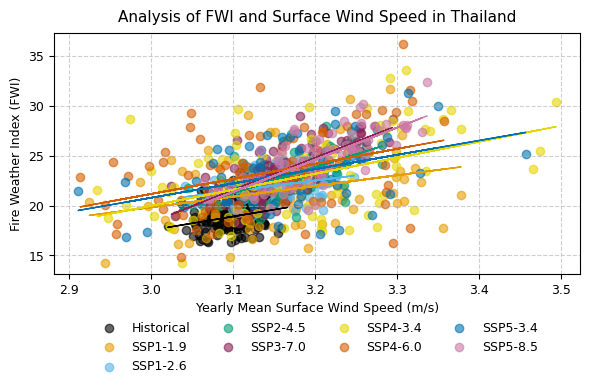

In [190]:
plot_sfcWind_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,  # Precomputed FWI means
    sfcWind_means_all_scenarios_th_YS,  # Precomputed Precipitation means
    labels_tasmax_all_scenarios, 
    'Analysis of FWI and Surface Wind Speed in Thailand',
    'Avg hum Analysis of FWI and Surface Wind Speed in Thailand.png'
)


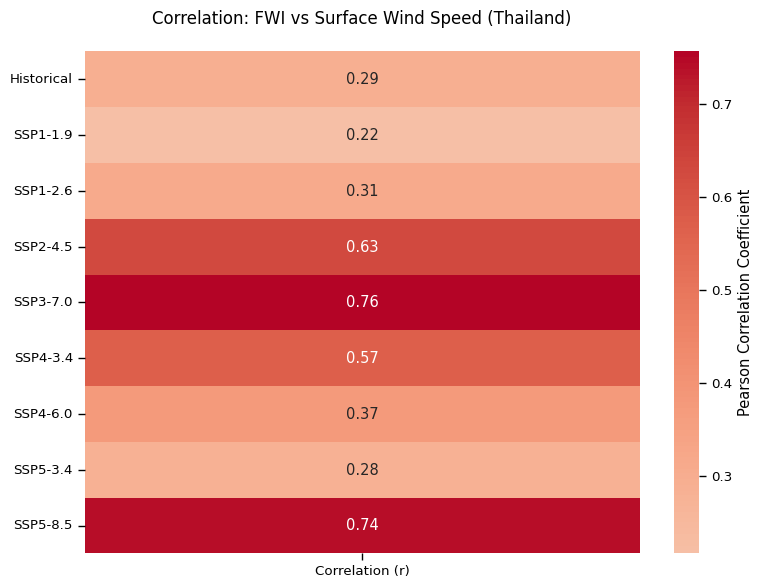

In [234]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

def plot_fwi_wind_correlation_heatmap(datasets_fwi, datasets_sfcWind_list, labels, title, filename):
    """
    Calculates correlation between Wind Speed and FWI for each scenario 
    and represents it as a Seaborn heatmap.
    """
    correlation_data = {}

    for dataset_fwi, sfcWind_mean, label in zip(datasets_fwi, datasets_sfcWind_list, labels):
        # Align wind speed with FWI time
        sfcWind_aligned = sfcWind_mean.sel(time=dataset_fwi['time'], method="nearest")
        sfcWind_values = sfcWind_aligned.values.flatten()
        fwi_values = dataset_fwi['fwisa'].values.flatten()

        # Clean NaNs
        mask = ~np.isnan(sfcWind_values) & ~np.isnan(fwi_values)
        if np.any(mask):
            # Calculate Pearson correlation (r)
            r_value = np.corrcoef(sfcWind_values[mask], fwi_values[mask])[0, 1]
            correlation_data[label] = r_value
        else:
            correlation_data[label] = np.nan

    # Convert dictionary to a DataFrame for Seaborn
    # We create a 1D matrix shape for a clear comparison across scenarios
    df_corr = pd.DataFrame.from_dict(correlation_data, orient='index', columns=['Correlation (r)'])

    # Plotting
    plt.figure(figsize=(3.543, 6))
    sns.set_context("paper", font_scale=1.1)
    
    # cmap 'coolwarm' is great for correlations (-1 to 1)
    ax = sns.heatmap(df_corr, 
                     annot=True, 
                     fmt=".2f", 
                     cmap='coolwarm', 
                     center=0,
                     cbar_kws={'label': 'Pearson Correlation Coefficient'})

    # plt.title(title, fontsize=12, pad=20)
    plt.tight_layout()
    
    plt.savefig(filename, dpi=1000)
    plt.show()

# Updated Call
plot_fwi_wind_correlation_heatmap(
    ensemble_means_th_all_scenarios, 
    sfcWind_means_all_scenarios_th_YE, 
    labels_tasmax_all_scenarios, 
    'Correlation: FWI vs Surface Wind Speed (Thailand)',
    'Heatmap_FWI_Wind_Correlation.png'
)

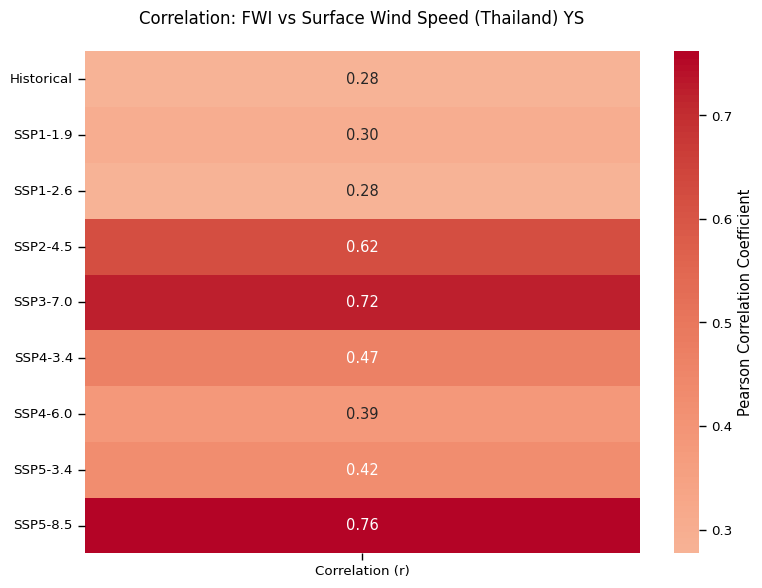

In [235]:
plot_fwi_wind_correlation_heatmap(
    ensemble_means_th_all_scenarios, 
    sfcWind_means_all_scenarios_th_YS, 
    labels_tasmax_all_scenarios, 
    'Correlation: FWI vs Surface Wind Speed (Thailand) YS',
    'Heatmap_FWI_Wind_Correlation_YS.png'
)

In [196]:
def plot_sfcWind_vs_fwi_with_oneregression(datasets_fwi, datasets_sfcWind_list, labels, title, filename):
    """
    Plot Surface Wind Speed (sfcWind in m/s) vs Fire Weather Index (FWI) with regression analysis.
    
    Args:
        datasets_fwi (list): List of xarray datasets containing 'fwisa' (yearly).
        datasets_sfcWind_list (list): List of precomputed surface wind speed means per scenario.
        labels (list): Corresponding labels for scenarios.
        title (str): Title for the plot.
        filename (str): Filename to save the plot.
    """
    plt.figure(figsize=(3.543, 8))
    
    colors = ['black', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'cyan', 'blue']

    # Initialize empty lists for combined surface wind speed and FWI data
    combined_sfcWind = []
    combined_fwi = []

    for dataset_fwi, sfcWind_mean, label, color in zip(datasets_fwi, datasets_sfcWind_list, labels, colors):
    
        # Align surface wind speed with FWI time
        sfcWind_aligned = sfcWind_mean.sel(time=dataset_fwi['time'], method="nearest")

        # Compute mean FWI
        fwi_mean = dataset_fwi['fwisa'].values
        sfcWind_values = sfcWind_aligned.values  # Assuming wind speed is in m/s

        # Remove NaN values before regression
        valid_mask = ~np.isnan(sfcWind_values) & ~np.isnan(fwi_mean)
        sfcWind_values, fwi_mean = sfcWind_values[valid_mask], fwi_mean[valid_mask]

        # Ensure both arrays have valid data before regression
        if len(sfcWind_values) == 0 or len(fwi_mean) == 0:
            print(f"⚠ Skipping {label}: One or both datasets are empty after cleaning.")
            continue  # Skip empty datasets

        # Append data to combined lists
        combined_sfcWind.extend(sfcWind_values)
        combined_fwi.extend(fwi_mean)

        # Scatter plot for each scenario
        plt.scatter(sfcWind_values, fwi_mean, label=label, color=color, alpha=0.6)

    # Compute linear regression (y = mx + c) for the combined data
    if len(combined_sfcWind) > 0 and len(combined_fwi) > 0:
        slope, intercept, r_value, p_value, std_err = linregress(combined_sfcWind, combined_fwi)
        regression_line = slope * np.array(combined_sfcWind) + intercept

        # Plot a single regression line for all data points
        plt.plot(combined_sfcWind, regression_line, color='black', linestyle='--', linewidth=2)

        # Print the regression equation and correlation for all scenarios
        print(f"All scenarios: FWI = {slope:.4f} * Wind Speed + {intercept:.4f}  |  Correlation (r) = {r_value:.4f}")
    else:
        print("No valid data to compute regression.")

    # Customize the plot
    plt.xlabel('Yearly Mean Surface Wind Speed (m/s)', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    # plt.title(title, fontsize=16)
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(filename, dpi=1000)
    plt.show()


Historical: FWI = 14.73 * Wind Speed + -26.75  |  r = 0.291
SSP1-1.9: FWI = 7.28 * Wind Speed + -1.49  |  r = 0.216
SSP1-2.6: FWI = 11.87 * Wind Speed + -15.40  |  r = 0.311
SSP2-4.5: FWI = 25.58 * Wind Speed + -58.16  |  r = 0.627
SSP3-7.0: FWI = 34.01 * Wind Speed + -83.90  |  r = 0.757
SSP4-3.4: FWI = 20.56 * Wind Speed + -42.35  |  r = 0.573
SSP4-6.0: FWI = 14.62 * Wind Speed + -22.88  |  r = 0.374
SSP5-3.4: FWI = 9.35 * Wind Speed + -6.49  |  r = 0.281
SSP5-8.5: FWI = 30.95 * Wind Speed + -74.29  |  r = 0.739


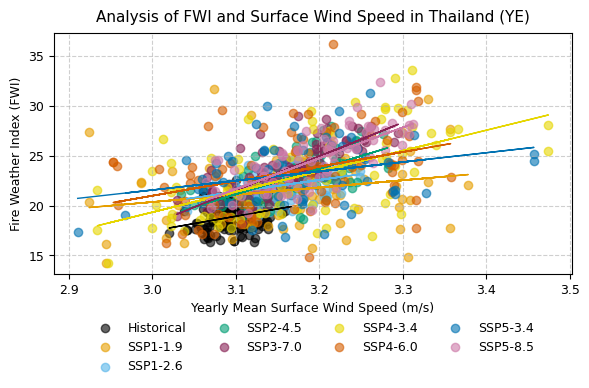

In [212]:
# ── Thailand — sfcWind YE ─────────────────────────────────────────────────────
plot_sfcWind_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,
    sfcWind_means_all_scenarios_th_YE,
    labels_tasmax_all_scenarios,
    'Analysis of FWI and Surface Wind Speed in Thailand (YE)',
    'FWI_vs_sfcWind_Thailand_YE.png'
)

Historical: FWI = 13.66 * Wind Speed + -23.44  |  r = 0.277
SSP1-1.9: FWI = 10.70 * Wind Speed + -12.28  |  r = 0.299
SSP1-2.6: FWI = 10.25 * Wind Speed + -10.31  |  r = 0.278
SSP2-4.5: FWI = 25.95 * Wind Speed + -59.20  |  r = 0.621
SSP3-7.0: FWI = 32.20 * Wind Speed + -78.26  |  r = 0.722
SSP4-3.4: FWI = 16.04 * Wind Speed + -28.14  |  r = 0.468
SSP4-6.0: FWI = 15.03 * Wind Speed + -23.93  |  r = 0.385
SSP5-3.4: FWI = 14.33 * Wind Speed + -22.20  |  r = 0.423
SSP5-8.5: FWI = 32.19 * Wind Speed + -78.43  |  r = 0.762


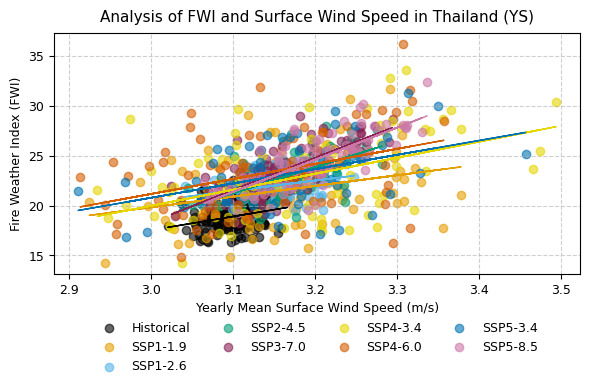

In [213]:
# ── Thailand — sfcWind YS ─────────────────────────────────────────────────────
plot_sfcWind_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,
    sfcWind_means_all_scenarios_th_YS,
    labels_tasmax_all_scenarios,
    'Analysis of FWI and Surface Wind Speed in Thailand (YS)',
    'FWI_vs_sfcWind_Thailand_YS.png'
)

In [200]:
color_blind_palette = {
        "Historical": "#000000",  # black
        "SSP119": "#E69F00",      # orange
        "SSP126": "#56B4E9",      # sky blue
        "SSP245": "#009E73",      # green
        "SSP370": "#882255",      # deep wine red
        "SSP434": "#E6D600",      # yellow
        "SSP460": "#D55E00",      # vermilion
        "SSP534": "#0072B2",      # navy blue
        "SSP585": "#CC79A7"       # reddish purple
    }
def plot_hurs_vs_fwi_with_regression(datasets_fwi, datasets_hurs_list, labels, title, filename):
    """
    Plot Relative Humidity (hurs in %) vs Fire Weather Index (FWI) with regression analysis.
    """
    plt.figure(constrained_layout=True, figsize=(3.543, 4.1))

    for dataset_fwi, hurs_mean, label in zip(datasets_fwi, datasets_hurs_list, labels):
        # Detect key for color-blind-safe palette
        if "Historical" in label:
            key = "Historical"
        elif "SSP1-1.9" in label:
            key = "SSP119"
        elif "SSP1-2.6" in label:
            key = "SSP126"
        elif "SSP2-4.5" in label:
            key = "SSP245"
        elif "SSP3-7.0" in label:
            key = "SSP370"
        elif "SSP4-3.4" in label:
            key = "SSP434"
        elif "SSP4-6.0" in label:
            key = "SSP460"
        elif "SSP5-3.4" in label:
            key = "SSP534"
        elif "SSP5-8.5" in label:
            key = "SSP585"
        else:
            key = None

        color = color_blind_palette.get(key, "#000000")

        # Align relative humidity with FWI time
        hurs_aligned = hurs_mean.sel(time=dataset_fwi['time'], method="nearest")
        hurs_values = hurs_aligned.values
        fwi_mean = dataset_fwi['fwisa'].values

        # Remove NaNs
        valid_mask = ~np.isnan(hurs_values) & ~np.isnan(fwi_mean)
        hurs_values, fwi_mean = hurs_values[valid_mask], fwi_mean[valid_mask]

        if len(hurs_values) == 0 or len(fwi_mean) == 0:
            print(f"⚠ Skipping {label}: One or both datasets are empty after cleaning.")
            continue

        # Scatter plot (dot legend)
        plt.scatter(hurs_values, fwi_mean, color=color, alpha=0.6, label=label)

        # Regression line
        slope, intercept, r_value, p_value, std_err = linregress(hurs_values, fwi_mean)
        regression_line = slope * hurs_values + intercept
        plt.plot(hurs_values, regression_line, color=color, linestyle='-', linewidth=1.0)

        print(f"{label}: FWI = {slope:.2f} * Relative Humidity + {intercept:.2f}  |  r = {r_value:.3f}")

    # Customize plot
    plt.xlabel('Yearly Mean Relative Humidity (%)', fontsize=9)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=9)
    # plt.title(title, fontsize=11, y=1.01)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Legend below
    plt.legend(
        fontsize=9,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=4,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(filename, dpi=1000)
    plt.show()
labels_tasmax_all_scenarios = [
    'Historical',
    'SSP1-1.9',
    'SSP1-2.6',
    'SSP2-4.5',
    'SSP3-7.0',
    'SSP4-3.4',
    'SSP4-6.0',
    'SSP5-3.4',
    'SSP5-8.5'
]

In [201]:
def plot_hurs_vs_fwi_with_oneregression(datasets_fwi, datasets_hurs_list, labels, title, filename):
    """
    Plot Relative Humidity (hurs in %) vs Fire Weather Index (FWI) with regression analysis.
    
    Args:
        datasets_fwi (list): List of xarray datasets containing 'fwisa' (yearly).
        datasets_hurs_list (list): List of precomputed relative humidity means per scenario.
        labels (list): Corresponding labels for scenarios.
        title (str): Title for the plot.
        filename (str): Filename to save the plot.
    """
    plt.figure(figsize=(3.543, 8))
    
    colors = ['black', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'cyan', 'blue']

    # Initialize empty lists for combined relative humidity and FWI data
    combined_hurs = []
    combined_fwi = []

    for dataset_fwi, hurs_mean, label, color in zip(datasets_fwi, datasets_hurs_list, labels, colors):
    
        # Align relative humidity with FWI time
        hurs_aligned = hurs_mean.sel(time=dataset_fwi['time'], method="nearest")

        # Compute mean FWI
        fwi_mean = dataset_fwi['fwisa'].values
        hurs_values = hurs_aligned.values  # Relative humidity in %

        # Remove NaN values before regression
        valid_mask = ~np.isnan(hurs_values) & ~np.isnan(fwi_mean)
        hurs_values, fwi_mean = hurs_values[valid_mask], fwi_mean[valid_mask]

        # Ensure both arrays have valid data before regression
        if len(hurs_values) == 0 or len(fwi_mean) == 0:
            print(f"⚠ Skipping {label}: One or both datasets are empty after cleaning.")
            continue  # Skip empty datasets

        # Append data to combined lists
        combined_hurs.extend(hurs_values)
        combined_fwi.extend(fwi_mean)

        # Scatter plot for each scenario
        plt.scatter(hurs_values, fwi_mean, label=label, color=color, alpha=0.6)

    # Compute linear regression (y = mx + c) for the combined data
    if len(combined_hurs) > 0 and len(combined_fwi) > 0:
        slope, intercept, r_value, p_value, std_err = linregress(combined_hurs, combined_fwi)
        regression_line = slope * np.array(combined_hurs) + intercept

        # Plot a single regression line for all data points
        plt.plot(combined_hurs, regression_line, color='black', linestyle='--', linewidth=2)

        # Print the regression equation and correlation for all scenarios
        print(f"All scenarios: FWI = {slope:.4f} * Relative Humidity + {intercept:.4f}  |  Correlation (r) = {r_value:.4f}")
    else:
        print("No valid data to compute regression.")

    # Customize the plot
    plt.xlabel('Yearly Mean Relative Humidity (%)', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    # plt.title(title, fontsize=16)
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(filename, dpi=1000)
    plt.show()


Historical: FWI = -1.54 * Relative Humidity + 139.98  |  r = -0.773
SSP1-1.9: FWI = -0.73 * Relative Humidity + 77.47  |  r = -0.326
SSP1-2.6: FWI = -0.60 * Relative Humidity + 68.21  |  r = -0.243
SSP2-4.5: FWI = -1.66 * Relative Humidity + 149.96  |  r = -0.719
SSP3-7.0: FWI = -2.06 * Relative Humidity + 181.40  |  r = -0.772
SSP4-3.4: FWI = -1.24 * Relative Humidity + 117.69  |  r = -0.593
SSP4-6.0: FWI = -1.35 * Relative Humidity + 126.29  |  r = -0.542
SSP5-3.4: FWI = -0.86 * Relative Humidity + 88.77  |  r = -0.411
SSP5-8.5: FWI = -2.10 * Relative Humidity + 184.36  |  r = -0.729


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/19731903.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.05, 1, 1])


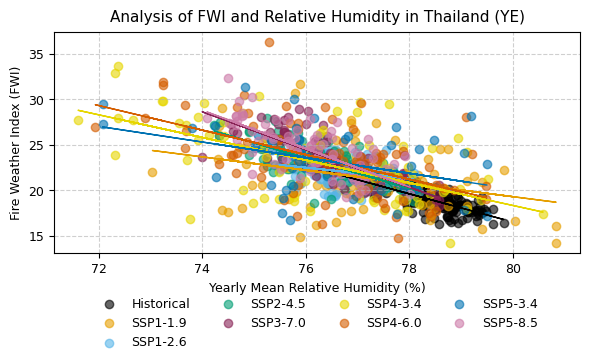

In [210]:
# ── Thailand — hurs YE ────────────────────────────────────────────────────────
plot_hurs_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,
    hurs_means_all_scenarios_th_YE,
    labels_tasmax_all_scenarios,
    'Analysis of FWI and Relative Humidity in Thailand (YE)',
    'FWI_vs_hurs_Thailand_YE.png'
)

Historical: FWI = -1.88 * Relative Humidity + 166.11  |  r = -0.936
SSP1-1.9: FWI = -2.04 * Relative Humidity + 178.26  |  r = -0.876
SSP1-2.6: FWI = -1.93 * Relative Humidity + 169.96  |  r = -0.838
SSP2-4.5: FWI = -2.18 * Relative Humidity + 189.76  |  r = -0.917
SSP3-7.0: FWI = -2.49 * Relative Humidity + 213.58  |  r = -0.940
SSP4-3.4: FWI = -1.86 * Relative Humidity + 164.59  |  r = -0.913
SSP4-6.0: FWI = -2.25 * Relative Humidity + 195.49  |  r = -0.910
SSP5-3.4: FWI = -1.96 * Relative Humidity + 172.73  |  r = -0.896
SSP5-8.5: FWI = -2.71 * Relative Humidity + 230.74  |  r = -0.969


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_97368/19731903.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.05, 1, 1])


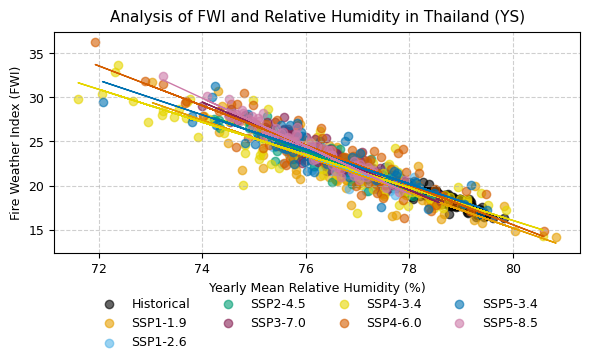

In [211]:
# ── Thailand — hurs YS ────────────────────────────────────────────────────────
plot_hurs_vs_fwi_with_regression(
    ensemble_means_th_all_scenarios,
    hurs_means_all_scenarios_th_YS,
    labels_tasmax_all_scenarios,
    'Analysis of FWI and Relative Humidity in Thailand (YS)',
    'FWI_vs_hurs_Thailand_YS.png'
)

In [218]:
def _to_series_1d_YS(x, name):
    """Normalize input to pd.Series with Year Start (YS) DatetimeIndex."""
    if isinstance(x, xr.DataArray):
        if 'time' not in x.coords:
            raise ValueError(f"{name}: xarray.DataArray must have 'time' coordinate.")
        idx = pd.DatetimeIndex(pd.to_datetime(x['time'].values))
        s = pd.Series(x.values, index=idx, name=name)
    elif isinstance(x, pd.Series):
        s = x.copy()
        if not isinstance(s.index, pd.DatetimeIndex):
            s.index = pd.to_datetime(s.index)
        s.name = name
    else:
        raise TypeError(f"{name}: expected xr.DataArray or pd.Series, got {type(x)}")

    s = s.sort_index()
    # 'S' or 'start' yields YYYY-01-01
    year_index = s.index.to_period('Y').to_timestamp(how='start')
    s = pd.Series(s.values, index=year_index, name=name)
    s = s[~s.index.duplicated(keep='first')]
    return s

def _align_to_years_YS(src: pd.Series, target_years: pd.DatetimeIndex) -> pd.Series:
    """Reindex src to match target_years (Year Start)."""
    src_years = src.index.to_period('Y').to_timestamp(how='start')
    s2 = pd.Series(src.values, index=src_years, name=src.name)
    return s2.reindex(target_years, method='nearest')


def _to_series_1d_YE(x, name):
    """Normalize input to pd.Series with Year End (YE) DatetimeIndex."""
    if isinstance(x, xr.DataArray):
        if 'time' not in x.coords:
            raise ValueError(f"{name}: xarray.DataArray must have 'time' coordinate.")
        idx = pd.DatetimeIndex(pd.to_datetime(x['time'].values))
        s = pd.Series(x.values, index=idx, name=name)
    elif isinstance(x, pd.Series):
        s = x.copy()
        if not isinstance(s.index, pd.DatetimeIndex):
            s.index = pd.to_datetime(s.index)
        s.name = name
    else:
        raise TypeError(f"{name}: expected xr.DataArray or pd.Series, got {type(x)}")

    s = s.sort_index()
    # 'E' or 'end' yields YYYY-12-31
    year_index = s.index.to_period('Y').to_timestamp(how='end')
    s = pd.Series(s.values, index=year_index, name=name)
    s = s[~s.index.duplicated(keep='first')]
    return s

def _align_to_years_YE(src: pd.Series, target_years: pd.DatetimeIndex) -> pd.Series:
    """Reindex src to match target_years (Year End)."""
    src_years = src.index.to_period('Y').to_timestamp(how='end')
    s2 = pd.Series(src.values, index=src_years, name=src.name)
    return s2.reindex(target_years, method='nearest')
    

In [222]:
def prepare_panel_th_for_mlr_YE(
    fwi_means_list, tas_means_list, pr_means_list, hurs_means_list, wind_means_list,
    labels,
    *,
    fwi_var='fwisa', tas_var='tasmax', pr_var='pr', hurs_var='hurs', wind_var='sfcWind',
    tas_in_kelvin=False,      # True if tas means are still Kelvin -> convert to °C
    pr_in_kg_m2_s=False       # True if pr is kg m^-2 s^-1 -> convert to mm/day
):
    """
    Build a panel DataFrame for MLR using precomputed (Thailand) yearly means per scenario.
    Inputs are lists aligned by scenario index.

    Returns DataFrame with columns:
      ['time','scenario','FWI','tasmax','pr','hurs','sfcWind']
    """
    rows = []

    for fwi_m, tas_m, pr_m, hurs_m, wind_m, label in zip(
        fwi_means_list, tas_means_list, pr_means_list, hurs_means_list, wind_means_list, labels
    ):
        # Normalize to pd.Series with yearly DatetimeIndex
        fwi_s   = _to_series_1d_YE(fwi_m if not isinstance(fwi_m, xr.Dataset) else fwi_m[fwi_var], 'FWI')
        tas_s   = _to_series_1d_YE(tas_m if not isinstance(tas_m, xr.Dataset) else tas_m[tas_var], 'tasmax')
        pr_s    = _to_series_1d_YE(pr_m  if not isinstance(pr_m,  xr.Dataset) else pr_m[pr_var],   'pr')
        hurs_s  = _to_series_1d_YE(hurs_m if not isinstance(hurs_m, xr.Dataset) else hurs_m[hurs_var], 'hurs')
        wind_s  = _to_series_1d_YE(wind_m if not isinstance(wind_m, xr.Dataset) else wind_m[wind_var], 'sfcWind')

        # Align all to FWI years
        target_years = fwi_s.index.to_period('Y').to_timestamp('Y')
        tas_s  = _align_to_years_YE(tas_s,  target_years)
        pr_s   = _align_to_years_YE(pr_s,   target_years)
        hurs_s = _align_to_years_YE(hurs_s, target_years)
        wind_s = _align_to_years_YE(wind_s, target_years)
        fwi_s  = fwi_s.reindex(target_years)  # already those years

        # Unit conversions
        if tas_in_kelvin:
            tas_s = tas_s - 273.15          # -> °C
        if pr_in_kg_m2_s:
            pr_s = pr_s * 86400.0           # -> mm/day

        # Assemble scenario chunk
        df = pd.DataFrame({
            'time'   : target_years.year.astype(int),
            'FWI'    : pd.to_numeric(fwi_s.values,   errors='coerce'),
            'tasmax' : pd.to_numeric(tas_s.values,   errors='coerce'),
            'pr'     : pd.to_numeric(pr_s.values,    errors='coerce'),
            'hurs'   : pd.to_numeric(hurs_s.values,  errors='coerce'),
            'sfcWind': pd.to_numeric(wind_s.values,  errors='coerce'),
            'scenario': label
        })
        rows.append(df)

    panel_df = pd.concat(rows, ignore_index=True)

    # Clean for MLR
    panel_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    panel_df.dropna(subset=['FWI','tasmax','pr','hurs','sfcWind'], inplace=True)
    panel_df['time'] = panel_df['time'].astype(int)

    return panel_df

In [224]:
def prepare_panel_th_for_mlr_YS(
    fwi_means_list, tas_means_list, pr_means_list, hurs_means_list, wind_means_list,
    labels,
    *,
    fwi_var='fwisa', tas_var='tasmax', pr_var='pr', hurs_var='hurs', wind_var='sfcWind',
    tas_in_kelvin=False,      # True if tas means are still Kelvin -> convert to °C
    pr_in_kg_m2_s=False       # True if pr is kg m^-2 s^-1 -> convert to mm/day
):
    """
    Build a panel DataFrame for MLR using precomputed (Thailand) yearly means per scenario.
    Inputs are lists aligned by scenario index.

    Returns DataFrame with columns:
      ['time','scenario','FWI','tasmax','pr','hurs','sfcWind']
    """
    rows = []

    for fwi_m, tas_m, pr_m, hurs_m, wind_m, label in zip(
        fwi_means_list, tas_means_list, pr_means_list, hurs_means_list, wind_means_list, labels
    ):
        # Normalize to pd.Series with yearly DatetimeIndex
        fwi_s   = _to_series_1d_YS(fwi_m if not isinstance(fwi_m, xr.Dataset) else fwi_m[fwi_var], 'FWI')
        tas_s   = _to_series_1d_YS(tas_m if not isinstance(tas_m, xr.Dataset) else tas_m[tas_var], 'tasmax')
        pr_s    = _to_series_1d_YS(pr_m  if not isinstance(pr_m,  xr.Dataset) else pr_m[pr_var],   'pr')
        hurs_s  = _to_series_1d_YS(hurs_m if not isinstance(hurs_m, xr.Dataset) else hurs_m[hurs_var], 'hurs')
        wind_s  = _to_series_1d_YS(wind_m if not isinstance(wind_m, xr.Dataset) else wind_m[wind_var], 'sfcWind')

        # Align all to FWI years
        target_years = fwi_s.index.to_period('Y').to_timestamp('Y')
        tas_s  = _align_to_years_YS(tas_s,  target_years)
        pr_s   = _align_to_years_YS(pr_s,   target_years)
        hurs_s = _align_to_years_YS(hurs_s, target_years)
        wind_s = _align_to_years_YS(wind_s, target_years)
        fwi_s  = fwi_s.reindex(target_years)  # already those years

        # Unit conversions
        if tas_in_kelvin:
            tas_s = tas_s - 273.15          # -> °C
        if pr_in_kg_m2_s:
            pr_s = pr_s * 86400.0           # -> mm/day

        # Assemble scenario chunk
        df = pd.DataFrame({
            'time'   : target_years.year.astype(int),
            'FWI'    : pd.to_numeric(fwi_s.values,   errors='coerce'),
            'tasmax' : pd.to_numeric(tas_s.values,   errors='coerce'),
            'pr'     : pd.to_numeric(pr_s.values,    errors='coerce'),
            'hurs'   : pd.to_numeric(hurs_s.values,  errors='coerce'),
            'sfcWind': pd.to_numeric(wind_s.values,  errors='coerce'),
            'scenario': label
        })
        rows.append(df)

    panel_df = pd.concat(rows, ignore_index=True)

    # Clean for MLR
    panel_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    panel_df.dropna(subset=['FWI','tasmax','pr','hurs','sfcWind'], inplace=True)
    panel_df['time'] = panel_df['time'].astype(int)

    return panel_df

In [226]:
panel_df_th_YE = prepare_panel_th_for_mlr_YE(
    fwi_means_list=ensemble_means_th_all_scenarios,     # yearly FWI means (1D)
    tas_means_list=tasmax_means_all_scenarios_th_YE,          # yearly tasmax means
    pr_means_list=pr_means_all_scenarios_th_YE,            # yearly pr means
    hurs_means_list=hurs_means_all_scenarios_th_YE,        # yearly RH means
    wind_means_list=sfcWind_means_all_scenarios_th_YE,     # yearly wind means
    labels=labels_tasmax_all_scenarios,
    tas_in_kelvin=False,     # set True if tas list is still in Kelvin
    pr_in_kg_m2_s=True      # set True if pr list is kg m^-2 s^-1
)


In [232]:
panel_df_th_YE

,time,FWI,tasmax,pr,hurs,sfcWind,scenario


In [227]:
panel_df_th_YS = prepare_panel_th_for_mlr_YS(
    fwi_means_list=ensemble_means_th_all_scenarios,     # yearly FWI means (1D)
    tas_means_list=tasmax_means_all_scenarios_th_YS,          # yearly tasmax means
    pr_means_list=pr_means_all_scenarios_th_YS,            # yearly pr means
    hurs_means_list=hurs_means_all_scenarios_th_YS,        # yearly RH means
    wind_means_list=sfcWind_means_all_scenarios_th_YS,     # yearly wind means
    labels=labels_tasmax_all_scenarios,
    tas_in_kelvin=False,     # set True if tas list is still in Kelvin
    pr_in_kg_m2_s=True      # set True if pr list is kg m^-2 s^-1
)


In [229]:
import statsmodels.formula.api as smf
from scipy.stats import zscore

# --- 1) Check for YE panel ---
assert 'panel_df_th_YE' in globals(), "panel_df_th_YE not found. Run the YE preprocess step first."
df_ye = panel_df_th_YE.copy()
assert len(df_ye) > 0, "Empty panel_df_th_YE after preprocessing."

# --- 2) Formula ---
use_fe = df_ye['scenario'].nunique() >= 2
formula = "FWI ~ tasmax + pr + hurs + sfcWind" + (" + C(scenario)" if use_fe else "")

# --- 3) Fit OLS (YE) ---
mlr_model_ye = smf.ols(formula, data=df_ye).fit(cov_type='HC1')
print("\n=== [YE] OLS (HC1 robust SE) ===")
print(mlr_model_ye.summary())

# --- 4) Standardized (beta) coefficients (YE) ---
df_std_ye = df_ye.copy()
to_z = ['FWI','tasmax','pr','hurs','sfcWind']
df_std_ye[to_z] = df_std_ye[to_z].apply(zscore)

mlr_model_beta_ye = smf.ols(formula, data=df_std_ye).fit(cov_type='HC1')
print("\n=== [YE] Standardized (beta) coefficients ===")
print(mlr_model_beta_ye.params[['tasmax','pr','hurs','sfcWind']])

AssertionError: Empty panel_df_th_YE after preprocessing.

In [ ]:
import statsmodels.formula.api as smf
from scipy.stats import zscore

# --- 1) Check for YS panel ---
assert 'panel_df_th_YS' in globals(), "panel_df_th_YS not found. Run the YS preprocess step first."
df_ys = panel_df_th_YS.copy()
assert len(df_ys) > 0, "Empty panel_df_th_YS after preprocessing."

# --- 2) Formula ---
use_fe = df_ys['scenario'].nunique() >= 2
formula = "FWI ~ tasmax + pr + hurs + sfcWind" + (" + C(scenario)" if use_fe else "")

# --- 3) Fit OLS (YS) ---
mlr_model_ys = smf.ols(formula, data=df_ys).fit(cov_type='HC1')
print("\n=== [YS] OLS (HC1 robust SE) ===")
print(mlr_model_ys.summary())

# --- 4) Standardized (beta) coefficients (YS) ---
df_std_ys = df_ys.copy()
to_z = ['FWI','tasmax','pr','hurs','sfcWind']
df_std_ys[to_z] = df_std_ys[to_z].apply(zscore)

mlr_model_beta_ys = smf.ols(formula, data=df_std_ys).fit(cov_type='HC1')
print("\n=== [YS] Standardized (beta) coefficients ===")
print(mlr_model_beta_ys.params[['tasmax','pr','hurs','sfcWind']])

In [ ]:
y = panel_df_th['FWI'].values
yhat = mlr_model.fittedvalues.values
resid = mlr_model.resid.values

# Fitted vs Actual
plt.figure(figsize=(3.543, 4))
plt.scatter(yhat, y, s=15, alpha=0.6)
mn, mx = np.min([y,yhat]), np.max([y,yhat])
plt.plot([mn,mx],[mn,mx], lw=2)
plt.xlabel("Fitted FWI")
plt.ylabel("Actual FWI")
# plt.title("Fitted vs. Actual")
plt.tight_layout(); plt.show()

# Residuals histogram
plt.figure(figsize=(3.543, 4))
plt.hist(resid, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
# plt.title("Residuals Histogram")
plt.tight_layout(); plt.show()


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Clean dataset before VIF / regression
cols = ["FWI", "tasmax", "pr", "hurs", "sfcWind"]

# Ensure numeric
for c in cols:
    panel_df_th[c] = pd.to_numeric(panel_df_th[c], errors="coerce")

# Replace inf/-inf with NaN
panel_df_th.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with missing values
panel_df_clean = panel_df_th.dropna(subset=cols).copy()

print(panel_df_clean.shape)


X = panel_df_clean[["tasmax", "pr", "hurs", "sfcWind"]]
X = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

df = panel_df_added_h2o.copy()

cols5 = ['tasmax','pr','hurs','sfcWind','h2o']
cols4 = ['tasmax','pr','hurs','sfcWind']

# Use the 5-variable non-missing mask for BOTH runs
mask5 = df[cols5].replace([np.inf,-np.inf], np.nan).dropna().index

X5 = df.loc[mask5, cols5]
X4_same_rows = df.loc[mask5, cols4]

X5 = sm.add_constant(X5, has_constant='add')
X4_same_rows = sm.add_constant(X4_same_rows, has_constant='add')

vif5 = pd.Series([variance_inflation_factor(X5.values, i) for i in range(X5.shape[1])],
                 index=X5.columns, name='VIF_5vars')

vif4_same = pd.Series([variance_inflation_factor(X4_same_rows.values, i) for i in range(X4_same_rows.shape[1])],
                      index=X4_same_rows.columns, name='VIF_4vars_same_rows')

print(vif4_same.round(3))
print(vif5.round(3))


In [ ]:

df = panel_df_added_h2o.copy()

preds4_hurs = ['tasmax','pr','hurs','sfcWind']
preds4_h2o  = ['tasmax','pr','h2o','sfcWind']      # <-- replaced hurs with h2o
preds5      = ['tasmax','pr','hurs','sfcWind','h2o']

# Use the 5-variable complete-case mask for apples-to-apples comparison
mask5 = df[preds5].apply(pd.to_numeric, errors='coerce') \
                  .replace([np.inf,-np.inf], np.nan) \
                  .dropna().index

# Build X matrices on the SAME rows
X4_hurs = df.loc[mask5, preds4_hurs]
X4_h2o  = df.loc[mask5, preds4_h2o]
X5      = df.loc[mask5, preds5]

# Add intercepts
X4_hurs = sm.add_constant(X4_hurs, has_constant='add')
X4_h2o  = sm.add_constant(X4_h2o,  has_constant='add')
X5      = sm.add_constant(X5,      has_constant='add')

# Compute VIFs
vif4_hurs = pd.Series(
    [variance_inflation_factor(X4_hurs.values, i) for i in range(X4_hurs.shape[1])],
    index=X4_hurs.columns, name='VIF_4vars_hurs_same_rows'
)
vif4_h2o = pd.Series(
    [variance_inflation_factor(X4_h2o.values, i) for i in range(X4_h2o.shape[1])],
    index=X4_h2o.columns, name='VIF_4vars_h2o_same_rows'
)
vif5 = pd.Series(
    [variance_inflation_factor(X5.values, i) for i in range(X5.shape[1])],
    index=X5.columns, name='VIF_5vars'
)

print(vif4_hurs.round(3))
print(vif4_h2o.round(3))
print(vif5.round(3))

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Clean dataset before VIF / regression
cols = ["FWI", "tasmax", "pr", "h2o", "sfcWind"]

# Ensure numeric
for c in cols:
    panel_df_th_replaced_h2o[c] = pd.to_numeric(panel_df_th_replaced_h2o[c], errors="coerce")

# Replace inf/-inf with NaN
panel_df_th_replaced_h2o.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with missing values
panel_df_clean = panel_df_th_replaced_h2o.dropna(subset=cols).copy()

print(panel_df_clean.shape)


X = panel_df_clean[["tasmax", "pr", "h2o", "sfcWind"]]
X = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress

color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7"
}

def _scenario_key(label: str):
    if "Historical" in label: return "Historical"
    if "SSP1-1.9" in label or "SSP119" in label: return "SSP119"
    if "SSP1-2.6" in label or "SSP126" in label: return "SSP126"
    if "SSP2-4.5" in label or "SSP245" in label: return "SSP245"
    if "SSP3-7.0" in label or "SSP370" in label: return "SSP370"
    if "SSP4-3.4" in label or "SSP434" in label: return "SSP434"
    if "SSP4-6.0" in label or "SSP460" in label: return "SSP460"
    if "SSP5-3.4" in label or "SSP534" in label: return "SSP534"
    if "SSP5-8.5" in label or "SSP585" in label: return "SSP585"
    return None

def plot_hurs_vs_temp_with_regression(
    datasets_temp,              # list of xr.DataArray or xr.Dataset (tas/tasmax)
    datasets_hurs,              # list of xr.DataArray (hurs in %)
    labels,                     # list of scenario labels
    title,
    filename,
    temp_var_candidates=("tas", "tasmax")  # choose available var automatically
):
    plt.figure(constrained_layout=True, figsize=(3.543, 4.1))

    for ds_temp, hurs_da, label in zip(datasets_temp, datasets_hurs, labels):
        # --- pick temperature DataArray ---
        if isinstance(ds_temp, xr.DataArray):
            temp_da = ds_temp
        else:
            temp_da = None
            for v in (temp_var_candidates if isinstance(temp_var_candidates, (list, tuple)) else (temp_var_candidates,)):
                if v in ds_temp:
                    temp_da = ds_temp[v]
                    break
            if temp_da is None:
                print(f"⚠ Skipping {label}: no temperature variable found in {temp_var_candidates}.")
                continue

        # Kelvin → °C (simple heuristic)
        try:
            if float(np.nanmedian(temp_da.values)) > 100:
                temp_da = temp_da - 273.15
        except Exception:
            pass

        # Sanity checks
        if 'time' not in temp_da.dims or 'time' not in hurs_da.dims:
            print(f"⚠ Skipping {label}: missing 'time' dimension.")
            continue

        # Align by nearest timestamps
        hurs_aligned = hurs_da.sel(time=temp_da['time'], method="nearest")
        x = temp_da.values  # °C
        y = hurs_aligned.values  # %

        mask = ~np.isnan(x) & ~np.isnan(y)
        if mask.sum() < 3:
            print(f"⚠ Skipping {label}: insufficient paired points after cleaning.")
            continue
        x, y = x[mask], y[mask]

        key = _scenario_key(label)
        color = color_blind_palette.get(key, "#000000")

        # Scatter
        plt.scatter(x, y, s=12, alpha=0.5, color=color, label=label)

        # Regression (y = a*x + b)
        slope, intercept, r, p, se = linregress(x, y)
        xs = np.linspace(x.min(), x.max(), 100)
        plt.plot(xs, slope*xs + intercept, color=color, linewidth=1.2)

        print(f"{label}: hurs = {slope:.3f} · temp(°C) + {intercept:.2f} | r={r:.3f}, p={p:.3g}")

    plt.xlabel('Temperature (°C)', fontsize=9)
    plt.ylabel('Relative Humidity (%)', fontsize=9)
    # plt.title(title, fontsize=11, y=1.01)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(filename, dpi=1000)
    plt.show()


In [ ]:
plot_hurs_vs_temp_with_regression(
    datasets_temp=tasmax_means_all_scenarios_th,  # or tas_means_all_scenarios_th
    datasets_hurs=hurs_means_all_scenarios_th,
    labels=labels_tasmax_all_scenarios,
    title='Humidity vs Temperature (Thailand, annual means)',
    filename='hurs_vs_temp_th.png'
)
#H₀: the true slope is 0 (equivalently, true Pearson correlation ρ = 0).
#Interpretation: “Humidity has no linear relationship with temperature.”

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress

color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7"
}

def _scenario_key(label: str):
    if "Historical" in label: return "Historical"
    if "SSP1-1.9" in label or "SSP119" in label: return "SSP119"
    if "SSP1-2.6" in label or "SSP126" in label: return "SSP126"
    if "SSP2-4.5" in label or "SSP245" in label: return "SSP245"
    if "SSP3-7.0" in label or "SSP370" in label: return "SSP370"
    if "SSP4-3.4" in label or "SSP434" in label: return "SSP434"
    if "SSP4-6.0" in label or "SSP460" in label: return "SSP460"
    if "SSP5-3.4" in label or "SSP534" in label: return "SSP534"
    if "SSP5-8.5" in label or "SSP585" in label: return "SSP585"
    return None

def _pick_var(ds_or_da, candidates):
    """Return a DataArray from DataArray or Dataset by trying candidate names."""
    if isinstance(ds_or_da, xr.DataArray):
        return ds_or_da
    for v in (candidates if isinstance(candidates, (list, tuple)) else (candidates,)):
        if v in ds_or_da:
            return ds_or_da[v]
    return None

def _to_celsius(temp_da):
    try:
        if "units" in temp_da.attrs and temp_da.attrs["units"].lower() in ["k", "kelvin"]:
            return temp_da - 273.15
        if float(np.nanmedian(temp_da.values)) > 100:
            return temp_da - 273.15
    except Exception:
        pass
    return temp_da

def _pr_to_mm_per_day(pr_da):
    # Prefer units metadata; fall back to magnitude heuristic
    units = pr_da.attrs.get("units", "").lower()
    if "kg m-2 s-1" in units or "kg/m2/s" in units or "kg m**-2 s**-1" in units:
        return pr_da * 86400.0
    try:
        # Heuristic: typical daily mean precip rate in kg m-2 s-1 ~ 1e-5 to 1e-4
        if float(np.nanmedian(pr_da.values)) < 0.01:
            return pr_da * 86400.0
    except Exception:
        pass
    return pr_da  # assume already in mm/day or similar
       
def plot_pr_vs_temp_with_regression(
    datasets_temp,              # list of xr.DataArray or xr.Dataset (tas/tasmax)
    datasets_pr,                # list of xr.DataArray or xr.Dataset (pr)
    labels,                     # list of scenario labels
    title,
    filename,
    temp_var_candidates=("tas", "tasmax"),
    pr_var_candidates=("pr", "prcp", "precip"),
):
    plt.figure(constrained_layout=True, figsize=(3.543, 4.1))

    for ds_temp, ds_pr, label in zip(datasets_temp, datasets_pr, labels):
        # --- pick variables ---
        temp_da = _pick_var(ds_temp, temp_var_candidates)
        pr_da   = _pick_var(ds_pr,   pr_var_candidates)
        if temp_da is None:
            print(f"⚠ Skipping {label}: no temperature variable found in {temp_var_candidates}.")
            continue
        if pr_da is None:
            print(f"⚠ Skipping {label}: no precipitation variable found in {pr_var_candidates}.")
            continue

        # Unit conversions
        temp_da = _to_celsius(temp_da)        # K → °C if needed
        pr_da   = _pr_to_mm_per_day(pr_da)    # kg m⁻² s⁻¹ → mm/day if needed

        # Sanity
        if 'time' not in temp_da.dims or 'time' not in pr_da.dims:
            print(f"⚠ Skipping {label}: missing 'time' dimension.")
            continue

        # Align by time
        pr_aligned = pr_da.sel(time=temp_da['time'], method="nearest")
        x = temp_da.values        # °C
        y = pr_aligned.values     # mm/day (expected)

        mask = ~np.isnan(x) & ~np.isnan(y)
        if mask.sum() < 3:
            print(f"⚠ Skipping {label}: insufficient paired points after cleaning.")
            continue
        x, y = x[mask], y[mask]

        key = _scenario_key(label)
        color = color_blind_palette.get(key, "#000000")

        # Scatter
        plt.scatter(x, y, s=12, alpha=0.5, color=color, label=label)

        # Linear regression: y = a*x + b
        slope, intercept, r, p, se = linregress(x, y)
        xs = np.linspace(x.min(), x.max(), 100)
        plt.plot(xs, slope*xs + intercept, color=color, linewidth=1.2)

        # Print equation (mm/day per °C)
        print(f"{label}: pr(mm/day) = {slope:.3f} · temp(°C) + {intercept:.2f} | r={r:.3f}, p={p:.3g}")

    plt.xlabel('Temperature (°C)', fontsize=9)
    plt.ylabel('Precipitation (mm/day)', fontsize=9)
    # plt.title(title, fontsize=11, y=1.01)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(filename, dpi=1000)
    plt.show()
plot_pr_vs_temp_with_regression(
    datasets_temp=tasmax_means_all_scenarios_th,   # or tas_means_all_scenarios_th
    datasets_pr=pr_means_all_scenarios_th,         # annual/seasonal means recommended
    labels=labels_tasmax_all_scenarios,
    title='Precipitation vs Temperature (Thailand, annual means)',
    filename='pr_vs_temp_th.png'
)


In [ ]:
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7"
}

def _scenario_key(label: str):
    if "Historical" in label: return "Historical"
    if "SSP1-1.9" in label or "SSP119" in label: return "SSP119"
    if "SSP1-2.6" in label or "SSP126" in label: return "SSP126"
    if "SSP2-4.5" in label or "SSP245" in label: return "SSP245"
    if "SSP3-7.0" in label or "SSP370" in label: return "SSP370"
    if "SSP4-3.4" in label or "SSP434" in label: return "SSP434"
    if "SSP4-6.0" in label or "SSP460" in label: return "SSP460"
    if "SSP5-3.4" in label or "SSP534" in label: return "SSP534"
    if "SSP5-8.5" in label or "SSP585" in label: return "SSP585"
    return None

def _pick_var(ds_or_da, candidates):
    if isinstance(ds_or_da, xr.DataArray):
        return ds_or_da
    for v in (candidates if isinstance(candidates, (list, tuple)) else (candidates,)):
        if v in ds_or_da:
            return ds_or_da[v]
    return None

def _to_celsius(temp_da):
    try:
        if "units" in temp_da.attrs and temp_da.attrs["units"].lower() in ["k","kelvin"]:
            return temp_da - 273.15
        if float(np.nanmedian(temp_da.values)) > 100:
            return temp_da - 273.15
    except Exception:
        pass
    return temp_da

def _h2o_convert(h2o_da, units="kg/kg"):
    """Return h2o in requested units ('kg/kg' or 'g/kg')."""
    if units.lower() == "g/kg":
        return h2o_da * 1000.0
    return h2o_da

def plot_temp_vs_h2o_with_regression(
    datasets_temp,              # list of xr.DataArray or xr.Dataset (tas/tasmax)
    datasets_h2o,               # list of xr.DataArray or xr.Dataset (h2o/hus/q)
    labels,                     # list of scenario labels
    title,
    filename,
    temp_var_candidates=("tas","tasmax"),
    h2o_var_candidates=("h2o","hus","q","qv","specific_humidity"),
    h2o_units="kg/kg"           # 'kg/kg' (default) or 'g/kg'
):
    plt.figure(constrained_layout=True, figsize=(3.543, 4.1))

    for ds_temp, ds_h2o, label in zip(datasets_temp, datasets_h2o, labels):
        # --- pick variables ---
        temp_da = _pick_var(ds_temp, temp_var_candidates)
        h2o_da  = _pick_var(ds_h2o,  h2o_var_candidates)
        if temp_da is None:
            print(f"⚠ Skipping {label}: no temperature var found in {temp_var_candidates}."); continue
        if h2o_da is None:
            print(f"⚠ Skipping {label}: no h2o var found in {h2o_var_candidates}."); continue

        # Units
        temp_da = _to_celsius(temp_da)           # K → °C if needed
        h2o_da  = _h2o_convert(h2o_da, h2o_units)

        # Sanity
        if 'time' not in temp_da.dims or 'time' not in h2o_da.dims:
            print(f"⚠ Skipping {label}: missing 'time' dimension."); continue

        # Align by time
        h2o_aligned = h2o_da.sel(time=temp_da['time'], method="nearest")
        x = temp_da.values                      # °C
        y = h2o_aligned.values                  # kg/kg or g/kg

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 3:
            print(f"⚠ Skipping {label}: insufficient paired points after cleaning."); continue
        x, y = x[mask], y[mask]

        key = _scenario_key(label)
        color = color_blind_palette.get(key, "#000000")

        # Scatter
        plt.scatter(x, y, s=12, alpha=0.5, color=color, label=label)

        # Regression y = a*x + b
        slope, intercept, r, p, se = linregress(x, y)
        xs = np.linspace(x.min(), x.max(), 100)
        plt.plot(xs, slope*xs + intercept, color=color, linewidth=1.2)

        print(f"{label}: h2o({h2o_units}) = {slope:.5f} · temp(°C) + {intercept:.5f} | r={r:.3f}, p={p:.3g}")

    plt.xlabel('Temperature (°C)', fontsize=9)
    plt.ylabel(f'Specific Humidity (h2o) [{h2o_units}]', fontsize=9)
    # plt.title(title, fontsize=11, y=1.01)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(filename, dpi=1000)
    plt.show()

plot_temp_vs_h2o_with_regression(
    datasets_temp=tasmax_means_all_scenarios_th,     # or tas_means_all_scenarios_th
    datasets_h2o=h2o_means_all_scenarios_th,         # annual means (kg/kg)
    labels=labels_tasmax_all_scenarios,
    title='Specific Humidity vs Temperature (Thailand, annual means)',
    filename='h2o_vs_temp_th.png',
    h2o_units='kg/kg'  # or 'g/kg' if you prefer a friendlier axis
)


In [ ]:

# --- your palette & helpers (kept as-is / extended) ---
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7"
}

def _scenario_key(label: str):
    if "Historical" in label: return "Historical"
    if "SSP1-1.9" in label or "SSP119" in label: return "SSP119"
    if "SSP1-2.6" in label or "SSP126" in label: return "SSP126"
    if "SSP2-4.5" in label or "SSP245" in label: return "SSP245"
    if "SSP3-7.0" in label or "SSP370" in label: return "SSP370"
    if "SSP4-3.4" in label or "SSP434" in label: return "SSP434"
    if "SSP4-6.0" in label or "SSP460" in label: return "SSP460"
    if "SSP5-3.4" in label or "SSP534" in label: return "SSP534"
    if "SSP5-8.5" in label or "SSP585" in label: return "SSP585"
    return None

def _pick_var(ds_or_da, candidates):
    if isinstance(ds_or_da, xr.DataArray):
        return ds_or_da
    for v in (candidates if isinstance(candidates, (list, tuple)) else (candidates,)):
        if v in ds_or_da:
            return ds_or_da[v]
    return None

def _h2o_convert(h2o_da, units="kg/kg"):
    """Return h2o in requested units ('kg/kg' or 'g/kg')."""
    if units.lower() == "g/kg":
        return h2o_da * 1000.0
    return h2o_da

# ==============================
# 1) Scatter + regression: FWI vs h2o
# ==============================
def plot_fwi_vs_h2o_with_regression(
    datasets_fwi,                 # list of xr.DataArray or xr.Dataset (FWI)
    datasets_h2o,                 # list of xr.DataArray or xr.Dataset (h2o)
    labels,                       # list of scenario labels
    title,
    filename,
    fwi_var_candidates=("fwisa", "fwi", "FWI"),
    h2o_var_candidates=("h2o","hus","q","qv","specific_humidity"),
    h2o_units="kg/kg"             # 'kg/kg' (default) or 'g/kg'
):
    plt.figure(constrained_layout=True, figsize=(3.543, 4.1))

    for ds_fwi, ds_h2o, label in zip(datasets_fwi, datasets_h2o, labels):
        fwi_da = _pick_var(ds_fwi, fwi_var_candidates)
        h2o_da = _pick_var(ds_h2o, h2o_var_candidates)

        if fwi_da is None:
            print(f"⚠ Skipping {label}: no FWI var in {fwi_var_candidates}."); continue
        if h2o_da is None:
            print(f"⚠ Skipping {label}: no h2o var in {h2o_var_candidates}."); continue
        if 'time' not in fwi_da.dims or 'time' not in h2o_da.dims:
            print(f"⚠ Skipping {label}: missing 'time' dimension."); continue

        h2o_da = _h2o_convert(h2o_da, h2o_units)

        # Align by time (nearest year if annual means)
        h2o_aligned = h2o_da.sel(time=fwi_da['time'], method="nearest")

        x = h2o_aligned.values   # h2o
        y = fwi_da.values        # FWI

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 3:
            print(f"⚠ Skipping {label}: insufficient paired points after cleaning."); continue
        x, y = x[mask], y[mask]

        key = _scenario_key(label)
        color = color_blind_palette.get(key, "#000000")

        # Scatter
        plt.scatter(x, y, s=12, alpha=0.5, color=color, label=label)

        # Regression: FWI = a * h2o + b
        slope, intercept, r, p, se = linregress(x, y)
        xs = np.linspace(x.min(), x.max(), 100)
        plt.plot(xs, slope*xs + intercept, color=color, linewidth=1.2)

        print(f"{label}: FWI = {slope:.5f} · h2o({h2o_units}) + {intercept:.5f} | r={r:.3f}, p={p:.3g}")

    plt.xlabel(f'Specific Humidity (h2o) [{h2o_units}]', fontsize=9)
    plt.ylabel('FWI', fontsize=9)
    # plt.title(title, fontsize=11, y=1.01)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(filename, dpi=1000)
    plt.show()

# Example call (adjust to your object names)
# plot_fwi_vs_h2o_with_regression(
#     datasets_fwi=ensemble_means_th_all_scenarios,     # FWI annual means
#     datasets_h2o=h2o_means_all_scenarios_th,          # h2o annual means (kg/kg)
#     labels=labels_tasmax_all_scenarios,
#     title='FWI vs Specific Humidity (Thailand, annual means)',
#     filename='fwi_vs_h2o_th.png',
#     h2o_units='kg/kg'   # or 'g/kg'
# )

# ==========================================
# 2) (Optional) Time-series overlay per scenario
# ==========================================
def plot_fwi_h2o_timeseries(
    fwi_list, h2o_list, labels, title, filename,
    fwi_var_candidates=("fwisa","fwi","FWI"),
    h2o_var_candidates=("h2o","hus","q","qv","specific_humidity"),
    h2o_units="kg/kg"
):
    plt.figure(constrained_layout=True, figsize=(3.543, 4.2))
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    for ds_fwi, ds_h2o, label in zip(fwi_list, h2o_list, labels):
        fwi_da = _pick_var(ds_fwi, fwi_var_candidates)
        h2o_da = _pick_var(ds_h2o, h2o_var_candidates)
        if fwi_da is None or h2o_da is None: 
            print(f"⚠ Skipping {label}: missing FWI or h2o."); 
            continue

        h2o_da = _h2o_convert(h2o_da, h2o_units)
        h2o_aligned = h2o_da.sel(time=fwi_da['time'], method="nearest")

        t = fwi_da['time'].values
        key = _scenario_key(label)
        color = color_blind_palette.get(key, "#000000")

        ax1.plot(t, fwi_da.values, lw=1.2, alpha=0.9, color=color, label=f"{label} – FWI")
        ax2.plot(t, h2o_aligned.values, lw=1.0, alpha=0.6, color=color, linestyle="--", label=f"{label} – h2o")

    # ax1.set_title(title, fontsize=11, y=1.02)
    ax1.set_xlabel("Year", fontsize=12)
    ax1.set_ylabel("FWI", fontsize=12)
    ax2.set_ylabel(f"h2o [{h2o_units}]", fontsize=12)
    ax1.grid(True, linestyle="--", alpha=0.6)

    # Build a combined legend
    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=11, loc='upper center',
               bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(filename, dpi=1000)
    plt.show()

# Example:
plot_fwi_h2o_timeseries(
    fwi_list=ensemble_means_th_all_scenarios,
    h2o_list=h2o_means_all_scenarios_th,
    labels=labels_tasmax_all_scenarios,
    title="FWI & h2o over time (Thailand, annual means)",
    filename="fwi_h2o_timeseries_th.png",
    h2o_units="kg/kg"
)


In [ ]:
plot_fwi_vs_h2o_with_regression(
    datasets_fwi=ensemble_means_th_all_scenarios,     # FWI annual means
    datasets_h2o=h2o_means_all_scenarios_th,          # h2o annual means (kg/kg)
    labels=labels_tasmax_all_scenarios,
    title='FWI vs Specific Humidity (Thailand, annual means)',
    filename='fwi_vs_h2o_th.png',
    h2o_units='kg/kg'   # or 'g/kg'
)


In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- palette ---
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7"
}

def _scenario_key(label: str):
    if "Historical" in label: return "Historical"
    if "SSP1-1.9" in label or "SSP119" in label: return "SSP119"
    if "SSP1-2.6" in label or "SSP126" in label: return "SSP126"
    if "SSP2-4.5" in label or "SSP245" in label: return "SSP245"
    if "SSP3-7.0" in label or "SSP370" in label: return "SSP370"
    if "SSP4-3.4" in label or "SSP434" in label: return "SSP434"
    if "SSP4-6.0" in label or "SSP460" in label: return "SSP460"
    if "SSP5-3.4" in label or "SSP534" in label: return "SSP534"
    if "SSP5-8.5" in label or "SSP585" in label: return "SSP585"
    return None

def _pick_var(ds_or_da, candidates):
    """Return DataArray by trying candidate names, or pass through if already a DataArray."""
    if isinstance(ds_or_da, xr.DataArray):
        return ds_or_da
    for v in (candidates if isinstance(candidates, (list, tuple)) else (candidates,)):
        if v in ds_or_da:
            return ds_or_da[v]
    return None

def _to_celsius(da):
    """Convert Kelvin to Celsius when metadata or magnitude suggests Kelvin."""
    try:
        u = da.attrs.get("units", "").lower()
        if u in ["k", "kelvin"]:
            out = da - 273.15
            out.attrs["units"] = "°C"
            return out
        if float(np.nanmedian(da.values)) > 100:  # heuristic
            out = da - 273.15
            out.attrs["units"] = "°C"
            return out
    except Exception:
        pass
    return da

def _pr_to_mm_per_day(da):
    """Convert precip rate kg m^-2 s^-1 to mm/day when appropriate."""
    units = da.attrs.get("units", "").lower()
    if "kg m-2 s-1" in units or "kg/m2/s" in units or "kg m**-2 s**-1" in units:
        out = da * 86400.0
        out.attrs["units"] = "mm/day"
        return out
    try:
        # Typical mean rate in SI is ~1e-5–1e-4; use heuristic if units unknown
        if float(np.nanmedian(da.values)) < 0.01:
            out = da * 86400.0
            out.attrs["units"] = "mm/day"
            return out
    except Exception:
        pass
    return da  # assume already in mm/day or similar

def _auto_convert(name_hint, da):
    """Do common-sense unit fixes based on variable name."""
    name = (name_hint or "").lower()
    if name in ["tas", "tasmax", "tasmin"]:
        return _to_celsius(da)
    if name in ["pr", "precip", "prcp"]:
        return _pr_to_mm_per_day(da)
    # sfcWind usually already m/s; leave as-is
    return da

def _axis_label(name_hint, da):
    long = da.attrs.get("long_name", None) or name_hint or "variable"
    units = da.attrs.get("units", None)
    return f"{long} ({units})" if units else long

def plot_xy_with_regression(
    datasets_x,                 # list[ xr.DataArray or xr.Dataset ]
    datasets_y,                 # list[ xr.DataArray or xr.Dataset ]
    labels,                     # list[str]
    title,
    filename,
    x_candidates,               # tuple/list of candidate var names for X (used if ds is Dataset)
    y_candidates,               # tuple/list of candidate var names for Y
    resample=None,              # e.g. 'YS' for annual; None to skip
    agg="mean",                 # aggregation for resample: 'mean','median','sum'
    time_align_method="nearest",
    min_pairs=3
):
    """
    Generic per-scenario X vs Y scatter with linear regression.
    Handles unit conversions for common vars (tas/tasmax, pr).
    """
    plt.figure(constrained_layout=True, figsize=(3.543, 4.1))

    # For axis labels, remember the first successful pair
    x_label_text, y_label_text = None, None

    for dsx, dsy, label in zip(datasets_x, datasets_y, labels):
        x_da = _pick_var(dsx, x_candidates)
        y_da = _pick_var(dsy, y_candidates)
        if x_da is None:
            print(f"⚠ Skipping {label}: cannot find X in {x_candidates}.")
            continue
        if y_da is None:
            print(f"⚠ Skipping {label}: cannot find Y in {y_candidates}.")
            continue

        # Optional resampling on time dimension
        if resample is not None:
            if "time" in x_da.dims: x_da = getattr(x_da.resample(time=resample), agg)()
            if "time" in y_da.dims: y_da = getattr(y_da.resample(time=resample), agg)()

        # Convert units based on hints (use the first candidate name as hint)
        x_da = _auto_convert(x_candidates[0] if isinstance(x_candidates, (list, tuple)) else x_candidates, x_da)
        y_da = _auto_convert(y_candidates[0] if isinstance(y_candidates, (list, tuple)) else y_candidates, y_da)

        # Check time dim and align
        if "time" not in x_da.dims or "time" not in y_da.dims:
            print(f"⚠ Skipping {label}: missing 'time' dimension.")
            continue
        y_aligned = y_da.sel(time=x_da["time"], method=time_align_method)

        x = x_da.values
        y = y_aligned.values
        mask = ~np.isnan(x) & ~np.isnan(y)
        if mask.sum() < min_pairs:
            print(f"⚠ Skipping {label}: insufficient paired points after cleaning.")
            continue
        x, y = x[mask], y[mask]

        # labels (capture once)
        if x_label_text is None:
            x_label_text = _axis_label(x_candidates[0] if isinstance(x_candidates, (list, tuple)) else x_candidates, x_da)
        if y_label_text is None:
            y_label_text = _axis_label(y_candidates[0] if isinstance(y_candidates, (list, tuple)) else y_candidates, y_da)

        key = _scenario_key(label)
        color = color_blind_palette.get(key, "#000000")

        # Scatter
        plt.scatter(x, y, s=12, alpha=0.5, color=color, label=label)

        # Regression y = a*x + b
        slope, intercept, r, p, se = linregress(x, y)
        xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        plt.plot(xs, slope*xs + intercept, color=color, linewidth=1.2)

        # Units for printed slope if available
        xu = x_da.attrs.get("units", None)
        yu = y_da.attrs.get("units", None)
        slope_units = f" {yu}/{xu}" if (xu and yu) else ""
        print(f"{label}: y = {slope:.4g}{slope_units} · x + {intercept:.4g} | r={r:.3f}, p={p:.3g}")

    # Final touches
    plt.xlabel(x_label_text or "X", fontsize=9)
    plt.ylabel(y_label_text or "Y", fontsize=9)
    # plt.title(title, fontsize=11, y=1.01)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(filename, dpi=1000)
    plt.show()


In [ ]:
plot_xy_with_regression(
    datasets_x=tasmax_means_all_scenarios_th,   # list per scenario
    datasets_y=sfcWind_means_all_scenarios_th,  # list per scenario
    labels=labels_tasmax_all_scenarios,
    title="Wind vs Temperature (Thailand, annual means)",
    filename="wind_vs_temp_th.png",
    x_candidates=("tasmax","tas"),
    y_candidates=("sfcWind",),
    resample=None  # already annual means; or use 'YS' if daily/monthly
)


In [ ]:
from matplotlib.lines import Line2D

# --- your palette ---
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7"
}

def _scenario_key(label: str):
    if "Historical" in label: return "Historical"
    if "SSP1-1.9" in label or "SSP119" in label: return "SSP119"
    if "SSP1-2.6" in label or "SSP126" in label: return "SSP126"
    if "SSP2-4.5" in label or "SSP245" in label: return "SSP245"
    if "SSP3-7.0" in label or "SSP370" in label: return "SSP370"
    if "SSP4-3.4" in label or "SSP434" in label: return "SSP434"
    if "SSP4-6.0" in label or "SSP460" in label: return "SSP460"
    if "SSP5-3.4" in label or "SSP534" in label: return "SSP534"
    if "SSP5-8.5" in label or "SSP585" in label: return "SSP585"
    return None

def _get_color(label):
    return color_blind_palette.get(_scenario_key(label), "#000000")

def _get_fwi_array(ds):
    for k in ("fwisa", "FWI", "fwi"):
        if k in ds:
            return ds[k]
    raise KeyError("FWI variable not found in dataset (looked for 'fwisa', 'FWI', 'fwi').")

def _convert_units(name, arr):
    n = name.lower()
    if n.startswith("tas"):      # Kelvin -> °C
        return arr - 273.15
    if n == "pr":                # kg m-2 s-1 -> mm/day
        return arr * 86400.0
    # hurs (%) and sfcWind (m/s) unchanged
    return arr

def plot_4vars_vs_fwi_panel(
    datasets_fwi,                 # list of xr.Dataset per scenario
    vars_dict,                    # dict: {"tasmax": list_per_scenario, "pr": ..., "hurs": ..., "sfcWind": ...}
    labels,                       # list of scenario labels (same order as datasets_fwi)
    title="FWI vs predictors (panel)",
    filename=None,
    var_units={"tasmax":"°C","pr":"mm/day","hurs":"%","sfcWind":"m/s"},
    show_fit=True
):
    # order & friendly names
    ordered_vars = [("tasmax","tasmax"), ("pr","pr"), ("hurs","hurs"), ("sfcWind","sfcWind")]
    pretty = {"tasmax":"Maximum Temperature", "pr":"Precipitation", "hurs":"Relative Humidity", "sfcWind":"Surface Wind"}

    # figure
    fig, axes = plt.subplots(2, 2, figsize=(3.543, 6.5), constrained_layout=True, sharey=True)
    axes = axes.ravel()

    # build custom legend once
    legend_handles = []
    for lab in labels:
        legend_handles.append(Line2D([0],[0], marker='o', markersize=5, linestyle='',
                                     color=_get_color(lab), label=lab))

    # Y-limits from all FWI
    all_fwi_vals = []
    for ds in datasets_fwi:
        fwi = _get_fwi_array(ds).values
        all_fwi_vals.append(fwi[np.isfinite(fwi)])
    if len(all_fwi_vals):
        y_all = np.concatenate(all_fwi_vals)
        ypad = (y_all.max() - y_all.min()) * 0.05 if y_all.size else 1.0
        ylims = (y_all.min()-ypad, y_all.max()+ypad)
    else:
        ylims = None

    # each subplot = one predictor
    for ax, (key, vname) in zip(axes, ordered_vars):
        if key not in vars_dict:
            ax.text(0.5,0.5,f"Missing: {key}", ha="center", va="center", transform=ax.transAxes)
            continue

        var_list = vars_dict[key]
        for ds_fwi, var_da, lab in zip(datasets_fwi, var_list, labels):
            # align by time
            fwi_da = _get_fwi_array(ds_fwi)
            x = _convert_units(key, var_da.sel(time=ds_fwi["time"], method="nearest").values)
            y = fwi_da.values

            m = np.isfinite(x) & np.isfinite(y)
            if not np.any(m):
                print(f"⚠ Skipping {lab} for {key}: no finite overlap.")
                continue
            x, y = x[m], y[m]

            c = _get_color(lab)
            ax.scatter(x, y, s=9, alpha=0.55, edgecolors="none", color=c)

            if show_fit and x.size >= 2:
                lr = linregress(x, y)
                xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
                ax.plot(xs, lr.slope*xs + lr.intercept, color=c, linewidth=1.4)
                print(f"[{key}] {lab}: FWI = {lr.slope:.3g}*{key} + {lr.intercept:.3g} | r={lr.rvalue:.3f} p={lr.pvalue:.2e}")

        # labels, limits, grid
        unit = var_units.get(key, None)
        xlabel = pretty.get(vname, vname) if not unit else f"{pretty.get(vname, vname)} ({unit})"
        ax.set_xlabel(xlabel)
        ax.set_ylabel("FWI")
        if ylims: ax.set_ylim(*ylims)
        ax.grid(True, linestyle=":", linewidth=0.8)

        # ax.set_title(f"{pretty.get(vname, vname)} against FWI", fontsize=11)

    # fig.suptitle(title, fontsize=14)
    fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.04),
               ncol=min(4, len(labels)), frameon=False, fontsize=9)

    if filename:
        plt.savefig(filename, dpi=1000, bbox_inches="tight")
    plt.show()
vars_dict_th = {
    "tasmax":  tasmax_means_all_scenarios_th,
    "pr":      pr_means_all_scenarios_th,
    "hurs":    hurs_means_all_scenarios_th,
    "sfcWind": sfcWind_means_all_scenarios_th,
}

plot_4vars_vs_fwi_panel(
    datasets_fwi=ensemble_means_th_all_scenarios,
    vars_dict=vars_dict_th,
    labels=labels_tasmax_all_scenarios,
    title="FWI against Predictors in Thailand (All Scenarios)",
    filename="FWI_vs_predictors_TH_panel.png",
    var_units={"tasmax":"°C","pr":"mm/day","hurs":"%","sfcWind":"m/s"},
    show_fit=True,
)


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import linregress
# from matplotlib.lines import Line2D

# # --- STYLE (match your single-plot helper) ---
# SCATTER_SIZE  = 12
# SCATTER_ALPHA = 0.5
# LINE_WIDTH    = 1.2
# GRID_STYLE    = "--"
# GRID_ALPHA    = 0.6
# TICK_FONTSIZE = 9
# TITLE_FONTSIZE = 11
# SUPTITLE_FONTSIZE = 14

# # --- your helpers/palette assumed already defined: _scenario_key, _get_color, _get_fwi_array, color_blind_palette ---

# def _convert_units(name, arr):
#     """Lightweight unit fixes to align with your template behavior."""
#     n = name.lower()
#     # Kelvin -> °C
#     if n.startswith("tas"):
#         return arr - 273.15
#     # pr: if magnitude looks like kg m-2 s-1, convert to mm/day
#     if n == "pr":
#         amax = np.nanmax(arr)
#         if np.isfinite(amax) and amax < 0.1:   # heuristic threshold
#             return arr * 86400.0
#     # hurs (%) and sfcWind (m/s) unchanged
#     return arr

# def plot_4vars_vs_fwi_panel_styled(
#     datasets_fwi,                 # list of xr.Dataset per scenario
#     vars_dict,                    # {"tasmax": list_per_scenario, "pr": ..., "hurs": ..., "sfcWind": ...}
#     labels,                       # list[str] scenario labels (same order as datasets_fwi)
#     title="FWI vs predictors (panel)",
#     filename=None,
#     var_units={"tasmax":"°C","pr":"mm/day","hurs":"%","sfcWind":"m/s"},
#     show_fit=True
# ):
#     # order & titles
#     ordered_vars = [("tasmax","Maximum Temperature"),
#                     ("pr","Precipitation"),
#                     ("hurs","Relative Humidity"),
#                     ("sfcWind","Surface Wind")]

#     # figure: keep each subplot roughly 6×4.1 → panel ~12×8.2
#     fig, axes = plt.subplots(2, 2, figsize=(10, 6.2), sharey=True)
#     axes = axes.ravel()

#     # legend handles (dots only)
#     legend_handles = [
#         Line2D([0],[0], marker='o', linestyle='', markersize=5,
#                color=_get_color(lab), label=lab)
#         for lab in labels
#     ]

#     # global y-limits from all FWI
#     ylims = None
#     all_fwi_vals = []
#     for ds in datasets_fwi:
#         fwi = _get_fwi_array(ds).values
#         vf = fwi[np.isfinite(fwi)]
#         if vf.size:
#             all_fwi_vals.append(vf)
#     if all_fwi_vals:
#         y_all = np.concatenate(all_fwi_vals)
#         pad = (np.nanmax(y_all) - np.nanmin(y_all)) * 0.05 if y_all.size else 1.0
#         ylims = (np.nanmin(y_all) - pad, np.nanmax(y_all) + pad)

#     # plot each predictor
#     for i, (key, pretty_name) in enumerate(ordered_vars):
#         ax = axes[i]
#         if key not in vars_dict:
#             ax.text(0.5, 0.5, f"Missing: {key}", ha="center", va="center", transform=ax.transAxes)
#             continue

#         var_list = vars_dict[key]

#         # x-axis label
#         unit = var_units.get(key, None)
#         xlabel = pretty_name if not unit else f"{pretty_name} ({unit})"

#         for ds_fwi, var_da, lab in zip(datasets_fwi, var_list, labels):
#             fwi_da = _get_fwi_array(ds_fwi)

#             # align + convert units
#             x = _convert_units(key, var_da.sel(time=ds_fwi["time"], method="nearest").values)
#             y = fwi_da.values

#             m = np.isfinite(x) & np.isfinite(y)
#             if not np.any(m):
#                 print(f"⚠ Skipping {lab} for {key}: no finite overlap.")
#                 continue
#             x, y = x[m], y[m]

#             c = _get_color(lab)
#             ax.scatter(x, y, s=SCATTER_SIZE, alpha=SCATTER_ALPHA, edgecolors="none", color=c)

#             if show_fit and x.size >= 2:
#                 lr = linregress(x, y)
#                 xs = np.linspace(np.nanmin(x), np.nanmax(x), 150)
#                 ax.plot(xs, lr.slope*xs + lr.intercept, color=c, linewidth=LINE_WIDTH)
#                 print(f"[{key}] {lab}: FWI = {lr.slope:.3g}*{key} + {lr.intercept:.3g} | r={lr.rvalue:.3f} p={lr.pvalue:.2e}")

#         # cosmetics per subplot
#         ax.set_title(f"{pretty_name} vs FWI", fontsize=TITLE_FONTSIZE)
#         ax.set_xlabel(xlabel, fontsize=9)
#         if i % 2 == 0:
#             ax.set_ylabel("FWI (–)", fontsize=9)
#             ax.spines['right'].set_visible(False)
#         else:
#             ax.tick_params(axis='y', which='both', left=False, labelleft=False)
#             ax.set_ylabel('')
#             ax.spines['left'].set_visible(False)

#         if ylims: ax.set_ylim(*ylims)
#         ax.grid(True, linestyle=GRID_STYLE, alpha=GRID_ALPHA)
#         ax.tick_params(labelsize=TICK_FONTSIZE)

#     # legend below, consistent with template
#     fig.suptitle(title, fontsize=SUPTITLE_FONTSIZE)
#     fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.035),
#                ncol=min(4, len(labels)), frameon=False, fontsize=8)

#     if filename:
#         plt.savefig(filename, dpi=300, bbox_inches="tight")
#     plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # adjust margins if needed
#     plt.show()

# vars_dict_th = {
#     "tasmax":  tasmax_means_all_scenarios_th,
#     "pr":      pr_means_all_scenarios_th,
#     "hurs":    hurs_means_all_scenarios_th,
#     "sfcWind": sfcWind_means_all_scenarios_th,
# }

# plot_4vars_vs_fwi_panel_styled(
#     datasets_fwi=ensemble_means_th_all_scenarios,
#     vars_dict=vars_dict_th,
#     labels=labels_tasmax_all_scenarios,
#     title="FWI vs Predictors in Thailand (Styled Panel)",
#     filename="FWI_vs_predictors_TH_panel_styled.png" # or "YS" if you want annual
# )


In [ ]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# --- Extended palette ---
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7",
}

def _scenario_key_from_label(label: str):
    if not label: return None
    l = label.lower().replace(" ", "")
    lc = l.replace("-", "").replace(".", "")
    if "historical" in l: return "Historical"
    if "ssp1-1.9" in l or "ssp119" in lc: return "SSP119"
    if "ssp1-2.6" in l or "ssp126" in lc: return "SSP126"
    if "ssp2-4.5" in l or "ssp245" in lc: return "SSP245"
    if "ssp3-7.0" in l or "ssp370" in lc: return "SSP370"
    if "ssp4-3.4" in l or "ssp434" in lc: return "SSP434"
    if "ssp4-6.0" in l or "ssp460" in lc: return "SSP460"
    if "ssp5-3.4" in l or "ssp534" in lc: return "SSP534"
    if "ssp5-8.5" in l or "ssp585" in lc: return "SSP585"
    return None

# ---------- helpers to accept Dataset OR DataArray, gridded OR series ----------
def _is_da(x): return isinstance(x, xr.DataArray)
def _is_ds(x): return isinstance(x, xr.Dataset)
def _has_latlon(da): return ("lat" in da.dims) and ("lon" in da.dims)

def _get_da(x, preferred=None):
    """Return a DataArray from Dataset/DataArray. If Dataset, try 'preferred' var else first var."""
    if _is_da(x):
        return x
    if _is_ds(x):
        if preferred and preferred in x:
            return x[preferred]
        # fallback: first data_var
        var = list(x.data_vars)[0]
        return x[var]
    raise TypeError("Expected xarray Dataset or DataArray")

def _area_field(a):
    """Return area weights DataArray or None."""
    if a is None: return None
    if _is_da(a): return a
    if _is_ds(a):
        if "area" in a: return a["area"]
        # fallback: first var
        return a[list(a.data_vars)[0]]
    return None

def _region_reduce(da, th_slice, area=None):
    """If lat/lon present: cut to Thailand and (weighted) mean over lat,lon. Else return as-is."""
    if _has_latlon(da):
        da_th = da.sel(**th_slice)
        if area is not None and _has_latlon(area):
            # align area to da_th grid if needed
            area_th = area.sel(lat=da_th.lat, lon=da_th.lon, method="nearest").sel(**th_slice)
            try:
                return da_th.weighted(area_th).mean(dim=["lat", "lon"])
            except Exception:
                return da_th.mean(dim=["lat", "lon"])
        else:
            return da_th.mean(dim=["lat", "lon"])
    return da  # already a time series

def _align_to_time(da, target_time):
    if "time" in da.dims:
        return da.sel(time=target_time, method="nearest")
    return da

def plot_fwi_vs_4vars_grid(
    datasets_fwi,
    datasets_tasmax,
    datasets_pr,
    datasets_sfcWind,
    datasets_hurs,
    labels,
    area_default=None,                 # optional; used when inputs are gridded
    area_map=None,                     # optional dict per var
    title="FWI vs drivers (Thailand)",
    filename="FWI_vs_4drivers_Thailand_grid.png",
    th_slice=dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))
):
    # area handling
    area_map = area_map or {}
    area_def_da = _area_field(area_default)
    for k in ["tasmax", "pr", "sfcWind", "hurs"]:
        area_map[k] = _area_field(area_map.get(k, area_def_da))

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(3.543, 3.5),
                             constrained_layout=True, sharey=True)

    panels = [
        dict(name="tasmax",  xlab="Yearly Mean Maximum Temperature (°C)", preferred="tasmax",  series=datasets_tasmax),
        dict(name="pr",      xlab="Yearly Mean Precipitation (mm/day)",   preferred="pr",      series=datasets_pr),
        dict(name="sfcWind", xlab="Yearly Mean Surface Wind Speed (m/s)", preferred="sfcWind", series=datasets_sfcWind),
        dict(name="hurs",    xlab="Yearly Mean Relative Humidity (%)",    preferred="hurs",    series=datasets_hurs),
    ]

    legend_items = {}

    for ax, panel in zip(axes, panels):
        preferred = panel["preferred"]
        for ds_fwi, ds_x, label in zip(datasets_fwi, panel["series"], labels):
            # --- Y (FWI) ---
            fwi_da = _get_da(ds_fwi, preferred="fwisa")
            fwi_ts = _region_reduce(fwi_da, th_slice, area=area_def_da)

            # --- X (variable) ---
            x_da = _get_da(ds_x, preferred=preferred)
            x_ts = _region_reduce(x_da, th_slice, area=area_map[panel["name"]])

            # Align times if both have time coords
            if "time" in fwi_ts.dims:
                x_ts = _align_to_time(x_ts, fwi_ts["time"])

                
            x_vals = np.asarray(x_ts.values)
            y_vals = np.asarray(fwi_ts.values)

            # Clean NaNs and ensure same length
            m = (~np.isnan(x_vals)) & (~np.isnan(y_vals))
            x_vals, y_vals = x_vals[m], y_vals[m]
            if x_vals.size == 0 or y_vals.size == 0 or x_vals.size != y_vals.size:
                print(f"[Skip {panel['name']}] {label}: empty/mismatch — x={x_vals.size} y={y_vals.size}")
                continue

            key = _scenario_key_from_label(label)
            color = color_blind_palette.get(key, "#000000")

            sc = ax.scatter(x_vals, y_vals, color=color, alpha=0.6, s=14, label=label)

            # Regression (solid line)
            slope, intercept, r_val, p_val, std_err = linregress(x_vals, y_vals)
            x_line = np.linspace(np.nanmin(x_vals), np.nanmax(x_vals), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='-', linewidth=1.0)

            if label not in legend_items:
                legend_items[label] = sc

        ax.set_xlabel(panel["xlab"], fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(labelsize=11)

    # Shared y-axis label on the left
    axes[0].set_ylabel("Fire Weather Index (FWI)", fontsize=12)
    for ax in axes[1:]:
        ax.set_ylabel(None)
        ax.tick_params(labelleft=False)

    # Shared legend that always saves
    handles = list(legend_items.values())
    labels_unique = list(legend_items.keys())
    leg = fig.legend(
        handles, labels_unique,
        loc='upper center', bbox_to_anchor=(0.5, -0.03),
        ncol=min(3, len(labels_unique)), frameon=False, fontsize=12
    )

    plt.subplots_adjust(bottom=0.18, top=0.88, wspace=0.25)
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight',
        pad_inches=0.2,
        bbox_extra_artists=[leg]
    )
    plt.show()

datasets_fwi      = ensemble_means_th_all_scenarios                     # list[Dataset] with 'fwisa'
datasets_tasmax   = tasmax_means_all_scenarios_th                    # list[Dataset] with 'tasmax'
datasets_pr       = pr_means_all_scenarios_th                      # list[Dataset] with 'pr'
datasets_sfcWind  = sfcWind_means_all_scenarios_th               # list[Dataset] with 'sfcWind'
datasets_hurs     = hurs_means_all_scenarios_th                      # list[Dataset] with 'hurs'

# (5) Call the plotter (legend is saved thanks to bbox_extra_artists)
plot_fwi_vs_4vars_grid(
    datasets_fwi=datasets_fwi,
    datasets_tasmax=datasets_tasmax,
    datasets_pr=datasets_pr,
    datasets_sfcWind=datasets_sfcWind,
    datasets_hurs=datasets_hurs,
    labels=labels_tasmax_all_scenarios,
    area_default=areacella,     # generic fallback area field
    area_map=area_map,
    title='FWI vs Key Drivers in Thailand (Annual, Area-weighted)',
    filename='FWI_vs_4drivers_Thailand_grid.png'
)


In [ ]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# --- Extended palette ---
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7",
}

def _scenario_key_from_label(label: str):
    if not label: return None
    l = label.lower().replace(" ", "")
    lc = l.replace("-", "").replace(".", "")
    if "historical" in l: return "Historical"
    if "ssp1-1.9" in l or "ssp119" in lc: return "SSP119"
    if "ssp1-2.6" in l or "ssp126" in lc: return "SSP126"
    if "ssp2-4.5" in l or "ssp245" in lc: return "SSP245"
    if "ssp3-7.0" in l or "ssp370" in lc: return "SSP370"
    if "ssp4-3.4" in l or "ssp434" in lc: return "SSP434"
    if "ssp4-6.0" in l or "ssp460" in lc: return "SSP460"
    if "ssp5-3.4" in l or "ssp534" in lc: return "SSP534"
    if "ssp5-8.5" in l or "ssp585" in lc: return "SSP585"
    return None

# ---------- helpers to accept Dataset OR DataArray, gridded OR series ----------
def _is_da(x): return isinstance(x, xr.DataArray)
def _is_ds(x): return isinstance(x, xr.Dataset)
def _has_latlon(da): return ("lat" in da.dims) and ("lon" in da.dims)

def _get_da(x, preferred=None):
    """Return a DataArray from Dataset/DataArray. If Dataset, try 'preferred' var else first var."""
    if _is_da(x):
        return x
    if _is_ds(x):
        if preferred and preferred in x:
            return x[preferred]
        # fallback: first data_var
        var = list(x.data_vars)[0]
        return x[var]
    raise TypeError("Expected xarray Dataset or DataArray")

def _area_field(a):
    """Return area weights DataArray or None."""
    if a is None: return None
    if _is_da(a): return a
    if _is_ds(a):
        if "area" in a: return a["area"]
        # fallback: first var
        return a[list(a.data_vars)[0]]
    return None

def _region_reduce(da, th_slice, area=None):
    """If lat/lon present: cut to Thailand and (weighted) mean over lat,lon. Else return as-is."""
    if _has_latlon(da):
        da_th = da.sel(**th_slice)
        if area is not None and _has_latlon(area):
            # align area to da_th grid if needed
            area_th = area.sel(lat=da_th.lat, lon=da_th.lon, method="nearest").sel(**th_slice)
            try:
                return da_th.weighted(area_th).mean(dim=["lat", "lon"])
            except Exception:
                return da_th.mean(dim=["lat", "lon"])
        else:
            return da_th.mean(dim=["lat", "lon"])
    return da  # already a time series

def _align_to_time(da, target_time):
    if "time" in da.dims:
        return da.sel(time=target_time, method="nearest")
    return da

def plot_fwi_vs_4vars_grid(
    datasets_fwi,
    datasets_tasmax,
    datasets_pr,
    datasets_sfcWind,
    datasets_hurs,
    labels,
    area_default=None,                 # optional; used when inputs are gridded
    area_map=None,                     # optional dict per var
    title="FWI vs drivers (Thailand)",
    filename="FWI_vs_4drivers_Thailand_grid.png",
    th_slice=dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))
):
    # area handling
    area_map = area_map or {}
    area_def_da = _area_field(area_default)
    for k in ["tasmax", "pr", "sfcWind", "hurs"]:
        area_map[k] = _area_field(area_map.get(k, area_def_da))

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(3.543, 3.5),
                             constrained_layout=True, sharey=True)

    panels = [
        dict(name="tasmax",  xlab="Yearly Mean Maximum Temperature (°C)", preferred="tasmax",  series=datasets_tasmax),
        dict(name="pr",      xlab="Yearly Mean Precipitation (mm/day)",   preferred="pr",      series=datasets_pr),
        dict(name="sfcWind", xlab="Yearly Mean Surface Wind Speed (m/s)", preferred="sfcWind", series=datasets_sfcWind),
        dict(name="hurs",    xlab="Yearly Mean Relative Humidity (%)",    preferred="hurs",    series=datasets_hurs),
    ]

    legend_items = {}

    for ax, panel in zip(axes, panels):
        preferred = panel["preferred"]
        for ds_fwi, ds_x, label in zip(datasets_fwi, panel["series"], labels):
            # --- Y (FWI) ---
            fwi_da = _get_da(ds_fwi, preferred="fwisa")
            fwi_ts = _region_reduce(fwi_da, th_slice, area=area_def_da)

            # --- X (variable) ---
            x_da = _get_da(ds_x, preferred=preferred)
            x_ts = _region_reduce(x_da, th_slice, area=area_map[panel["name"]])

            # Align times if both have time coords
            if "time" in fwi_ts.dims:
                x_ts = _align_to_time(x_ts, fwi_ts["time"])

            # ---- ultra-simple inline conversions ----
            if panel["name"] == "pr":
                # If your pr is in kg m-2 s-1 (CMIP6 default), convert to mm/yr:
                x_ts = x_ts * (86400.0)  # = SECONDS_PER_DAY * DAYS_PER_YEAR
                panel["xlab"] = "Yearly Mean Precipitation (mm/day)"
                # (If your pr is already mm/day, use: x_ts = x_ts * 365.2422)
            
            elif panel["name"] == "tasmax":
                # Kelvin → °C
                x_ts = x_ts - 273.15
                panel["xlab"] = "Yearly Mean Maximum Temperature (°C)"
            x_vals = np.asarray(x_ts.values)
            y_vals = np.asarray(fwi_ts.values)

            # Clean NaNs and ensure same length
            m = (~np.isnan(x_vals)) & (~np.isnan(y_vals))
            x_vals, y_vals = x_vals[m], y_vals[m]
            if x_vals.size == 0 or y_vals.size == 0 or x_vals.size != y_vals.size:
                print(f"[Skip {panel['name']}] {label}: empty/mismatch — x={x_vals.size} y={y_vals.size}")
                continue

            key = _scenario_key_from_label(label)
            color = color_blind_palette.get(key, "#000000")

            sc = ax.scatter(x_vals, y_vals, color=color, alpha=0.6, s=14, label=label)

            # Regression (solid line)
            slope, intercept, r_val, p_val, std_err = linregress(x_vals, y_vals)
            x_line = np.linspace(np.nanmin(x_vals), np.nanmax(x_vals), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='-', linewidth=1.0)

            if label not in legend_items:
                legend_items[label] = sc

        ax.set_xlabel(panel["xlab"], fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(labelsize=11)

    # Shared y-axis label on the left
    axes[0].set_ylabel("Fire Weather Index (FWI)", fontsize=12)
    for ax in axes[1:]:
        ax.set_ylabel(None)
        ax.tick_params(labelleft=False)

    # Shared legend that always saves
    handles = list(legend_items.values())
    labels_unique = list(legend_items.keys())
    leg = fig.legend(
        handles, labels_unique,
        loc='upper center', bbox_to_anchor=(0.5, -0.03),
        ncol=min(3, len(labels_unique)), frameon=False, fontsize=12
    )

    plt.subplots_adjust(bottom=0.18, top=0.88, wspace=0.25)
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight',
        pad_inches=0.2,
        bbox_extra_artists=[leg]
    )
    plt.show()

datasets_fwi      = ensemble_means_th_all_scenarios                     # list[Dataset] with 'fwisa'
datasets_tasmax   = tasmax_means_all_scenarios_th                    # list[Dataset] with 'tasmax'
datasets_pr       = pr_means_all_scenarios_th                      # list[Dataset] with 'pr'
datasets_sfcWind  = sfcWind_means_all_scenarios_th               # list[Dataset] with 'sfcWind'
datasets_hurs     = hurs_means_all_scenarios_th                      # list[Dataset] with 'hurs'

# (5) Call the plotter (legend is saved thanks to bbox_extra_artists)
plot_fwi_vs_4vars_grid(
    datasets_fwi=datasets_fwi,
    datasets_tasmax=datasets_tasmax,
    datasets_pr=datasets_pr,
    datasets_sfcWind=datasets_sfcWind,
    datasets_hurs=datasets_hurs,
    labels=labels_tasmax_all_scenarios,
    area_default=areacella,     # generic fallback area field
    area_map=None,
    title='FWI vs Key Drivers in Thailand (Annual, Area-weighted)',
    filename='FWI_vs_4drivers_Thailand_grid.png'
)


In [ ]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# --- Extended palette (colors keyed by short scenario keys) ---
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7",
}

# --- Full legend text per scenario key + desired legend order ---
SCENARIO_FULL = {
    "Historical": 'Historical to Present (1850–2015)',
    "SSP119":     'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    "SSP126":     'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    "SSP245":     'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    "SSP370":     'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    "SSP434":     'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    "SSP460":     'SSP4-6.0 ("Inequality - High Emissions")',
    "SSP534":     'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    "SSP585":     'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
}
SCENARIO_ORDER = ["Historical","SSP119","SSP126","SSP245","SSP370","SSP434","SSP460","SSP534","SSP585"]

def _scenario_key_from_label(label: str):
    """Map any incoming label text to a canonical scenario key for colors/legend lookup."""
    if not label:
        return None
    l = label.lower().replace(" ", "")
    lc = l.replace("-", "").replace(".", "")
    if "historical" in l: return "Historical"
    if "ssp1-1.9" in l or "ssp119" in lc: return "SSP119"
    if "ssp1-2.6" in l or "ssp126" in lc: return "SSP126"
    if "ssp2-4.5" in l or "ssp245" in lc: return "SSP245"
    if "ssp3-7.0" in l or "ssp370" in lc: return "SSP370"
    if "ssp4-3.4" in l or "ssp434" in lc: return "SSP434"
    if "ssp4-6.0" in l or "ssp460" in lc: return "SSP460"
    if "ssp5-3.4" in l or "ssp534" in lc: return "SSP534"
    if "ssp5-8.5" in l or "ssp585" in lc: return "SSP585"
    return None

# ---------- helpers to accept Dataset OR DataArray, gridded OR series ----------
def _is_da(x): return isinstance(x, xr.DataArray)
def _is_ds(x): return isinstance(x, xr.Dataset)
def _has_latlon(da): return ("lat" in da.dims) and ("lon" in da.dims)

def _get_da(x, preferred=None):
    """Return a DataArray from Dataset/DataArray. If Dataset, try 'preferred' var else first var."""
    if _is_da(x):
        return x
    if _is_ds(x):
        if preferred and preferred in x:
            return x[preferred]
        # fallback: first data_var
        var = list(x.data_vars)[0]
        return x[var]
    raise TypeError("Expected xarray Dataset or DataArray")

def _area_field(a):
    """Return area weights DataArray or None."""
    if a is None: return None
    if _is_da(a): return a
    if _is_ds(a):
        if "area" in a: return a["area"]
        # fallback: first var
        return a[list(a.data_vars)[0]]
    return None

def _region_reduce(da, th_slice, area=None):
    """If lat/lon present: cut to Thailand and (weighted) mean over lat,lon. Else return as-is."""
    if _has_latlon(da):
        da_th = da.sel(**th_slice)
        if area is not None and _has_latlon(area):
            # align area to da_th grid if needed
            area_th = area.sel(lat=da_th.lat, lon=da_th.lon, method="nearest").sel(**th_slice)
            try:
                return da_th.weighted(area_th).mean(dim=["lat", "lon"])
            except Exception:
                return da_th.mean(dim=["lat", "lon"])
        else:
            return da_th.mean(dim=["lat", "lon"])
    return da  # already a time series

def _align_to_time(da, target_time):
    if "time" in da.dims:
        return da.sel(time=target_time, method="nearest")
    return da

def plot_fwi_vs_4vars_grid(
    datasets_fwi,
    datasets_tasmax,
    datasets_pr,
    datasets_sfcWind,
    datasets_hurs,
    labels,
    area_default=None,                 # optional; used when inputs are gridded
    area_map=None,                     # optional dict per var
    title="FWI vs drivers (Thailand)",
    filename="FWI_vs_4drivers_Thailand_grid.png",
    th_slice=dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))
):
    # area handling
    area_map = area_map or {}
    area_def_da = _area_field(area_default)
    for k in ["tasmax", "pr", "sfcWind", "hurs"]:
        area_map[k] = _area_field(area_map.get(k, area_def_da))

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(3.543, 3.5),
                             constrained_layout=True, sharey=True)

    panels = [
        dict(name="tasmax",  xlab="Yearly Mean Maximum Temperature (°C)", preferred="tasmax",  series=datasets_tasmax),
        dict(name="pr",      xlab="Yearly Mean Precipitation (mm/day)",   preferred="pr",      series=datasets_pr),
        dict(name="sfcWind", xlab="Yearly Mean Surface Wind Speed (m/s)", preferred="sfcWind", series=datasets_sfcWind),
        dict(name="hurs",    xlab="Yearly Mean Relative Humidity (%)",    preferred="hurs",    series=datasets_hurs),
    ]

    # Collect one legend item per scenario key; store (handle, display_text)
    legend_items = {}

    for ax, panel in zip(axes, panels):
        preferred = panel["preferred"]
        for ds_fwi, ds_x, label_in in zip(datasets_fwi, panel["series"], labels):
            # --- Y (FWI) ---
            fwi_da = _get_da(ds_fwi, preferred="fwisa")
            fwi_ts = _region_reduce(fwi_da, th_slice, area=area_def_da)

            # --- X (variable) ---
            x_da = _get_da(ds_x, preferred=preferred)
            x_ts = _region_reduce(x_da, th_slice, area=area_map[panel["name"]])

            # Align times if both have time coords
            if "time" in fwi_ts.dims:
                x_ts = _align_to_time(x_ts, fwi_ts["time"])

            # ---- simple inline unit conversions/adjustments ----
            if panel["name"] == "pr":
                # If pr is in kg m-2 s-1 (CMIP6 default), convert to mm/day:
                x_ts = x_ts * 86400.0
                panel["xlab"] = "Yearly Mean Precipitation (mm/day)"
            elif panel["name"] == "tasmax":
                # Kelvin → °C
                x_ts = x_ts - 273.15
                panel["xlab"] = "Yearly Mean Maximum Temperature (°C)"

            x_vals = np.asarray(x_ts.values)
            y_vals = np.asarray(fwi_ts.values)

            # Clean NaNs and ensure same length
            m = (~np.isnan(x_vals)) & (~np.isnan(y_vals))
            x_vals, y_vals = x_vals[m], y_vals[m]
            if x_vals.size == 0 or y_vals.size == 0 or x_vals.size != y_vals.size:
                print(f"[Skip {panel['name']}] {label_in}: empty/mismatch — x={x_vals.size} y={y_vals.size}")
                continue

            # Map to canonical scenario key for color/legend, but show full legend text
            key = _scenario_key_from_label(label_in)
            color = color_blind_palette.get(key, "#000000")
            display_label = SCENARIO_FULL.get(key, label_in)

            sc = ax.scatter(x_vals, y_vals, color=color, alpha=0.6, s=14, label=display_label)

            # Regression (solid line)
            slope, intercept, r_val, p_val, std_err = linregress(x_vals, y_vals)
            x_line = np.linspace(np.nanmin(x_vals), np.nanmax(x_vals), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='-', linewidth=1.0)

            # Keep one legend entry per scenario key
            if key and key not in legend_items:
                legend_items[key] = (sc, display_label)

        ax.set_xlabel(panel["xlab"], fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(labelsize=11)

    # Shared y-axis label on the left
    axes[0].set_ylabel("Fire Weather Index (FWI)", fontsize=12)
    for ax in axes[1:]:
        ax.set_ylabel(None)
        ax.tick_params(labelleft=False)

    # Build the shared legend using full names in your preferred order
    handles, labels_full = [], []
    for k in SCENARIO_ORDER:
        if k in legend_items:
            h, txt = legend_items[k]
            handles.append(h)
            labels_full.append(txt)

    leg = fig.legend(
        handles, labels_full,
        loc='upper center', bbox_to_anchor=(0.5, -0.03),
        ncol=min(3, len(labels_full)), frameon=False, fontsize=12
    )

    # plt.suptitle(title, y=1.1, fontsize=14)
    plt.subplots_adjust(bottom=0.18, top=0.88, wspace=0.25)
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight',
        pad_inches=0.2,
        bbox_extra_artists=[leg]
    )
    plt.show()


# ================= Example call (uses your existing variables) =================
# These must already be defined in your environment:
# - ensemble_means_th_all_scenarios  (list[Dataset] with 'fwisa')
# - tasmax_means_all_scenarios_th    (list[Dataset] with 'tasmax')
# - pr_means_all_scenarios_th        (list[Dataset] with 'pr')
# - sfcWind_means_all_scenarios_th   (list[Dataset] with 'sfcWind')
# - hurs_means_all_scenarios_th      (list[Dataset] with 'hurs')
# - areacella                        (area field, DataArray or Dataset)

labels_tasmax_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

# (5) Call the plotter (legend is saved thanks to bbox_extra_artists)
plot_fwi_vs_4vars_grid(
    datasets_fwi=ensemble_means_th_all_scenarios,
    datasets_tasmax=tasmax_means_all_scenarios_th,
    datasets_pr=pr_means_all_scenarios_th,
    datasets_sfcWind=sfcWind_means_all_scenarios_th,
    datasets_hurs=hurs_means_all_scenarios_th,
    labels=labels_tasmax_all_scenarios,
    area_default=areacella,
    area_map=None,
    title='FWI vs Key Drivers in Thailand (Annual, Area-weighted)',
    filename='FWI_vs_4drivers_Thailand_grid_long_ssp.png'
)
